In [1]:
# Install (run once on Kaggle)
!pip install -q neuroCombat polars pyarrow

  Preparing metadata (setup.py) ... done


In [2]:
!sudo apt-get update -qq
!sudo apt-get install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-lato fonts-lmodern fonts-texgyre
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern pfb2t1c2pfb preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  libavalon-framework-java libcommons-loggin

In [3]:
from __future__ import annotations

import os, gc, warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.stats import spearmanr, pearsonr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import warnings
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from __future__ import annotations
import os, re, math
from typing import Iterable, Set, Dict, Tuple, Sequence, List
from polars import selectors as cs
import polars as pl
from itertools import combinations
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.cm as cm
from scipy.stats import spearmanr
from matplotlib_venn import venn3
from matplotlib.patches import Patch

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

%config HistoryManager.enabled = False
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# THESIS STYLE FOR PLOT
def apply_thesis_style(use_tex: bool = True,
                       legend_position: str = "upper right",
                       legend_outside: bool = False):
    """
    Applies a uniform style (Matplotlib + Seaborn) consistent with LaTeX
    and defines `place_legend()` to position legends consistently.

    Parameters
    ----------
    use_tex : bool
        If True, enables LaTeX text rendering (requires TeX installed).
    legend_position : str
        DEFAULT position for legends: 'upper right', 'upper left',
        'lower right', 'lower left', 'center', 'best' (also accepts 'top/bottom').
    legend_outside : bool
        If True, the default legend is outside the plot (to the right).
    """

    # --- Normalize default position ---
    def _normalize_pos(pos: str) -> str:
        if not isinstance(pos, str):
            return "upper right"
        key = pos.strip().lower().replace("top", "upper").replace("bottom", "lower")
        mapping = {
            "upper right": "upper right",
            "upper left":  "upper left",
            "lower right": "lower right",
            "lower left":  "lower left",
            "center":      "center",
            "best":        "best",
        }
        return mapping.get(key, "upper right")

    _default_loc = _normalize_pos(legend_position)

    # --- Seaborn theme + rcParams consistent with thesis ---
    sns.set_theme(style="whitegrid", context="notebook")
    mpl.rcParams.update({
        # Typography
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Latin Modern Roman", "Times New Roman"],
        "mathtext.fontset": "cm",
        "text.usetex": bool(use_tex),

        # Sizes
        "figure.figsize": (6.8, 4.5),
        "font.size": 8.5,          # generic text (plt.text, etc.)
        "axes.labelsize": 10.5,    # axis labels
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9.5,
        "legend.title_fontsize": 9.5,

        # Axes look
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.facecolor": "white",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,

        # Legend style (default; can be overridden by place_legend)
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#D0D0D0",
        "legend.loc": _default_loc,
        "legend.framealpha": 1.0,
        "legend.handlelength": 1.8,
        "legend.handletextpad": 0.6,
        "legend.borderpad": 0.4,
        "legend.borderaxespad": 0.8,
    })

    def place_legend(ax=None,
                     position: str | None = None,
                     outside: bool | None = None,
                     fontsize: float | None = None):
        """
        Places the legend on an axis with consistent thesis style.

        Parameters
        ----------
        ax : matplotlib.axes.Axes, optional
            Axis on which to place the legend (default: current axis).
        position : str | None
            'upper right', 'upper left', 'lower right', 'lower left', 'center', 'best'.
            If None, uses the default position passed to apply_thesis_style().
            Spaces/caps tolerated; 'top/bottom' mapped to 'upper/lower'.
        outside : bool | None
            If True, places the legend outside the plot (to the right).
            If None, uses the default value passed to apply_thesis_style().
        fontsize : float | None
            To change the legend font size only in this plot.
        """

        if ax is None:
            ax = plt.gca()

        # Normalize requested position or use global default
        loc_val = _default_loc
        if isinstance(position, str):
            key = position.strip().lower().replace("top", "upper").replace("bottom", "lower")
            loc_map = {
                "upper right": "upper right",
                "upper left":  "upper left",
                "lower right": "lower right",
                "lower left":  "lower left",
                "center":      "center",
                "best":        "best",
            }
            loc_val = loc_map.get(key, _default_loc)

        # outside: if None, inherit from default; otherwise use override
        outside = (legend_outside if outside is None else bool(outside))

        # Build kwargs consistent with rcParams
        legend_kwargs = dict(
            loc=loc_val,
            frameon=True,
            facecolor="white",
            edgecolor=mpl.rcParams["legend.edgecolor"],
            framealpha=1.0,
            fontsize=mpl.rcParams["legend.fontsize"] if fontsize is None else fontsize,
            handlelength=1.8,
            handletextpad=0.6,
            borderpad=0.4,
            fancybox=False,
        )

        if outside:
            legend_kwargs.update({
                "bbox_to_anchor": (1.02, 1.0),
                "borderaxespad": 0.0,
            })

        leg = ax.legend(**legend_kwargs)
        if leg is not None:
            leg.get_frame().set_linewidth(0.8)
            leg.get_frame().set_edgecolor(mpl.rcParams["legend.edgecolor"])
            leg.get_frame().set_facecolor("white")
        return ax

    # Export the helper to the global notebook/script namespace
    globals()["place_legend"] = place_legend
    

apply_thesis_style(use_tex=True)

# Palette fissa per dataset

DS_PALETTE = {
        "GSE225845": plt.cm.viridis(0.50),
        "GSE287331": plt.cm.viridis(0.80)
    }
DS_PALETTE_VIRIDIS = {
        0: plt.cm.viridis(0.4),
        1: plt.cm.viridis(0.7),
    }

In [5]:
# CELLA 1 — Setup e Config
import os
import re
import numpy as np
import pandas as pd
import polars as pl
from sklearn.model_selection import train_test_split

# ── PATHS ──────────────────────────────────────────────────────────────────────
BETA_PATHS = {
    "GSE225845": "/kaggle/input/datasets/rovieramariella/gse225845-parquet/GSE225845.parquet",
    "GSE287331": "/kaggle/input/datasets/rovieramariella/3-gse287331-parquet/GSE287331_clean_imputed.parquet",
}

PHENO_PATHS = {
    "GSE225845": "/kaggle/input/datasets/rovieramariella/pheno-gse225845-with-true-age-bins/pheno_GSE225845_with_true_age_bins.parquet",
    "GSE287331": "/kaggle/input/datasets/rovieramariella/pheno-gse287331-with-age-bin/pheno_GSE287331_with_age_bin.parquet",
}

AGE_PATHS = {
    "GSE287331": "/kaggle/input/datasets/rovieramariella/output-gse287331-horvathdnamage-normal-adj-only-cs/Output_GSE287331_HorvathDNAmAge_normal_adj_only.csv",
}

OUTPUT_DIR = "/kaggle/working/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_ID   = "id_tissue"
LABEL_COL   = "label"
RANDOM_STATE = 42

In [6]:
# CELLA 2 — Helpers
def require_cols(df, cols, tag):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"{tag} missing columns: {missing}")

def parse_idat_basename(idat):
    if idat is None or (isinstance(idat, float) and pd.isna(idat)):
        return (None, None)
    s = str(idat).strip()
    if not s:
        return (None, None)
    m = re.search(r"(\d{8,})\s*[_-]?\s*(R\d{2}C\d{2})", s)
    if not m:
        return (None, None)
    return (m.group(1), m.group(2))

def read_horvath_age_csv(path):
    df = pd.read_csv(path).copy()
    cols_lc = {c.lower(): c for c in df.columns}
    if "id_tissue" not in df.columns:
        if "sampleid" in cols_lc:
            df = df.rename(columns={cols_lc["sampleid"]: "id_tissue"})
        else:
            raise KeyError(f"Age file {path} missing id column.")
    if "age" not in df.columns:
        if "dnamage" in cols_lc:
            df = df.rename(columns={cols_lc["dnamage"]: "age"})
        else:
            raise KeyError(f"Age file {path} missing age column.")
    df["id_tissue"] = df["id_tissue"].astype(str)
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    return df[["id_tissue", "age"]].drop_duplicates("id_tissue")

_NON_CPG = {"id_tissue", "label", "sample_id", "barcode", "index"}

def get_cpg_cols(df: pl.DataFrame) -> list[str]:
    return [c for c in df.columns if c not in _NON_CPG]

In [7]:
# CELLA 3 — Build meta per tutti e tre i dataset
meta = {}

for ds in ["GSE225845", "GSE287331"]:
    print("\n" + "=" * 80)
    print(f"BUILD META — {ds}")
    print("=" * 80)

    # 1) id + label dalla beta — solo 2 colonne, polars fa projection pushdown
    beta_meta = (
        pl.scan_parquet(BETA_PATHS[ds])
        .select([SAMPLE_ID, LABEL_COL])
        .collect()
        .to_pandas()
    )
    beta_meta[SAMPLE_ID] = beta_meta[SAMPLE_ID].astype(str)

    # 2) pheno
    pheno = pd.read_parquet(PHENO_PATHS[ds]).copy()
    require_cols(pheno, [SAMPLE_ID], tag=f"[{ds}] pheno")
    pheno[SAMPLE_ID] = pheno[SAMPLE_ID].astype(str)

    # 3) SentrixID + ChipPosition da idat_basename (se presente)
    if "idat_basename" in pheno.columns:
        tech = pheno["idat_basename"].apply(
            lambda x: pd.Series(parse_idat_basename(x), index=["SentrixID", "ChipPosition"])
        )
        pheno = pd.concat([pheno, tech], axis=1)
    else:
        # GSE69914 potrebbe avere sentrix_id / slide_id diretti
        if "sentrix_id" in pheno.columns:
            pheno["SentrixID"] = pheno["sentrix_id"].astype(str)
        elif "slide_id" in pheno.columns:
            pheno["SentrixID"] = pheno["slide_id"].astype(str)
        else:
            pheno["SentrixID"] = None
        pheno["ChipPosition"] = None
        pheno["idat_basename"] = None

    # 4) age
    if ds == "GSE225845":
        require_cols(pheno, ["age_at_surgery"], tag=f"[{ds}] pheno (age)")
        pheno["age"] = pd.to_numeric(pheno["age_at_surgery"], errors="coerce")
    else:
        # GSE69914 e GSE287331: da file Horvath
        age_df = read_horvath_age_csv(AGE_PATHS[ds])
        pheno = pheno.merge(age_df, on="id_tissue", how="left")

    # 5) pheno minimale
    keep = ["id_tissue", "idat_basename", "SentrixID", "ChipPosition", "age"]
    pheno_small = pheno[[c for c in keep if c in pheno.columns]].drop_duplicates("id_tissue")

    # 6) merge con beta meta
    meta_df = beta_meta.merge(pheno_small, on="id_tissue", how="left")

    # 7) filtra solo Normal (0) e Adjacent (1)
    meta_df = meta_df[meta_df[LABEL_COL].isin([0, 1])].copy()
    meta_df.reset_index(drop=True, inplace=True)

    # 8) imputa age mancante con mediana del dataset
    age_median = meta_df["age"].median()
    n_age_na = meta_df["age"].isna().sum()
    meta_df["age"] = meta_df["age"].fillna(age_median)

    # 9) dataset_origin
    meta_df["dataset_origin"] = ds

    # 10) diagnostics
    n = len(meta_df)
    print(f"  n samples (N+A): {n}")
    print(f"  label dist:      {meta_df[LABEL_COL].value_counts().to_dict()}")
    print(f"  age NA imputati: {n_age_na}/{n}  (mediana={age_median:.1f})")
    print(f"  SentrixID unici: {meta_df['SentrixID'].nunique()}")

    meta[ds] = meta_df

meta_225 = meta["GSE225845"]
meta_287 = meta["GSE287331"]

print("\nDONE — meta_69, meta_225, meta_287 in scope.")


BUILD META — GSE225845
  n samples (N+A): 253
  label dist:      {1: 140, 0: 113}
  age NA imputati: 0/253  (mediana=48.0)
  SentrixID unici: 57

BUILD META — GSE287331
  n samples (N+A): 242
  label dist:      {0: 182, 1: 60}
  age NA imputati: 0/242  (mediana=51.3)
  SentrixID unici: 35

DONE — meta_69, meta_225, meta_287 in scope.


In [8]:
# CELLA 4 — STEP 0: Train/Test split stratificato (PRIMA DI TUTTO)
from sklearn.model_selection import train_test_split

# unifica meta
meta_all = pd.concat([meta_225, meta_287], ignore_index=True)
meta_all["stratum"] = meta_all["dataset_origin"] + "_" + meta_all[LABEL_COL].map({0: "N", 1: "A"})

print("Distribuzione strati:")
print(meta_all["stratum"].value_counts().sort_index())

idx_all = np.arange(len(meta_all))
idx_train, idx_test = train_test_split(
    idx_all,
    test_size=0.30,
    stratify=meta_all["stratum"].values,
    random_state=RANDOM_STATE,
)

meta_train = meta_all.iloc[idx_train].reset_index(drop=True)
meta_test  = meta_all.iloc[idx_test].reset_index(drop=True)

print(f"\nTrain: {len(meta_train)} samples")
print(meta_train["stratum"].value_counts().sort_index())
print(f"\nTest:  {len(meta_test)} samples")
print(meta_test["stratum"].value_counts().sort_index())

# salva
meta_train.to_parquet(os.path.join(OUTPUT_DIR, "meta_train.parquet"), index=False)
meta_test.to_parquet(os.path.join(OUTPUT_DIR,  "meta_test.parquet"),  index=False)

train_ids = set(meta_train[SAMPLE_ID].tolist())
test_ids  = set(meta_test[SAMPLE_ID].tolist())
assert len(train_ids & test_ids) == 0, "LEAKAGE: campioni in comune tra train e test!"
print("\nSplit OK — nessun leakage.")

Distribuzione strati:
stratum
GSE225845_A    140
GSE225845_N    113
GSE287331_A     60
GSE287331_N    182
Name: count, dtype: int64

Train: 346 samples
stratum
GSE225845_A     98
GSE225845_N     79
GSE287331_A     42
GSE287331_N    127
Name: count, dtype: int64

Test:  149 samples
stratum
GSE225845_A    42
GSE225845_N    34
GSE287331_A    18
GSE287331_N    55
Name: count, dtype: int64

Split OK — nessun leakage.


In [9]:
# salva split come CSV leggero per riproducibilità
split_df = pd.concat([
    meta_train[[SAMPLE_ID, "dataset_origin"]].assign(split="train"),
    meta_test[[SAMPLE_ID,  "dataset_origin"]].assign(split="test"),
], ignore_index=True)

split_df.to_csv(os.path.join(OUTPUT_DIR, "train_test_split.csv"), index=False)
print(f"\nSplit salvato in: {OUTPUT_DIR}train_test_split.csv")
print(split_df["split"].value_counts())


Split salvato in: /kaggle/working/train_test_split.csv
split
train    346
test     149
Name: count, dtype: int64


In [10]:
# CELLA 5 — STEP 1: Intersezione CpG comuni tra i tre dataset
# ── PATHS blacklist (una per dataset) ─────────────────────────────────────────
BLACKLIST_PATHS = {
    "GSE225845": "/kaggle/input/datasets/rovieramariella/removed-cpgs-all-filters-summary-gse225845/removed_cpgs_all_filters_summary_gse225845.csv",
    "GSE287331": "/kaggle/input/datasets/rovieramariella/removed-cpgs-all-filters-summary-gse287331/removed_cpgs_all_filters_summary_gse287331.csv",
}
BLACKLIST_CPG_COL = "CpG_ID"

# ── STEP 1: schema CpG per dataset ────────────────────────────────────────────
print("Lettura schema beta con polars lazy...")

cpg_sets = {}
for ds, path in BETA_PATHS.items():
    all_cols = pl.scan_parquet(path).columns
    cpg_sets[ds] = {c for c in all_cols if c not in _NON_CPG}
    print(f"  {ds}: {len(cpg_sets[ds]):,} CpG")

# ── STEP 2: intersezione 3-way ─────────────────────────────────────────────────
common_cpgs_set = cpg_sets["GSE225845"] & cpg_sets["GSE287331"]
print(f"\nCpG comuni (3-way, pre-blacklist): {len(common_cpgs_set):,}")

# ── STEP 3: carica le tre blacklist e uniscile ─────────────────────────────────
blacklist_union = set()
for ds, bl_path in BLACKLIST_PATHS.items():
    bl = pl.read_csv(bl_path).select(
        pl.col(BLACKLIST_CPG_COL).cast(pl.Utf8)
    ).unique().to_series().to_list()
    bl_set = set(bl)
    # conta solo quelle che erano nell'intersezione
    overlap = bl_set & common_cpgs_set
    print(f"  blacklist {ds}: {len(bl_set):,} totali, {len(overlap):,} nell'intersezione")
    blacklist_union |= bl_set

print(f"\nBlacklist union (tutte e tre): {len(blacklist_union):,} CpG unici")

# ── STEP 4: rimuovi blacklist dall'intersezione ────────────────────────────────
cpgs_after_blacklist = common_cpgs_set - blacklist_union
print(f"CpG dopo rimozione blacklist: {len(cpgs_after_blacklist):,}")
print(f"CpG rimossi dalla blacklist: {len(common_cpgs_set) - len(cpgs_after_blacklist):,}")

# ── STEP 5: preserva ordine GSE225845 ─────────────────────────────────────────
ref_order = [c for c in pl.scan_parquet(BETA_PATHS["GSE225845"]).columns
             if c not in _NON_CPG]
common_cpgs = [c for c in ref_order if c in cpgs_after_blacklist]

print(f"\nCpG finali (ordine GSE225845): {len(common_cpgs):,}")

with open(os.path.join(OUTPUT_DIR, "common_cpgs_2way_filtered.txt"), "w") as f:
    f.write("\n".join(common_cpgs))

print("Salvato: common_cpgs_3way_filtered.txt")

Lettura schema beta con polars lazy...
  GSE225845: 750,426 CpG
  GSE287331: 703,166 CpG

CpG comuni (3-way, pre-blacklist): 660,280
  blacklist GSE225845: 219,743 totali, 174,827 nell'intersezione
  blacklist GSE287331: 216,193 totali, 174,827 nell'intersezione

Blacklist union (tutte e tre): 261,109 CpG unici
CpG dopo rimozione blacklist: 485,453
CpG rimossi dalla blacklist: 174,827

CpG finali (ordine GSE225845): 485,453
Salvato: common_cpgs_3way_filtered.txt


In [12]:
# CELLA 6 — STEP 1b: Carica beta ristrette ai CpG comuni e allinea ai meta
def load_and_align_beta(ds: str, ids_ordered: list[str]) -> np.ndarray:
    """
    Carica beta parquet, restringe ai CpG comuni,
    filtra e riordina i campioni secondo ids_ordered.
    Ritorna numpy array (n_samples, n_cpgs).
    """
    beta = pl.read_parquet(BETA_PATHS[ds]).select(["id_tissue"] + common_cpgs)
    beta = beta.with_columns(pl.col("id_tissue").cast(pl.Utf8))

    # join per riordinare secondo ids_ordered
    order_df = pl.DataFrame({
        "id_tissue": ids_ordered,
        "_order": list(range(len(ids_ordered)))
    })
    beta = (
        beta
        .join(order_df, on="id_tissue", how="inner")
        .sort("_order")
        .drop(["id_tissue", "_order"])
    )

    assert beta.shape[0] == len(ids_ordered), \
        f"[{ds}] attesi {len(ids_ordered)} campioni, trovati {beta.shape[0]}"

    return beta.to_numpy().astype(np.float32)


# ids ordinati per dataset nel train e test
def get_ids(meta_df, ds):
    return meta_df[meta_df["dataset_origin"] == ds][SAMPLE_ID].tolist()

print("Caricamento beta train...")
X_train = {
    ds: load_and_align_beta(ds, get_ids(meta_train, ds))
    for ds in ["GSE225845", "GSE287331"]
}

print("Caricamento beta test...")
X_test = {
    ds: load_and_align_beta(ds, get_ids(meta_test, ds))
    for ds in ["GSE225845", "GSE287331"]
}

for ds in ["GSE225845", "GSE287331"]:
    print(f"  {ds} — train: {X_train[ds].shape}, test: {X_test[ds].shape}")

Caricamento beta train...
Caricamento beta test...
  GSE225845 — train: (177, 485453), test: (76, 485453)
  GSE287331 — train: (169, 485453), test: (73, 485453)


In [14]:
# CELLA 7 — STEP 2+3: Calcola mean Normal sul train → trasforma in deviazione assoluta
# calcola mean Normal sul TRAIN per dataset (nessun leakage)
mean_normal_train = {}

for ds in ["GSE225845", "GSE287331"]:
    labels_tr = meta_train[meta_train["dataset_origin"] == ds][LABEL_COL].values
    X_tr = X_train[ds]
    normal_mask = labels_tr == 0
    assert normal_mask.sum() > 0, f"[{ds}] nessun campione Normal nel train!"
    mean_normal_train[ds] = X_tr[normal_mask].mean(axis=0)
    print(f"  {ds}: mean Normal calcolata su {normal_mask.sum()} campioni Normal train")

# trasforma in deviazione assoluta — train
X_train_abs = {
    ds: np.abs(X_train[ds] - mean_normal_train[ds])
    for ds in ["GSE225845", "GSE287331"]
}

# trasforma in deviazione assoluta — test (usa mean_normal del TRAIN, non ricalcolare)
X_test_abs = {
    ds: np.abs(X_test[ds] - mean_normal_train[ds])
    for ds in ["GSE225845", "GSE287331"]
}

print("\nTrasformazione deviazione assoluta completata.")
print("Verifica: mean deviation Adjacent > Normal nel train?")
for ds in ["GSE225845", "GSE287331"]:
    labels_tr = meta_train[meta_train["dataset_origin"] == ds][LABEL_COL].values
    mean_adj = X_train_abs[ds][labels_tr == 1].mean()
    mean_nor = X_train_abs[ds][labels_tr == 0].mean()
    print(f"  {ds}: mean_dev(Adjacent)={mean_adj:.4f}  mean_dev(Normal)={mean_nor:.4f}  OK={mean_adj > mean_nor}")

  GSE225845: mean Normal calcolata su 79 campioni Normal train
  GSE287331: mean Normal calcolata su 127 campioni Normal train

Trasformazione deviazione assoluta completata.
Verifica: mean deviation Adjacent > Normal nel train?
  GSE225845: mean_dev(Adjacent)=0.0407  mean_dev(Normal)=0.0325  OK=True
  GSE287331: mean_dev(Adjacent)=0.0399  mean_dev(Normal)=0.0267  OK=True


PCA — Absolute deviation (pre-ComBat)
Post-transformation diagnostics (train pool)
Post-transformation — by dataset


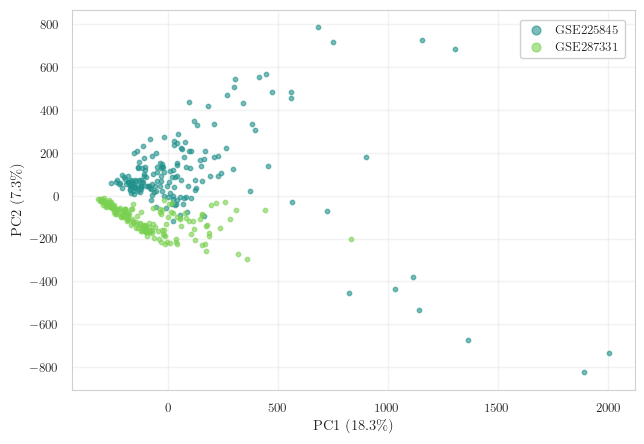

Post-transformation — by label


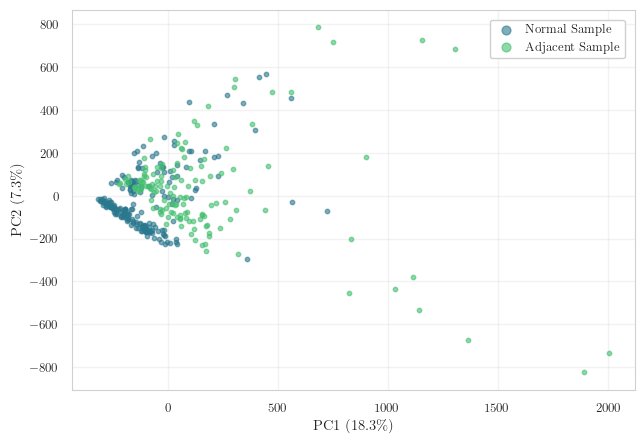

In [17]:
# ============================================================
# CELLA 8 — Post-transformation diagnostics (complementary analysis)
#   PCA on absolute deviation (pre-ComBat)
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -----------------------------
# PRINT title/subtitle (NOT on plot)
# -----------------------------
print("PCA — Absolute deviation (pre-ComBat)")
print("Post-transformation diagnostics (train pool)")

# -----------------------------
# Thesis style
# -----------------------------
if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True)

# pool train for PCA
X_tr_pool = np.vstack([X_train_abs[ds] for ds in ["GSE225845", "GSE287331"]])
ds_labels_tr = (
    ["GSE225845"] * len(X_train_abs["GSE225845"]) +
    ["GSE287331"] * len(X_train_abs["GSE287331"])
)
tissue_labels_tr = np.concatenate([
    meta_train[meta_train["dataset_origin"] == ds][LABEL_COL].values
    for ds in ["GSE225845", "GSE287331"]
])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(StandardScaler().fit_transform(X_tr_pool))
ev = pca.explained_variance_ratio_


# ============================================================
# FIGURE 1 — colored by dataset
# ============================================================
plt.figure(figsize=(6.5, 4.5))

for ds in ["GSE225845", "GSE287331"]:
    mask = np.array(ds_labels_tr) == ds
    plt.scatter(
        coords[mask, 0], coords[mask, 1],
        c=[DS_PALETTE[ds]],
        s=10, alpha=0.6, label=ds
    )

plt.xlabel(f"PC1 ({ev[0]*100:.1f}\\%)")
plt.ylabel(f"PC2 ({ev[1]*100:.1f}\\%)")
print("Post-transformation — by dataset")
plt.legend(markerscale=2, fontsize=9)

out1 = os.path.join(OUTPUT_DIR, "plot_pca_abs_precombat_by_dataset.pdf")
plt.tight_layout()
plt.savefig(out1, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# FIGURE 2 — colored by label
# ============================================================
plt.figure(figsize=(6.5, 4.5))

for lab, name in [(0, "Normal Sample"), (1, "Adjacent Sample")]:
    mask = tissue_labels_tr == lab
    plt.scatter(
        coords[mask, 0], coords[mask, 1],
        c=[DS_PALETTE_VIRIDIS[lab]],
        s=10, alpha=0.6, label=name
    )

plt.xlabel(f"PC1 ({ev[0]*100:.1f}\\%)")
plt.ylabel(f"PC2 ({ev[1]*100:.1f}\\%)")
print("Post-transformation — by label")
plt.legend(markerscale=2, fontsize=9)

out2 = os.path.join(OUTPUT_DIR, "plot_pca_abs_precombat_by_label.pdf")
plt.tight_layout()
plt.savefig(out2, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [19]:
# CELLA 9 — STEP 4: ComBat sul pool train con age come covariata
from neuroCombat import neuroCombat, neuroCombatFromTraining

# pool train
X_tr_pool = np.vstack([X_train_abs[ds] for ds in ["GSE225845", "GSE287331"]])

covars_train = pd.DataFrame({
    "batch": ds_labels_tr,
    "label": tissue_labels_tr.astype(int),
    "age":   np.concatenate([
        meta_train[meta_train["dataset_origin"] == ds]["age"].values
        for ds in ["GSE225845", "GSE287331"]
    ]).astype(float),
})

print(f"Pool train: {X_tr_pool.shape}")
print("Batch distribution:")
print(covars_train["batch"].value_counts())

result = neuroCombat(
    dat=X_tr_pool.T,          # neuroCombat vuole (features, samples)
    covars=covars_train,
    batch_col="batch",
    continuous_cols=["age"],
    categorical_cols=["label"],
    mean_only=False,
)

X_tr_combat    = result["data"].T   # (samples, features)
combat_estimates = result["estimates"]

print(f"\nComBat completato. Output shape: {X_tr_combat.shape}")

Pool train: (346, 485453)
Batch distribution:
batch
GSE225845    177
GSE287331    169
Name: count, dtype: int64
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data

ComBat completato. Output shape: (346, 485453)


In [20]:
# CELLA 10 — Applica ComBat al test set (neuroCombatFromTraining)
X_te_pool = np.vstack([X_test_abs[ds] for ds in ["GSE225845", "GSE287331"]])
ds_labels_te = (
    ["GSE225845"] * len(X_test_abs["GSE225845"]) +
    ["GSE287331"] * len(X_test_abs["GSE287331"])
)

X_te_combat = neuroCombatFromTraining(
    dat=X_te_pool.T,
    batch=ds_labels_te,
    estimates=combat_estimates,
)["data"].T

print(f"Test set post-ComBat: {X_te_combat.shape}")

[neuroCombatFromTraining] In development ...

Test set post-ComBat: (149, 485453)


PCA — Pre vs post ComBat (train set)
Post-ComBat diagnostics (complementary analysis)
Pre-ComBat — by dataset


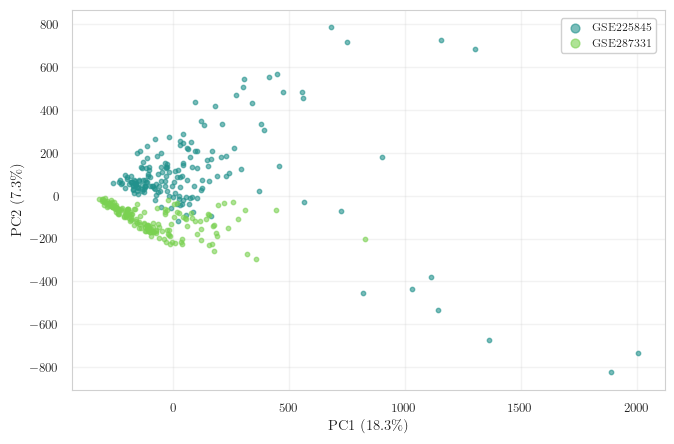

Pre-ComBat — by label


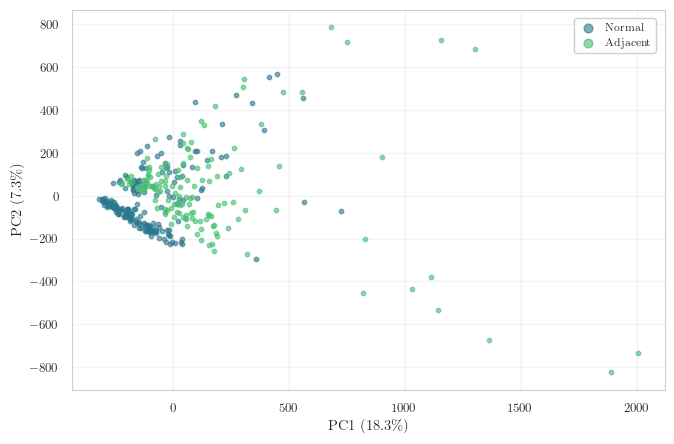

Post-ComBat — by dataset


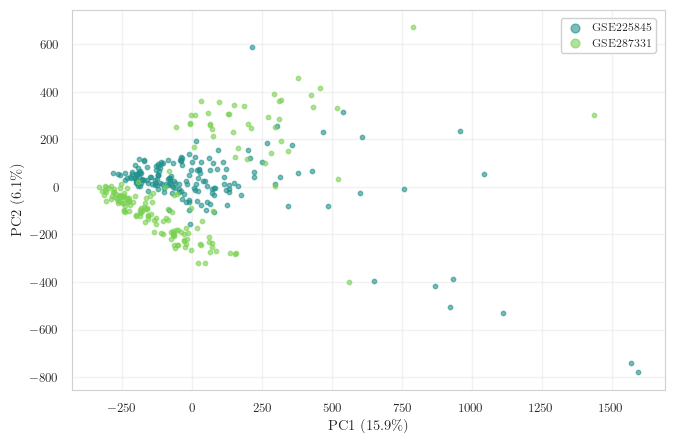

Post-ComBat — by label


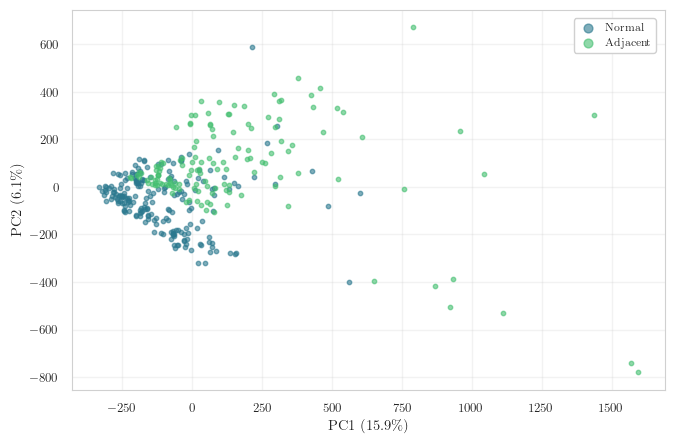


Verify biological signal post-ComBat:
  GSE225845: mean_dev(Adjacent)=0.0390  mean_dev(Normal)=0.0307  OK=True
  GSE287331: mean_dev(Adjacent)=0.0418  mean_dev(Normal)=0.0288  OK=True


In [22]:
# ============================================================
# CELLA 11 — Post-ComBat diagnostics (complementary analysis)
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -----------------------------
# PRINT title/subtitle (NOT on plot)
# -----------------------------
print("PCA — Pre vs post ComBat (train set)")
print("Post-ComBat diagnostics (complementary analysis)")

# -----------------------------
# Thesis style
# -----------------------------
if "apply_thesis_style" in globals():
    apply_thesis_style(use_tex=True)


tissue_labels_te = np.concatenate([
    meta_test[meta_test["dataset_origin"] == ds][LABEL_COL].values
    for ds in ["GSE225845", "GSE287331"]
])

# -----------------------------
# PCA pre vs post ComBat (4 separate figures)
# -----------------------------
for X_pool, title in [
    (X_tr_pool,   "Pre-ComBat"),
    (X_tr_combat, "Post-ComBat"),
]:
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(StandardScaler().fit_transform(X_pool))
    ev = pca.explained_variance_ratio_

    # FIG 1/3 — by dataset
    plt.figure(figsize=(6.8, 4.5))
    for ds in ["GSE225845", "GSE287331"]:
        mask = np.array(ds_labels_tr) == ds
        plt.scatter(
            coords[mask, 0], coords[mask, 1],
            c=[DS_PALETTE[ds]],
            s=10, alpha=0.6, label=ds
        )
    print(f"{title} — by dataset")
    plt.xlabel(f"PC1 ({ev[0]*100:.1f}\\%)")
    plt.ylabel(f"PC2 ({ev[1]*100:.1f}\\%)")
    plt.legend(markerscale=2, fontsize=8)
    out_path = os.path.join(
        OUTPUT_DIR,
        f"plot_pca_{'precombat' if title=='Pre-ComBat' else 'postcombat'}_by_dataset.pdf"
    )
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    plt.close()

    # FIG 2/4 — by label
    plt.figure(figsize=(6.8, 4.5))
    for lab, name in [(0, "Normal"), (1, "Adjacent")]:
        mask = tissue_labels_tr == lab
        plt.scatter(
            coords[mask, 0], coords[mask, 1],
            c=[DS_PALETTE_VIRIDIS[lab]],
            s=10, alpha=0.6, label=name
        )
    print(f"{title} — by label")
    plt.xlabel(f"PC1 ({ev[0]*100:.1f}\\%)")
    plt.ylabel(f"PC2 ({ev[1]*100:.1f}\\%)")
    plt.legend(markerscale=2, fontsize=8)
    out_path = os.path.join(
        OUTPUT_DIR,
        f"plot_pca_{'precombat' if title=='Pre-ComBat' else 'postcombat'}_by_label.pdf"
    )
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    plt.close()

# -----------------------------
# Verify biological signal is preserved post-ComBat
# -----------------------------
print("\nVerify biological signal post-ComBat:")
for ds in ["GSE225845", "GSE287331"]:
    mask_ds = np.array(ds_labels_tr) == ds
    labels_ds = tissue_labels_tr[mask_ds]
    X_ds = X_tr_combat[mask_ds]
    mean_adj = X_ds[labels_ds == 1].mean()
    mean_nor = X_ds[labels_ds == 0].mean()
    print(f"  {ds}: mean_dev(Adjacent)={mean_adj:.4f}  mean_dev(Normal)={mean_nor:.4f}  OK={mean_adj > mean_nor}")

In [23]:
# ── CELLA 12 — STEP 5: Feature Selection (Edgar β) ────────────────────────────
# Input disponibili dal pipeline:
#   X_tr_combat       (n_train, n_cpgs)  numpy float32
#   X_te_combat       (n_test,  n_cpgs)  numpy float32
#   tissue_labels_tr  (n_train,)         numpy int
#   tissue_labels_te  (n_test,)          numpy int
#   common_cpgs       lista nomi CpG     len = n_cpgs
# ──────────────────────────────────────────────────────────────────────────────

R_BETA_CUTOFF = 0.05
LABELS_USE    = [0, 1]

def compute_r_beta_edgar(X: np.ndarray, labels: np.ndarray, cutoff: float):
    """
    Edgar-like variability: r_beta = Q90 - Q10
    calcolato sul train set (già passato come X).
    """
    q90 = np.quantile(X, 0.90, axis=0)
    q10 = np.quantile(X, 0.10, axis=0)
    r_beta = q90 - q10
    mask_keep = r_beta >= cutoff
    return r_beta, mask_keep

print("=" * 90)
print(f"Edgar(β) train-only  cutoff r_beta >= {R_BETA_CUTOFF}")
print("=" * 90)

r_beta, mask_edgar = compute_r_beta_edgar(X_tr_combat, tissue_labels_tr, R_BETA_CUTOFF)

cpg_cols_edgar   = [common_cpgs[i] for i in range(len(common_cpgs)) if mask_edgar[i]]
selected_cpg_indices = np.where(mask_edgar)[0]
selected_cpgs        = cpg_cols_edgar

print(f"CpGs prima di Edgar : {len(common_cpgs):,}")
print(f"CpGs dopo Edgar     : {len(selected_cpgs):,}  (rimossi {len(common_cpgs) - len(selected_cpgs):,})")

# applica ai numpy array — nessun leakage, mask calcolata solo su train
B_train = X_tr_combat[:, selected_cpg_indices].astype(np.float32)
B_test  = X_te_combat[:, selected_cpg_indices].astype(np.float32)
y_train = tissue_labels_tr
y_test  = tissue_labels_te

print(f"B_train: {B_train.shape}")
print(f"B_test : {B_test.shape}")

# salva lista CpG selezionati
with open(os.path.join(OUTPUT_DIR, "cpgs_edgar_selected.txt"), "w") as f:
    f.write("\n".join(selected_cpgs))
print("Done.")

Edgar(β) train-only  cutoff r_beta >= 0.05
CpGs prima di Edgar : 485,453
CpGs dopo Edgar     : 284,642  (rimossi 200,811)
B_train: (346, 284642)
B_test : (149, 284642)
Done.



Edgar(β) variability on TRAIN — Q90−Q10 distribution with 3 cutoffs

Saved plot to: /kaggle/working/edgar_variability_train.pdf


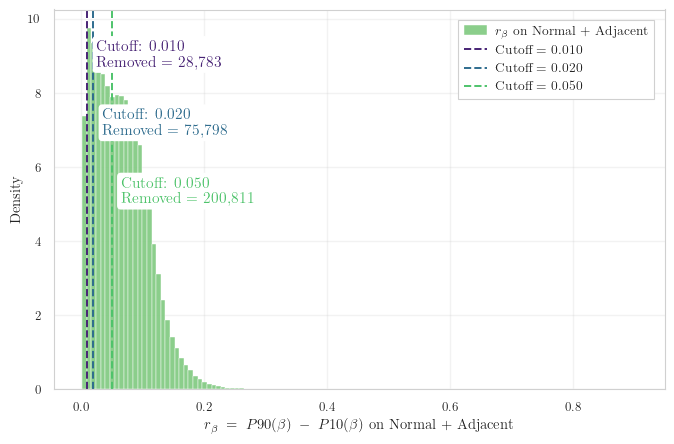

In [24]:
# -----------------------------
# PLOT — Edgar(β) variability (train-only) — white background only (no border)
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nEdgar(β) variability on TRAIN — Q90−Q10 distribution with 3 cutoffs\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

r_beta_plot = np.asarray(r_beta, dtype=float)

cutoffs = [0.010, 0.020, 0.050]

HIST_COLOR = "#7FC97F"

LINE_COLORS = {
    0.010: plt.cm.viridis(0.10),
    0.020: plt.cm.viridis(0.35),
    0.050: plt.cm.viridis(0.72),
}

HIST_LABEL = r"$r_\beta$ on Normal + Adjacent"
XLABEL = r"$r_\beta \;=\; P90(\beta)\;-\;P10(\beta)$ on Normal + Adjacent"

fig, ax = plt.subplots()

ax.hist(
    r_beta_plot,
    bins=120,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label=HIST_LABEL,
    zorder=1,
)

ymax = ax.get_ylim()[1]
X_SHIFT = 0.015

for i, c in enumerate(cutoffs):
    col = LINE_COLORS[c]

    ax.axvline(
        c,
        linestyle="--",
        linewidth=1.4,
        color=col,
        label=rf"Cutoff = {c:0.3f}",
        zorder=2,
    )

    removed = int((r_beta_plot < c).sum())

    ax.text(
        c + X_SHIFT,
        ymax * (0.92 - 0.18 * i),
        f"Cutoff: {c:0.3f}\nRemoved = {removed:,}",
        color=col,
        fontsize=11.0,
        fontweight="semibold",
        ha="left",
        va="top",
        zorder=5,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            linewidth=0,
            alpha=1.0,
        ),
    )

ax.set_xlabel(XLABEL)
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
pdf_path = Path(OUTPUT_DIR) / "edgar_variability_train.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

In [25]:
# -----------------------------
# STEP 2 — M-transform + variance filter (train-only)
#   - beta -> M (post-Edgar)
#   - drop lowest-variance 2% in TRAIN only (optional/off if Edgar is aggressive)
# -----------------------------

# CONFIG (add/override)
EPS_M = 1e-6
VAR_DROP_FRAC = 0.02          # drop lowest 2% by variance/SD
APPLY_VAR_FILTER = True       # set False if Edgar already aggressive

def beta_to_m(beta_arr: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    b = np.clip(beta_arr, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def soft_sd_filter(X, cols, drop_frac):
    sd = X.std(axis=0, ddof=1)
    thr = np.quantile(sd, drop_frac)
    keep_mask = sd >= thr
    return X[:, keep_mask], cols[keep_mask], sd[keep_mask], keep_mask

print("\n" + "=" * 90)
print("STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only")
print("=" * 90)

# (assumes from STEP 5 you have: B_train, B_test, selected_cpgs)
cpg_cols_edgar = np.array(selected_cpgs, dtype=object)

# β → M
M_train = beta_to_m(B_train, eps=EPS_M).astype(np.float32)
M_test  = beta_to_m(B_test,  eps=EPS_M).astype(np.float32)
print(f"After M-transform: M_train={M_train.shape} | M_test={M_test.shape}")

# Variance/SD filter (train-only), optional
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    M_train_f, cpg_cols_f, sd_f, keep_mask = soft_sd_filter(M_train, cpg_cols_edgar, drop_frac=VAR_DROP_FRAC)
    M_test_f = M_test[:, keep_mask]

    print(f"Variance filter: drop_frac={VAR_DROP_FRAC:.2%}")
    print(f"CpGs before: {M_train.shape[1]:,} | after: {M_train_f.shape[1]:,}  (dropped {M_train.shape[1]-M_train_f.shape[1]:,})")

    # overwrite "current" matrices/cols for next steps
    M_train, M_test, cpg_cols_edgar = M_train_f, M_test_f, cpg_cols_f
else:
    print("Variance filter OFF (no CpGs removed).")

# keep aligned beta matrices too (needed later for |Δβ| gates)
# B_train/B_test remain post-Edgar; apply same keep_mask if variance filter ON
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    B_train = B_train[:, keep_mask]
    B_test  = B_test[:, keep_mask]
    cpg_cols_current = cpg_cols_edgar.copy()
else:
    cpg_cols_current = cpg_cols_edgar.copy()

print(f"Current aligned: B_train={B_train.shape} | M_train={M_train.shape} | CpGs={len(cpg_cols_current):,}")


STEP 2 — β→M + variance filter (drop lowest 2% SD) train-only
After M-transform: M_train=(346, 284642) | M_test=(149, 284642)
Variance filter: drop_frac=2.00%
CpGs before: 284,642 | after: 278,949  (dropped 5,693)
Current aligned: B_train=(346, 278949) | M_train=(346, 278949) | CpGs=278,949



STEP 2 — SD(M) distribution on TRAIN with variance cutoff (train-only): 2%

Saved plot to: /kaggle/working/sdM_variance_filter_train.pdf


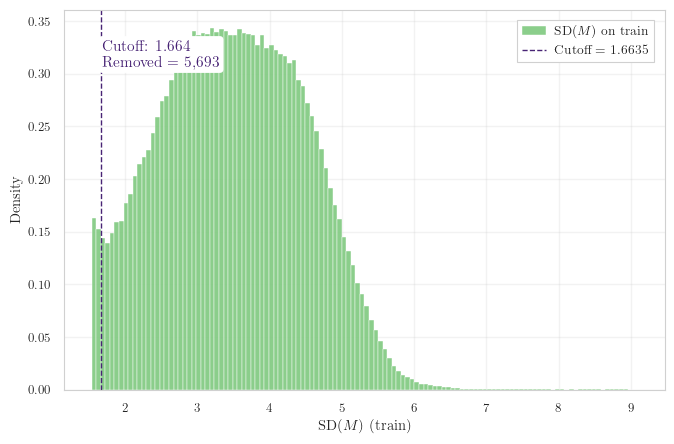

Kept = 273,256 / 278,949 CpGs (Removed = 5,693)


In [26]:
# =============================
# STEP 2 — PLOT: SD(M) distribution + 2% cutoff (train-only)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 2 — SD(M) distribution on TRAIN with variance cutoff (train-only): 2%\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

# Recompute pre-filter SD (identical to STEP 2 input)
M_train_pre = beta_to_m(B_train, eps=EPS_M).astype(np.float32)

sd_pre = M_train_pre.std(axis=0, ddof=1)
thr = float(np.quantile(sd_pre, VAR_DROP_FRAC))

total = int(sd_pre.size)

# keep_mask exists only if variance filter was applied
if APPLY_VAR_FILTER and (VAR_DROP_FRAC > 0):
    removed = int((~keep_mask).sum())
else:
    removed = 0

kept = total - removed

fig, ax = plt.subplots()

# Histogram (same green as Edgar)
HIST_COLOR = "#7FC97F"
ax.hist(
    sd_pre,
    bins=120,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label=r"$\mathrm{SD}(M)$ on train",
    zorder=1,
)

# Cutoff line
cut_color = plt.cm.viridis(0.10)
ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.0,
    color=cut_color,
    label=rf"Cutoff = {thr:.4f}",
    zorder=2,
)

ax.set_xlabel(r"$\mathrm{SD}(M)$ (train)")
ax.set_ylabel("Density")

# Annotation
X_SHIFT = 0.02
ymax = ax.get_ylim()[1]

ax.text(
    thr + X_SHIFT,
    ymax * 0.92,
    f"Cutoff: {thr:.3f}\nRemoved = {removed:,}",
    color=cut_color,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
pdf_path = Path(OUTPUT_DIR) / "sdM_variance_filter_train.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

print(f"Kept = {kept:,} / {total:,} CpGs (Removed = {removed:,})")

In [27]:
# ============================================================
# STEP 2.5 — Bio-weight (DA METTERE TRA STEP2 e STEP3)
# ============================================================

import pandas as pd
import numpy as np

MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"

def load_manifest_bio(path: str) -> pd.DataFrame:
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if "IlmnID" in line.split(","):
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Header manifest non trovato (colonna IlmnID).")

    df = pd.read_csv(
        path,
        header=header_idx,
        engine="python",
        on_bad_lines="skip",
        usecols=["IlmnID", "Relation_to_UCSC_CpG_Island", "UCSC_RefGene_Group"],
    )
    df.columns = [c.strip() for c in df.columns]
    df["IlmnID"] = df["IlmnID"].astype(str).str.strip()
    return df

manifest_bio = load_manifest_bio(MANIFEST_PATH)

island_cpgs = set(manifest_bio.loc[manifest_bio["Relation_to_UCSC_CpG_Island"] == "Island", "IlmnID"])
promoter_cpgs = set(
    manifest_bio.loc[
        manifest_bio["UCSC_RefGene_Group"].fillna("").astype(str).str.contains("TSS", na=False),
        "IlmnID"
    ]
)

cpg_cols_current_arr = np.array(cpg_cols_current, dtype=object)

bio_weight = np.array([
    1.00 if (c in island_cpgs and c in promoter_cpgs) else
    0.70 if (c in island_cpgs) else
    0.50 if (c in promoter_cpgs) else
    0.20
    for c in cpg_cols_current_arr
], dtype=np.float32)

# normalizza in [0,1]
bio_weight_norm = (bio_weight - bio_weight.min()) / (bio_weight.max() - bio_weight.min())

# diagnostica
n_top    = int((bio_weight == 1.00).sum())
n_island = int((bio_weight == 0.70).sum())
n_prom   = int((bio_weight == 0.50).sum())
n_other  = int((bio_weight == 0.20).sum())

print(f"[BIO] CpG in isola CpG    : {len(island_cpgs):,}")
print(f"[BIO] CpG in promotore TSS: {len(promoter_cpgs):,}")
print(f"[BIO] Entrambi            : {len(island_cpgs & promoter_cpgs):,}")
print(f"\n[BIO] Distribuzione peso biologico su {len(cpg_cols_current_arr):,} CpG (post STEP2):")
print(f"  isola+TSS (1.00): {n_top:,}   ({100*n_top/len(cpg_cols_current_arr):.1f}%)")
print(f"  isola     (0.70): {n_island:,}   ({100*n_island/len(cpg_cols_current_arr):.1f}%)")
print(f"  promotore (0.50): {n_prom:,}   ({100*n_prom/len(cpg_cols_current_arr):.1f}%)")
print(f"  altro     (0.20): {n_other:,}   ({100*n_other/len(cpg_cols_current_arr):.1f}%)")

[BIO] CpG in isola CpG    : 161,441
[BIO] CpG in promotore TSS: 196,657
[BIO] Entrambi            : 73,261

[BIO] Distribuzione peso biologico su 278,949 CpG (post STEP2):
  isola+TSS (1.00): 6,363   (2.3%)
  isola     (0.70): 18,038   (6.5%)
  promotore (0.50): 38,331   (13.7%)
  altro     (0.20): 216,217   (77.5%)


In [28]:
# -----------------------------
# STEP 3 — Repeated Stratified K-Fold stability ranking (train-only, DIRECTIVE-COMPLIANT)
#   K=5, R=10
#   per split:
#     - compute MWU p-values on TRAIN-FOLD only
#     - compute |ΔM| and sign on TRAIN-FOLD only (for ranking)
#     - compute sign on VAL-FOLD (for stability check)
#   aggregate across splits:
#     score = 0.5*mean(rank_p_train) + 0.5*mean(rank_|ΔM|_train)
#     stability_sign = fraction of splits where sign_train == sign_val (and non-zero)
#     stability_sign >= 0.75
#     |ΔM| >= 0.15 (fallback 0.10 if too few candidates)
#   output: top 15k CpGs (candidates)
# -----------------------------

from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import mannwhitneyu

print("\n" + "=" * 90)
print("STEP 3 — RSKF stability ranking (K=5, R=10): score=0.5*rank_p + 0.5*rank_|ΔM|")
print("=" * 90)

# CONFIG
K_FOLDS = 5
R_REPEATS = 10
STABILITY_SIGN_MIN = 0.75
#DELTA_M_THR_MAIN = 0.15 
#DELTA_M_THR_FALLBACK = 0.10
TOP_CANDIDATES = 15000
MIN_CANDIDATES_TARGET = 15000  # "collassa" if well below this

# Assumes available from STEP 2 (post-Edgar + optional var filter):
#   M_train (n_train, p), y_train (n_train,), cpg_cols_current (p,)
X = M_train
y = y_train
cols = np.array(cpg_cols_current, dtype=object)

n, p = X.shape
rkf = RepeatedStratifiedKFold(n_splits=K_FOLDS, n_repeats=R_REPEATS, random_state=RANDOM_STATE)
n_splits_total = K_FOLDS * R_REPEATS
print(f"Train: n={n} | p={p:,} | splits={n_splits_total} (K={K_FOLDS}, R={R_REPEATS})")

# accumulators for score
rank_p_sum = np.zeros(p, dtype=np.float64)
rank_dm_sum = np.zeros(p, dtype=np.float64)

# accumulators for sign stability (train vs val)
sign_agree_count = np.zeros(p, dtype=np.int32)   # count splits where sign_train == sign_val and both non-zero
sign_valid_count = np.zeros(p, dtype=np.int32)   # count splits where both classes present in train+val and signs non-zero

valid_splits_for_score = 0

def _ranks_ascending(values: np.ndarray) -> np.ndarray:
    """Return 1..p ranks, where smaller values -> smaller rank (best=1)."""
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

def _ranks_descending(values: np.ndarray) -> np.ndarray:
    """Return 1..p ranks, where larger values -> smaller rank (best=1)."""
    order = np.argsort(-values, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[order] = np.arange(1, values.size + 1, dtype=np.int32)
    return ranks

for split_id, (train_idx, val_idx) in enumerate(rkf.split(X, y), start=1):
    X_tr = X[train_idx]
    y_tr = y[train_idx]
    X_va = X[val_idx]
    y_va = y[val_idx]

    # ensure both classes present in both folds (should hold with stratification, but keep safe)
    tr0 = (y_tr == 0); tr1 = (y_tr == 1)
    va0 = (y_va == 0); va1 = (y_va == 1)
    if tr0.sum() == 0 or tr1.sum() == 0 or va0.sum() == 0 or va1.sum() == 0:
        continue

    X0_tr = X_tr[tr0]; X1_tr = X_tr[tr1]
    X0_va = X_va[va0]; X1_va = X_va[va1]

    # TRAIN-FOLD ΔM (signed + abs) used for ranking
    dM_tr = X1_tr.mean(axis=0) - X0_tr.mean(axis=0)
    abs_dM_tr = np.abs(dM_tr)

    # VAL-FOLD ΔM only for sign stability
    dM_va = X1_va.mean(axis=0) - X0_va.mean(axis=0)

    sign_tr = np.sign(dM_tr).astype(np.int8)  # -1,0,+1
    sign_va = np.sign(dM_va).astype(np.int8)

    # sign stability: count agreement where both non-zero
    nonzero = (sign_tr != 0) & (sign_va != 0)
    sign_valid_count += nonzero.astype(np.int32)
    sign_agree_count += (nonzero & (sign_tr == sign_va)).astype(np.int32)

    # MWU p-values on TRAIN-FOLD only
    # --- PREFILTER by |ΔM| to avoid MWU on all CpGs ---
    PREFILTER_TOP_DM = 50000   # you can tune (30k–70k reasonable)
    PRINT_EVERY = 1            # progress frequency
    
    # 1) prefilter indices by |ΔM| (train-fold)
    if PREFILTER_TOP_DM is not None and PREFILTER_TOP_DM < p:
        idx_pf = np.argpartition(-abs_dM_tr, PREFILTER_TOP_DM - 1)[:PREFILTER_TOP_DM]
    else:
        idx_pf = np.arange(p)
    
    # 2) MWU only on prefiltered CpGs
    pvals = np.ones(p, dtype=np.float64)  # default worst p-value
    for j in idx_pf:
        pvals[j] = mannwhitneyu(
            X0_tr[:, j], X1_tr[:, j],
            alternative="two-sided",
            method="asymptotic"
        ).pvalue


    # ranks per split (TRAIN-FOLD only)
    r_p = _ranks_ascending(pvals)       # best small p -> rank 1
    r_dm = _ranks_descending(abs_dM_tr) # best large |ΔM| -> rank 1

    rank_p_sum += r_p
    rank_dm_sum += r_dm
    valid_splits_for_score += 1

    if split_id % PRINT_EVERY == 0 or split_id == n_splits_total:
        print(f"  done split {split_id:>3}/{n_splits_total} | pf={idx_pf.size:,} | valid_for_score={valid_splits_for_score}")

if valid_splits_for_score == 0:
    raise RuntimeError("No valid splits computed in RSKF step (check labels / stratification).")

# aggregate score
#mean_rank_p = rank_p_sum / valid_splits_for_score
#mean_rank_dm = rank_dm_sum / valid_splits_for_score
#score = 0.5 * mean_rank_p + 0.5 * mean_rank_dm

mean_rank_p  = rank_p_sum  / valid_splits_for_score
mean_rank_dm = rank_dm_sum / valid_splits_for_score

# METTI:
score_stat_raw = 0.5 * mean_rank_p + 0.5 * mean_rank_dm        # [1, p]
score_stat = (score_stat_raw - score_stat_raw.min()) / \
             (score_stat_raw.max() - score_stat_raw.min())      # [0, 1]
score_bio  = 1.0 - bio_weight_norm                              # [0, 1]
W_BIO = 0.20
score = (1.0 - W_BIO) * score_stat + W_BIO * score_bio         # [0, 1]


print(f"\n[BIO] Integrated score with W_BIO={W_BIO}:")
print(f"  score_stat range: [{score_stat.min():.4f}, {score_stat.max():.4f}]")
print(f"  score      range: [{score.min():.4f}, {score.max():.4f}]")

# stability_sign = fraction of splits where sign_train == sign_val (only where both non-zero)
stability_sign = np.zeros(p, dtype=np.float64)
nz = sign_valid_count > 0
stability_sign[nz] = sign_agree_count[nz] / sign_valid_count[nz]
# if never valid (rare), keep 0 stability (will be filtered out)

# global ΔM estimate on full TRAIN (used for thresholding)
dM_full = X[y == 1].mean(axis=0) - X[y == 0].mean(axis=0)
abs_dM_full = np.abs(dM_full)

DELTA_M_THR_MAIN = float(np.percentile(abs_dM_full, 60))
DELTA_M_THR_FALLBACK = float(np.percentile(abs_dM_full, 50))
print(f"|ΔM| cutoff p60 (main)    : {DELTA_M_THR_MAIN:.4f}")
print(f"|ΔM| cutoff p50 (fallback): {DELTA_M_THR_FALLBACK:.4f}")

# candidate filter with fallback
thr = DELTA_M_THR_MAIN
mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
n_cand = int(mask_cand.sum())
print(f"Candidates with |ΔM|>={thr:.2f} and stability_sign>={STABILITY_SIGN_MIN:.2f}: {n_cand:,}")

if n_cand < MIN_CANDIDATES_TARGET:
    thr = DELTA_M_THR_FALLBACK
    mask_cand = (stability_sign >= STABILITY_SIGN_MIN) & (abs_dM_full >= thr)
    n_cand = int(mask_cand.sum())
    print(f"Fallback |ΔM|>={thr:.2f}: candidates={n_cand:,}")

if n_cand == 0:
    raise RuntimeError("Step 3 produced 0 candidates even after fallback. Lower thresholds or inspect data.")

# pick top 15k by score (lower is better)
cand_idx = np.where(mask_cand)[0]
order = np.argsort(score[cand_idx], kind="mergesort")
cand_idx_sorted = cand_idx[order]
cand_idx_top = cand_idx_sorted[:min(TOP_CANDIDATES, cand_idx_sorted.size)]

cpg_candidates = cols[cand_idx_top]

# keep useful stats for later steps (region anchoring / reporting)
step3_stats = {
    "score": score[cand_idx_top],
    "score_stat": score_stat[cand_idx_top],
    "mean_rank_p": mean_rank_p[cand_idx_top],
    "mean_rank_abs_dM": mean_rank_dm[cand_idx_top],
    "stability_sign": stability_sign[cand_idx_top],
    "deltaM_full": dM_full[cand_idx_top],
    "abs_deltaM_full": abs_dM_full[cand_idx_top],
    "used_deltaM_thr": thr,
    "valid_splits_for_score": valid_splits_for_score,
    "sign_valid_splits": sign_valid_count[cand_idx_top],
}

print(f"Selected top candidates: {len(cpg_candidates):,} (target {TOP_CANDIDATES:,})")
print("Example:", cpg_candidates[:5].tolist())

import pickle
from pathlib import Path

OUTDIR = Path(OUTPUT_DIR) / "fs_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Save CpG list
with open(OUTDIR / "cpg_candidates.pkl", "wb") as f:
    pickle.dump(cpg_candidates.tolist(), f)

# Save step3_stats dict
with open(OUTDIR / "step3_stats.pkl", "wb") as f:
    pickle.dump(step3_stats, f)

print("Step3 variables saved.")


STEP 3 — RSKF stability ranking (K=5, R=10): score=0.5*rank_p + 0.5*rank_|ΔM|
Train: n=346 | p=278,949 | splits=50 (K=5, R=10)
  done split   1/50 | pf=50,000 | valid_for_score=1
  done split   2/50 | pf=50,000 | valid_for_score=2
  done split   3/50 | pf=50,000 | valid_for_score=3
  done split   4/50 | pf=50,000 | valid_for_score=4
  done split   5/50 | pf=50,000 | valid_for_score=5
  done split   6/50 | pf=50,000 | valid_for_score=6
  done split   7/50 | pf=50,000 | valid_for_score=7
  done split   8/50 | pf=50,000 | valid_for_score=8
  done split   9/50 | pf=50,000 | valid_for_score=9
  done split  10/50 | pf=50,000 | valid_for_score=10
  done split  11/50 | pf=50,000 | valid_for_score=11
  done split  12/50 | pf=50,000 | valid_for_score=12
  done split  13/50 | pf=50,000 | valid_for_score=13
  done split  14/50 | pf=50,000 | valid_for_score=14
  done split  15/50 | pf=50,000 | valid_for_score=15
  done split  16/50 | pf=50,000 | valid_for_score=16
  done split  17/50 | pf=50,000 |


STEP 3 — stability_sign distribution (train↔val agreement)

Saved plot to: /kaggle/working/plots_outputs/stability_sign_distribution.pdf


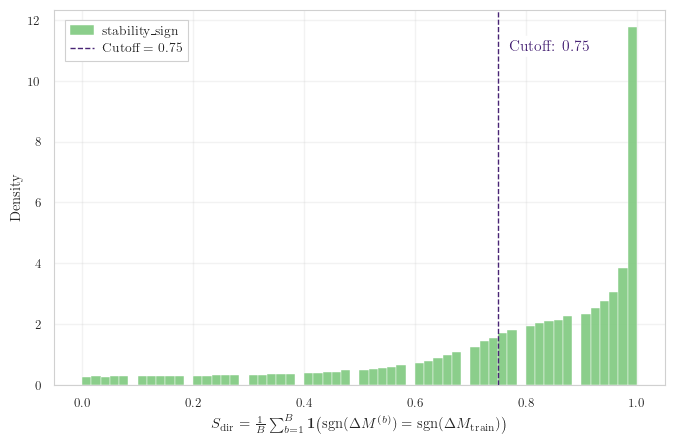

In [29]:
# =============================
# STEP 3 — PLOT: stability_sign distribution (train↔val agreement)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 3 — stability_sign distribution (train↔val agreement)\n")

apply_thesis_style(use_tex=True, legend_position="upper left", legend_outside=False)

fig, ax = plt.subplots()

HIST_COLOR = "#7FC97F"
CUT_COLOR = plt.cm.viridis(0.10)

ax.hist(
    stability_sign,
    bins=60,
    density=True,
    alpha=0.90,
    color=HIST_COLOR,
    edgecolor="white",
    linewidth=0.35,
    label="stability_sign",
    zorder=1,
)

ax.axvline(
    STABILITY_SIGN_MIN,
    linestyle="--",
    linewidth=1.0,
    color=CUT_COLOR,
    label=rf"Cutoff = {STABILITY_SIGN_MIN:.2f}",
    zorder=2,
)

ax.set_xlabel(
    r"$S_{\mathrm{dir}}=\frac{1}{B}\sum_{b=1}^{B}\mathbf{1}\!\left("
    r"\mathrm{sgn}(\Delta M^{(b)})=\mathrm{sgn}(\Delta M_{\mathrm{train}})"
    r"\right)$"
)
ax.set_ylabel("Density")

# annotation (white background only, no border)
ymax = ax.get_ylim()[1]
ax.text(
    STABILITY_SIGN_MIN + 0.02,
    ymax * 0.92,
    f"Cutoff: {STABILITY_SIGN_MIN:.2f}",
    color=CUT_COLOR,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path(OUTPUT_DIR) / "plots_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / "stability_sign_distribution.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {pdf_path}")

plt.show()


STEP 3 — RSKF score vs |ΔM| on TRAIN (candidates highlighted)

Saved plot to: /kaggle/working/plots_outputs/absDeltaM_vs_score.pdf


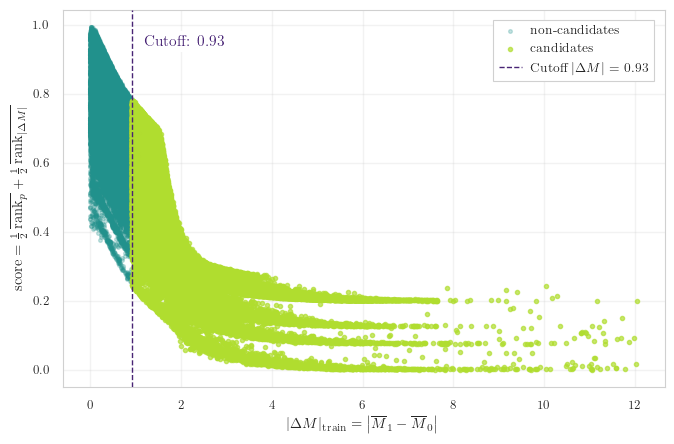

In [30]:
# =============================
# STEP 3 — PLOT: RSKF score vs |ΔM| (viridis coherent palette)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("\nSTEP 3 — RSKF score vs |ΔM| on TRAIN (candidates highlighted)\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

score = np.asarray(score, dtype=float)
abs_dM_full = np.asarray(abs_dM_full, dtype=float)
mask_cand = np.asarray(mask_cand, dtype=bool)

idx_cand = np.where(mask_cand)[0]
idx_non = np.where(~mask_cand)[0]

MAX_NON = 25000
if idx_non.size > MAX_NON:
    rng = np.random.default_rng(RANDOM_STATE)
    idx_non = rng.choice(idx_non, size=MAX_NON, replace=False)

# --- VIRIDIS PALETTE ---
c_non   = plt.cm.viridis(0.50)  # verde medio/scuro (tolte)
c_cand  = plt.cm.viridis(0.88)  # giallo-verde chiaro (tenute)
c_line  = plt.cm.viridis(0.10)  # verde scuro (cutoff)

fig, ax = plt.subplots()

ax.scatter(
    abs_dM_full[idx_non],
    score[idx_non],
    s=7,
    alpha=0.25,
    color=c_non,
    label="non-candidates",
    zorder=1,
)

ax.scatter(
    abs_dM_full[idx_cand],
    score[idx_cand],
    s=9,
    alpha=0.70,
    color=c_cand,
    label="candidates",
    zorder=2,
)

ax.axvline(
    thr,
    linestyle="--",
    linewidth=1.0,
    color=c_line,
    label=rf"Cutoff $|\Delta M|$ = {thr:.2f}",
    zorder=3,
)

ax.set_xlabel(r"$|\Delta M|_{\mathrm{train}} = \left|\overline{M}_{1} - \overline{M}_{0}\right|$")
ax.set_ylabel(
    r"$\mathrm{score} = \frac{1}{2}\,\overline{\mathrm{rank}_{p}} + \frac{1}{2}\,\overline{\mathrm{rank}_{|\Delta M|}}$"
)

# Annotazione cutoff stile Edgar
ymax = ax.get_ylim()[1]
x_text = thr + 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])

ax.text(
    x_text,
    ymax * 0.93,
    f"Cutoff: {thr:.2f}",
    color=c_line,
    fontsize=11,
    fontweight="semibold",
    ha="left",
    va="top",
    zorder=5,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="none",
        linewidth=0,
        alpha=1.0,
    ),
)

place_legend(ax)
fig.tight_layout()

OUTDIR = Path(OUTPUT_DIR) / "plots_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUTDIR / "absDeltaM_vs_score.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to: {pdf_path}")

plt.show()

In [31]:
# =============================
# STEP 3 — CHECK: Spearman corr(score, |ΔM|) on TRAIN
#   tells you if the score is basically dominated by effect size
# =============================

import numpy as np
from scipy.stats import spearmanr

print("\nSTEP 3 — Spearman correlation between score and |ΔM| (full train)\n")

# Assumes from STEP 3 you have:
#   score        : np.ndarray (len p)
#   abs_dM_full  : np.ndarray (len p)
#   mask_cand    : np.ndarray bool (len p)  [optional]
#   cpg_cols_current : list/array CpG ids (len p) [optional]

score_arr = np.asarray(score, dtype=float)
absdm_arr = np.asarray(abs_dM_full, dtype=float)

# Safety: remove NaNs/Infs if any
ok = np.isfinite(score_arr) & np.isfinite(absdm_arr)
score_ok = score_arr[ok]
absdm_ok = absdm_arr[ok]

# Spearman on all CpGs
rho_all, p_all = spearmanr(score_ok, absdm_ok)

print(f"[ALL CpGs] Spearman rho(score, |ΔM|) = {rho_all:.4f} | p-value = {p_all:.3e} | n = {score_ok.size:,}")

# Optional: Spearman on candidates only (after stability + |ΔM| thresholds)
if "mask_cand" in globals():
    mask = np.asarray(mask_cand, dtype=bool)
    mask = mask & ok
    if mask.sum() > 10:
        rho_c, p_c = spearmanr(score_arr[mask], absdm_arr[mask])
        print(f"[CANDIDATES] Spearman rho(score, |ΔM|) = {rho_c:.4f} | p-value = {p_c:.3e} | n = {int(mask.sum()):,}")
    else:
        print("[CANDIDATES] not enough points to compute reliably.")

# Optional: quick diagnostic interpretation
if np.isfinite(rho_all):
    if abs(rho_all) > 0.90:
        print("Interpretation: |rho|>0.90 ⇒ score is (almost) monotone in |ΔM| → ranking dominated by effect size.")
    elif abs(rho_all) > 0.70:
        print("Interpretation: 0.70<|rho|<=0.90 ⇒ strong link: effect size is a major driver, MWU still contributes.")
    else:
        print("Interpretation: |rho|<=0.70 ⇒ MWU ranks contribute materially beyond effect size.")


STEP 3 — Spearman correlation between score and |ΔM| (full train)

[ALL CpGs] Spearman rho(score, |ΔM|) = -0.7982 | p-value = 0.000e+00 | n = 278,949
[CANDIDATES] Spearman rho(score, |ΔM|) = -0.8480 | p-value = 0.000e+00 | n = 111,509
Interpretation: 0.70<|rho|<=0.90 ⇒ strong link: effect size is a major driver, MWU still contributes.


In [33]:
# -----------------------------
# STEP 3b — Region anchoring su CpG islands (DIRECTIVE-COMPLIANT)
#   region_score = median(score) × fraction_stable
#   fraction_stable >= 0.6, >= 2 CpG per regione
#   top-m (m=2-3) per regione -> Pool A [anchored]
#   resto -> Pool B [non-anchored]
#
# NOTE (aderenza):
# - "fraction_stable" qui è calcolata su CpG che rispettano i vincoli di STEP 3:
#     stability_sign >= 0.75  AND  |ΔM| >= thr_usato_in_step3
#   (thr_usato_in_step3 = 0.15 oppure 0.10 se fallback)
# -----------------------------

import numpy as np
import polars as pl

print("\n" + "=" * 90)
print("STEP 3b — Region anchoring su CpG islands")
print("=" * 90)

# CONFIG
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"
MANIFEST_CPG_COL = "IlmnID"
MANIFEST_ISLAND_NAME_COL = "UCSC_CpG_Islands_Name"
MANIFEST_REL_COL = "Relation_to_UCSC_CpG_Island"

ANCHOR_CONTEXT = {"Island"}        # anchoring strictly on islands
FRACTION_STABLE_MIN = 0.60
MIN_CPGS_PER_REGION = 2
TOP_M_PER_REGION = 3               # set 2 or 3

# Assumes from STEP 3:
#   cpg_candidates : (n_cand,)
#   step3_stats["score"] : (n_cand,)   lower is better
#   step3_stats["stability_sign"] : (n_cand,)
#   step3_stats["abs_deltaM_full"] : (n_cand,)
#   step3_stats["used_deltaM_thr"] : scalar (0.15 or 0.10)
cand = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)
cand_stab  = np.array(step3_stats["stability_sign"], dtype=float)
cand_absdM = np.array(step3_stats["abs_deltaM_full"], dtype=float)
thr_used   = float(step3_stats["used_deltaM_thr"])

if not (cand.shape[0] == cand_score.shape[0] == cand_stab.shape[0] == cand_absdM.shape[0]):
    raise RuntimeError("STEP 3b: candidate arrays are misaligned (cpg_candidates vs step3_stats).")

# Define CpG-level "stable" flag per STEP 3 directive (within the candidate set)
stable_cpg_flag = (cand_stab >= STABILITY_SIGN_MIN) & (cand_absdM >= thr_used)

print(f"Candidates: {cand.size:,}")
print(f"ΔM threshold used in STEP 3: {thr_used:.2f}")
print(f"Stable CpGs inside candidates (stab>=0.75 AND |ΔM|>=thr): {int(stable_cpg_flag.sum()):,}")

# -----------------------------
# A) Build CpG -> island mapping (only Island context and named islands)
# -----------------------------
def load_manifest_with_real_header(path: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        start_row = None
        for i, line in enumerate(f):
            if line.startswith("IlmnID"):
                start_row = i
                break
    if start_row is None:
        raise ValueError(f"Non trovo header 'IlmnID' in: {path}")
    return pd.read_csv(path, skiprows=start_row, low_memory=False)

mf = load_manifest_with_real_header(MANIFEST_PATH)

# Keep only required columns
mf = mf[[MANIFEST_CPG_COL, MANIFEST_ISLAND_NAME_COL, MANIFEST_REL_COL]].copy()

mf.columns = ["cpg", "island", "rel"]

mf["cpg"] = mf["cpg"].astype(str)
mf["island"] = mf["island"].fillna("").astype(str).str.strip()
mf["rel"] = mf["rel"].fillna("").astype(str).str.strip()

# Filter strictly Island context + named islands
mf_island = mf[
    (mf["rel"].isin(list(ANCHOR_CONTEXT))) &
    (mf["island"] != "")
]

# CpG -> island dictionary
cpg_to_island = dict(zip(mf_island["cpg"], mf_island["island"]))

# map candidates to islands
island_id = np.array([cpg_to_island.get(c, None) for c in cand], dtype=object)
in_island = island_id != None
print(f"Mapped to named CpG islands (context={ANCHOR_CONTEXT}): {int(in_island.sum()):,}")

# -----------------------------
# B) Group by island, compute region_score and pick top-m CpGs per selected region
# -----------------------------
island_to_idx = {}
for i, rid in enumerate(island_id):
    if rid is None:
        continue
    island_to_idx.setdefault(rid, []).append(i)

region_rows = []
poolA_idx = []

for rid, idxs in island_to_idx.items():
    idxs = np.array(idxs, dtype=int)

    # constraint: >= 2 CpGs per region
    if idxs.size < MIN_CPGS_PER_REGION:
        continue

    # fraction_stable computed on STEP3 "stable" definition
    frac_stable = float(stable_cpg_flag[idxs].mean())
    if frac_stable < FRACTION_STABLE_MIN:
        continue

    # region_score = median(score) * fraction_stable
    med_score = float(np.median(cand_score[idxs]))
    region_score = med_score * frac_stable

    # top-m per region by candidate score (lower better)
    order = np.argsort(cand_score[idxs], kind="mergesort")
    chosen = idxs[order[:min(TOP_M_PER_REGION, idxs.size)]]
    poolA_idx.extend(chosen.tolist())

    region_rows.append((rid, idxs.size, frac_stable, med_score, region_score, chosen.size))

poolA_idx = np.array(sorted(set(poolA_idx)), dtype=int)

# -----------------------------
# C) Final pools
# -----------------------------
poolA_cpgs = cand[poolA_idx]  # anchored

maskA = np.zeros(cand.size, dtype=bool)
maskA[poolA_idx] = True
poolB_cpgs = cand[~maskA]     # non-anchored

print(f"Selected regions (pass constraints): {len(region_rows):,}")
print(f"Pool A (anchored) CpGs: {poolA_cpgs.size:,}  (top-m={TOP_M_PER_REGION} per region)")
print(f"Pool B (non-anchored) CpGs: {poolB_cpgs.size:,}")

region_summary = (
    pl.DataFrame(
        region_rows,
        schema=["island_id", "n_cpgs", "fraction_stable", "median_score", "region_score", "picked_m"]
    ).sort("region_score")
)

print("Top 5 regions by region_score (lower is better):")
print(region_summary.head(5))

# Outputs:
#   poolA_cpgs, poolB_cpgs, region_summary


STEP 3b — Region anchoring su CpG islands
Candidates: 15,000
ΔM threshold used in STEP 3: 0.93
Stable CpGs inside candidates (stab>=0.75 AND |ΔM|>=thr): 15,000
Mapped to named CpG islands (context={'Island'}): 4,669
Selected regions (pass constraints): 818
Pool A (anchored) CpGs: 1,937  (top-m=3 per region)
Pool B (non-anchored) CpGs: 13,063
Top 5 regions by region_score (lower is better):
shape: (5, 6)
┌──────────────────────────┬────────┬─────────────────┬──────────────┬──────────────┬──────────┐
│ island_id                ┆ n_cpgs ┆ fraction_stable ┆ median_score ┆ region_score ┆ picked_m │
│ ---                      ┆ ---    ┆ ---             ┆ ---          ┆ ---          ┆ ---      │
│ str                      ┆ i64    ┆ f64             ┆ f64          ┆ f64          ┆ i64      │
╞══════════════════════════╪════════╪═════════════════╪══════════════╪══════════════╪══════════╡
│ chr19:18716229-18718743  ┆ 3      ┆ 1.0             ┆ 0.000553     ┆ 0.000553     ┆ 3        │
│ chr7:130

In [34]:
# -----------------------------
# SAVE outputs for knapsack (Pool A / Pool B + region summary)
# -----------------------------
import pandas as pd
import pickle
from pathlib import Path

FS_OUTDIR = Path("./fs_outputs")
FS_OUTDIR.mkdir(parents=True, exist_ok=True)

# 1) Save Pool A / Pool B as pickles (fast, preserves types)
with open(FS_OUTDIR / "poolA_cpgs._GSE287331.pkl", "wb") as f:
    pickle.dump(poolA_cpgs.astype(str).tolist(), f)

with open(FS_OUTDIR / "poolB_cpgs_GSE287331.pkl", "wb") as f:
    pickle.dump(poolB_cpgs.astype(str).tolist(), f)

# 2) Also save as CSV (handy for inspection / portability)
pd.Series(poolA_cpgs.astype(str), name="CpG").to_csv(FS_OUTDIR / "poolA_cpgs_GSE287331.csv", index=False)
pd.Series(poolB_cpgs.astype(str), name="CpG").to_csv(FS_OUTDIR / "poolB_cpgs_GSE287331.csv", index=False)

# 3) Save region summary table (polars -> parquet + csv)
region_summary.write_parquet(FS_OUTDIR / "region_summary.parquet")
region_summary.write_csv(FS_OUTDIR / "region_summary.csv")

print(f"Saved PoolA/PoolB and region_summary to: {FS_OUTDIR.resolve()}")
print(f"  poolA_cpgs: {len(poolA_cpgs):,}")
print(f"  poolB_cpgs: {len(poolB_cpgs):,}")

Saved PoolA/PoolB and region_summary to: /kaggle/working/fs_outputs
  poolA_cpgs: 1,937
  poolB_cpgs: 13,063


In [35]:
from pathlib import Path
import polars as pl

# CONFIG
OUTDIR = Path("./region_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

# (opzionale ma consigliato) ordina e forza schema stabile
region_summary_out = (
    region_summary
    .select([
        "island_id",
        "n_cpgs",
        "fraction_stable",
        "median_score",
        "region_score",
        "picked_m",
    ])
    .with_columns([
        pl.col("island_id").cast(pl.Utf8),
        pl.col("n_cpgs").cast(pl.Int64),
        pl.col("picked_m").cast(pl.Int64),
        pl.col("fraction_stable").cast(pl.Float64),
        pl.col("median_score").cast(pl.Float64),
        pl.col("region_score").cast(pl.Float64),
    ])
    .sort(["region_score", "island_id"])
)

csv_path = OUTDIR / f"region_summary.csv"
parq_path = OUTDIR / f"region_summary.parquet"

region_summary_out.write_csv(csv_path)
region_summary_out.write_parquet(parq_path)

print(f"Saved CSV:   {csv_path}")
print(f"Saved PARQ:  {parq_path}")
print(f"Rows: {region_summary_out.height:,}")


Saved CSV:   region_outputs/region_summary.csv
Saved PARQ:  region_outputs/region_summary.parquet
Rows: 818



STEP 3b — Region anchoring: selected regions = 818

Saved plot to: /kaggle/working/plots_outputs/region_score_distribution.pdf


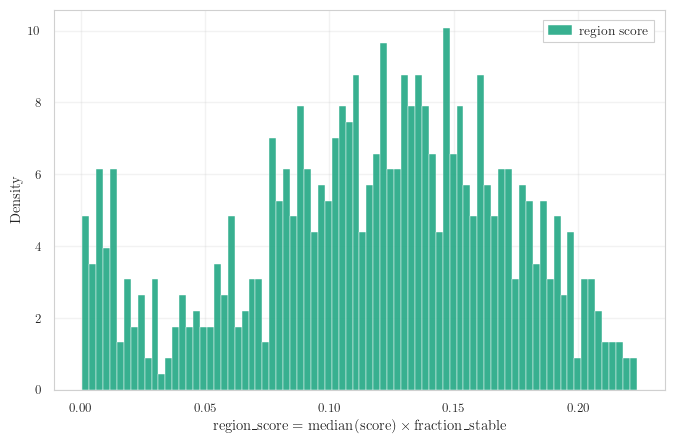

In [36]:
# =============================
# STEP 3b — PLOT: Region_score distribution (selected regions)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


print(f"\nSTEP 3b — Region anchoring: selected regions = {len(region_summary):,}\n")

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

# extract region_score
rs = region_summary.select("region_score").to_numpy().ravel().astype(float)

fig, ax = plt.subplots()

# histogram (viridis mid-green)
hist_color = plt.cm.viridis(0.60)

ax.hist(
    rs,
    bins=80,
    density=True,
    alpha=0.90,
    color=hist_color,
    edgecolor="white",
    linewidth=0.35,
    label=r"$\mathrm{region \; score}$",
)

ax.set_xlabel(r"$\mathrm{region\_score} = \mathrm{median}(\mathrm{score}) \times \mathrm{fraction\_stable}$")
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE FIGURE (PDF)
# -----------------------------
OUTDIR = Path(OUTPUT_DIR) / "plots_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

pdf_path = OUTDIR / f"region_score_distribution.pdf"
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved plot to: {pdf_path}")

plt.show()

In [37]:
# -----------------------------
# STEP 4 — Correlation clustering separato (DIRECTIVE-COMPLIANT)
#   Pool A: |r| >= 0.85  -> connected components -> 1 CpG/cluster (best STEP3 score)
#   Pool B: |r| >= 0.85  -> connected components -> 1 CpG/cluster (best STEP3 score)
#   Output: unione dei rappresentanti (A prima di B, unique)
#
# NOTE (aderenza):
# - correlazioni calcolate SOLO su TRAIN (M_train)
# - "miglior score" = minimo STEP3 score (0.5·mean(rank_p)+0.5·mean(rank_|ΔM|))
# - cluster = componenti connesse del grafo soglia |r|>=thr
# -----------------------------

import numpy as np

print("\n" + "=" * 90)
print("STEP 4 — Correlation clustering separato (Pool A, Pool B) |r|>=0.85")
print("=" * 90)

# CONFIG
CORR_CLUSTER_THR = 0.85

# Assumes from previous steps:
#   - M_train : (n_train, p_all)  TRAIN matrix in M-space (post STEP 2)
#   - cpg_cols_current : (p_all,) CpG names aligned to columns of M_train
#   - cpg_candidates : (n_cand,) top candidates from STEP 3
#   - step3_stats["score"] aligned to cpg_candidates (lower is better)
#   - poolA_cpgs, poolB_cpgs from STEP 3b

cols_all = np.array(cpg_cols_current, dtype=object)
col_to_j = {c: j for j, c in enumerate(cols_all)}

cand = np.array(cpg_candidates, dtype=object)
cand_score = np.array(step3_stats["score"], dtype=float)

# Map CpG -> STEP3 score (used to pick representative)
score_map = {c: s for c, s in zip(cand, cand_score)}

def _build_Z(pool_cpgs: np.ndarray):
    """
    Return standardized TRAIN matrix Z for pool CpGs and the ordered CpG list (aligned to Z columns).
    Standardization is per-CpG on TRAIN only.
    """
    pool = np.array([c for c in pool_cpgs if c in col_to_j], dtype=object)
    if pool.size == 0:
        return np.empty((M_train.shape[0], 0), dtype=np.float32), pool

    jj = np.array([col_to_j[c] for c in pool], dtype=int)
    Xp = M_train[:, jj].astype(np.float32, copy=False)

    mu = Xp.mean(axis=0)
    sd = Xp.std(axis=0, ddof=1) + 1e-12
    Z = (Xp - mu) / sd
    return Z, pool

def _connected_components_from_corr(Z: np.ndarray, thr: float):
    """
    Graph on CpGs where edge(i,j)=1 if |corr(i,j)|>=thr.
    Connected components = clusters.
    corr computed on standardized TRAIN data: C = (Z^T Z)/(n-1).
    """
    p = Z.shape[1]
    if p == 0:
        return []
    if p == 1:
        return [[0]]

    n = Z.shape[0]
    C = (Z.T @ Z) / (n - 1)
    A = (np.abs(C) >= thr)
    np.fill_diagonal(A, True)

    visited = np.zeros(p, dtype=bool)
    comps = []
    for i in range(p):
        if visited[i]:
            continue
        stack = [i]
        visited[i] = True
        comp = []
        while stack:
            u = stack.pop()
            comp.append(u)
            nbrs = np.where(A[u])[0]
            for v in nbrs:
                if not visited[v]:
                    visited[v] = True
                    stack.append(v)
        comps.append(comp)
    return comps

def _pick_rep_by_best_score(pool_order: np.ndarray, comps):
    """Pick 1 CpG per component by minimal STEP3 score (lower is better)."""
    reps = []
    for comp in comps:
        members = pool_order[np.array(comp, dtype=int)]
        scores = np.array([score_map.get(c, np.inf) for c in members], dtype=float)
        best = members[int(np.argmin(scores))]
        reps.append(best)
    return np.array(reps, dtype=object)

def cluster_pool(pool_name: str, pool_cpgs: np.ndarray, thr: float):
    Z, pool_order = _build_Z(pool_cpgs)
    print(f"{pool_name}: CpGs in pool={pool_order.size:,}")

    if pool_order.size == 0:
        return np.array([], dtype=object), np.array([], dtype=int)

    comps = _connected_components_from_corr(Z, thr=thr)
    reps = _pick_rep_by_best_score(pool_order, comps)

    sizes = np.array([len(c) for c in comps], dtype=int)
    print(f"{pool_name}: clusters={len(comps):,} | reps={reps.size:,} | "
          f"median_cluster_size={int(np.median(sizes))} | max_cluster_size={int(sizes.max())}")
    return reps, sizes

# Separate clustering as per directive
reps_A, sizes_A = cluster_pool("Pool A (anchored)", poolA_cpgs, thr=CORR_CLUSTER_THR)
reps_B, sizes_B = cluster_pool("Pool B (non-anchored)", poolB_cpgs, thr=CORR_CLUSTER_THR)

# Union of representatives (A first, then B), unique
reps_union = np.array(list(dict.fromkeys(np.concatenate([reps_A, reps_B]).tolist())), dtype=object)

print(f"Union representatives: {reps_union.size:,} (A={reps_A.size:,}, B={reps_B.size:,})")

# Outputs for STEP 5:
#   reps_A, reps_B, reps_union


STEP 4 — Correlation clustering separato (Pool A, Pool B) |r|>=0.85
Pool A (anchored): CpGs in pool=1,937
Pool A (anchored): clusters=1,888 | reps=1,888 | median_cluster_size=1 | max_cluster_size=46
Pool B (non-anchored): CpGs in pool=13,063
Pool B (non-anchored): clusters=12,952 | reps=12,952 | median_cluster_size=1 | max_cluster_size=110
Union representatives: 14,840 (A=1,888, B=12,952)


[OK] Saved PDF → /kaggle/working/figures/step4/GSE287331_cluster_size_ccdf_loglog_r0.85.pdf


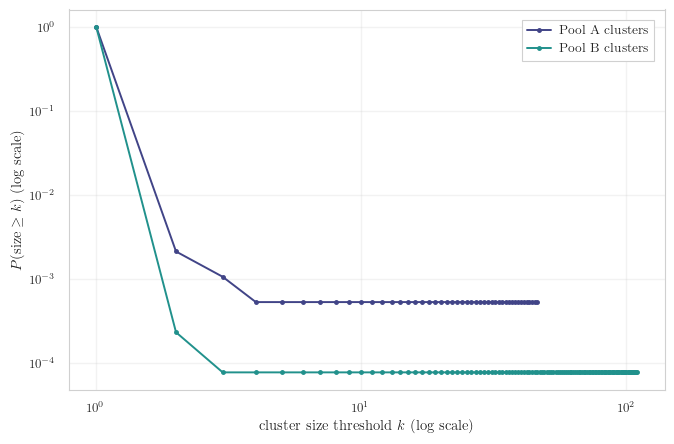

Correlation clustering tail (CCDF), $|r|\geq 0.85$


In [38]:
# =============================
# STEP 4 — PLOT (CCDF log-log, Viridis): Cluster size tail (Pool A vs Pool B)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

def ccdf_from_sizes(sizes: np.ndarray):
    sizes = np.asarray(sizes, dtype=int)
    sizes = sizes[sizes >= 1]
    if sizes.size == 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    max_k = int(sizes.max())
    ks = np.arange(1, max_k + 1, dtype=int)

    hist = np.bincount(sizes, minlength=max_k + 1)
    tail_counts = np.cumsum(hist[::-1])[::-1]
    ccdf = tail_counts[ks] / float(sizes.size)
    return ks, ccdf

kA, ccdfA = ccdf_from_sizes(sizes_A)
kB, ccdfB = ccdf_from_sizes(sizes_B)

if ccdfA.size == 0 and ccdfB.size == 0:
    raise ValueError("Both sizes_A and sizes_B are empty.")

# --- Viridis colors ---
cmap = plt.cm.viridis
color_A = cmap(0.2)
color_B = cmap(0.5)

fig, ax = plt.subplots()

if ccdfA.size:
    ax.plot(kA, ccdfA,
            marker="o", markersize=2.5, linewidth=1.4,
            color=color_A, label="Pool A clusters")

if ccdfB.size:
    ax.plot(kB, ccdfB,
            marker="o", markersize=2.5, linewidth=1.4,
            color=color_B, label="Pool B clusters")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("cluster size threshold $k$ (log scale)")
ax.set_ylabel(r"$P(\mathrm{size}\geq k)$ (log scale)")


place_legend(ax)
fig.tight_layout()

OUT_DIR = Path(OUTPUT_DIR) / "figures" / "step4"
OUT_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUT_DIR / f"GSE287331_cluster_size_ccdf_loglog_r{CORR_CLUSTER_THR:.2f}.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(f"[OK] Saved PDF → {pdf_path}")

plt.show()
print(f"Correlation clustering tail (CCDF), $|r|\geq {CORR_CLUSTER_THR:.2f}$")

In [39]:
# -----------------------------
# STEP 5 — Diversificazione soft + greedy (DIRECTIVE-COMPLIANT)
#   Vincoli (soft, target):
#     - chr <= 20% (sul K target, non dinamico su n_next)
#     - contesto <= 65% (sul K target, non dinamico su n_next)
#     - max 15 CpG / 500kb (vincolo spaziale hard finché non si rilassa)
#   Allentamento: spaziale -> contesto -> chr
# -----------------------------

import numpy as np
import polars as pl

print("\n" + "=" * 90)
print("STEP 5 — Diversification greedy with soft constraints + relaxation (spatial→context→chr)")
print("=" * 90)

# CONFIG
K_TARGET = 5000
CHR_MAX_FRAC = 0.08
CTX_MAX_FRAC = 0.65
WIN_BP = 500_000
MAX_PER_WIN = 15

MANIFEST_CPG_COL = "IlmnID"
MANIFEST_CHR_COL = "CHR"
MANIFEST_POS_COL = "MAPINFO"
MANIFEST_CTX_COL = "Relation_to_UCSC_CpG_Island"

# Assumes:
#   reps_union : (n_reps,)
#   score_map  : dict CpG -> STEP3 score (lower is better)
reps = np.array(reps_union, dtype=object)
if reps.size == 0:
    raise RuntimeError("STEP 5: reps_union is empty.")

# -----------------------------
# A) Manifest mapping CpG -> chr, pos, context
# -----------------------------
# -----------------------------
# Manifest load (robust) + mapping reps
# -----------------------------
mf_pd = load_manifest_with_real_header(MANIFEST_PATH)

# Convert to Polars and normalize the needed columns
mf = pl.from_pandas(mf_pd).select([
    pl.col(MANIFEST_CPG_COL).cast(pl.Utf8).alias("cpg"),
    pl.col(MANIFEST_CHR_COL).cast(pl.Utf8).alias("chr"),
    pl.col(MANIFEST_POS_COL).cast(pl.Int64).alias("pos"),
    pl.col(MANIFEST_CTX_COL).cast(pl.Utf8).alias("ctx"),
]).with_columns([
    pl.col("cpg").fill_null("").str.strip_chars(),
    pl.col("chr").fill_null("").str.strip_chars(),
    pl.col("ctx").fill_null("OpenSea").str.strip_chars(),
])

# Filter only reps
mf = mf.filter(pl.col("cpg").is_in(reps.tolist()))

# Build maps
cpg_to_chr = dict(zip(mf["cpg"].to_list(), mf["chr"].to_list()))
cpg_to_pos = dict(zip(mf["cpg"].to_list(), mf["pos"].to_list()))
cpg_to_ctx = dict(zip(mf["cpg"].to_list(), mf["ctx"].to_list()))

# Keep only reps that map to chr+pos
mapped = []
for c in reps:
    ch = cpg_to_chr.get(c, "")
    ps = cpg_to_pos.get(c, None)
    if ch == "" or ps is None:
        continue
    mapped.append(c)

mapped = np.array(mapped, dtype=object)  # se ti serve come array

print(f"Reps union: {reps.size:,}")
print(f"Mapped reps (chr+pos available): {mapped.size:,}")
if mapped.size == 0:
    raise RuntimeError("STEP 5: No CpGs have manifest chr/pos mapping.")

# -----------------------------
# B) Greedy order by STEP3 score (lower better)
# -----------------------------
scores = np.array([score_map.get(c, np.inf) for c in mapped], dtype=float)
order = np.argsort(scores, kind="mergesort")
cand = mapped[order]
cand_scores = scores[order]

# -----------------------------
# C) Diversification greedy with staged relaxation (budgets on K_TARGET)
# -----------------------------
def diversify_greedy_budgets(
    cand_cpgs: np.ndarray,
    cand_scores: np.ndarray,
    k_target: int,
    enforce_spatial: bool,
    enforce_context: bool,
    enforce_chr: bool,
):
    selected = []
    chr_counts = {}
    ctx_counts = {}
    win_counts = {}  # (chr, win_id) -> count

    # budgets computed vs final K target (directive intent)
    chr_budget = int(np.floor(CHR_MAX_FRAC * k_target))
    ctx_budget = int(np.floor(CTX_MAX_FRAC * k_target))
    chr_budget = max(chr_budget, 1)
    ctx_budget = max(ctx_budget, 1)

    def _ok_chr(ch):
        if not enforce_chr:
            return True
        return (chr_counts.get(ch, 0) + 1) <= chr_budget

    def _ok_ctx(ctx):
        if not enforce_context:
            return True
        return (ctx_counts.get(ctx, 0) + 1) <= ctx_budget

    def _ok_spatial(ch, pos):
        if not enforce_spatial:
            return True
        win_id = int(pos // WIN_BP)
        return (win_counts.get((ch, win_id), 0) + 1) <= MAX_PER_WIN

    for c, s in zip(cand_cpgs, cand_scores):
        if len(selected) >= k_target:
            break

        ch = cpg_to_chr.get(c, "")
        pos = cpg_to_pos.get(c, None)
        ctx = cpg_to_ctx.get(c, "OpenSea")
        if ch == "" or pos is None:
            continue

        if not _ok_spatial(ch, pos):
            continue
        if not _ok_ctx(ctx):
            continue
        if not _ok_chr(ch):
            continue

        # accept
        selected.append(c)
        chr_counts[ch] = chr_counts.get(ch, 0) + 1
        ctx_counts[ctx] = ctx_counts.get(ctx, 0) + 1
        win_id = int(pos // WIN_BP)
        win_counts[(ch, win_id)] = win_counts.get((ch, win_id), 0) + 1

    return np.array(selected, dtype=object), chr_counts, ctx_counts, win_counts, chr_budget, ctx_budget

stages = [
    ("strict",        True,  True,  True),
    ("relax_spatial", False, True,  True),
    ("relax_context", False, False, True),
    ("relax_chr",     False, False, False),
]

selected_final = None
stage_used = None
diag = None

k_eff = min(K_TARGET, cand.size)

for name, e_sp, e_ctx, e_chr in stages:
    sel, chr_ct, ctx_ct, win_ct, chr_budget, ctx_budget = diversify_greedy_budgets(
        cand, cand_scores,
        k_target=k_eff,
        enforce_spatial=e_sp,
        enforce_context=e_ctx,
        enforce_chr=e_chr,
    )
    print(f"Stage={name:>13} | selected={sel.size:,} / {k_eff:,} | chr_budget={chr_budget} | ctx_budget={ctx_budget}")
    selected_final = sel
    stage_used = name
    diag = (chr_ct, ctx_ct, win_ct)
    if sel.size >= k_eff:
        break

selected_diverse = selected_final
print(f"Final selected after diversification: {selected_diverse.size:,} | stage_used={stage_used}")

chr_ct, ctx_ct, win_ct = diag
top_chr = sorted(chr_ct.items(), key=lambda x: -x[1])[:5]
top_ctx = sorted(ctx_ct.items(), key=lambda x: -x[1])[:5]
print("Top 5 chr counts:", top_chr)
print("Top 5 ctx counts:", top_ctx)

# Output for STEP 6:
#   selected_diverse


STEP 5 — Diversification greedy with soft constraints + relaxation (spatial→context→chr)
Reps union: 14,840
Mapped reps (chr+pos available): 14,840
Stage=       strict | selected=5,000 / 5,000 | chr_budget=400 | ctx_budget=3250
Final selected after diversification: 5,000 | stage_used=strict
Top 5 chr counts: [('19', 400), ('1', 400), ('11', 380), ('17', 357), ('2', 308)]
Top 5 ctx counts: [('Island', 3250), ('OpenSea', 850), ('N_Shore', 427), ('S_Shore', 355), ('S_Shelf', 64)]


In [40]:
# -----------------------------
# STEP 6 — Final K selection
#   K = 5000 (take first K from STEP 5 output order)
# -----------------------------

K_FINAL = 5000

# Assumes from STEP 5:
#   selected_diverse : CpG list in chosen greedy order (best-first under constraints)
final_cpgs = np.array(selected_diverse, dtype=object)[:min(K_FINAL, len(selected_diverse))]

print("\n" + "=" * 90)
print(f"STEP 6 — Final CpG set: K={K_FINAL} (got {final_cpgs.size:,})")
print("=" * 90)

# Outputs for downstream modeling:
#   final_cpgs


STEP 6 — Final CpG set: K=5000 (got 5,000)


In [41]:
# ============================================================
# EXPORT — cpg_to_chr
# ============================================================

import numpy as np
from pathlib import Path

if "cpg_to_chr" not in globals():
    raise NameError("cpg_to_chr not found in current scope.")

OUTDIR = Path("./knapsack_exports")
OUTDIR.mkdir(parents=True, exist_ok=True)

out_path = OUTDIR / "cpg_to_chr_GSE287331.npz"

# salva come due array paralleli (chiavi + valori)
keys   = np.array(list(cpg_to_chr.keys()), dtype=object)
values = np.array(list(cpg_to_chr.values()), dtype=object)

np.savez_compressed(out_path, keys=keys, values=values)

print("Saved:", out_path)
print("Entries:", len(keys))

Saved: knapsack_exports/cpg_to_chr_GSE287331.npz
Entries: 14840


Diversification result: chromosome composition (n=5,000)
[OK] Saved PDF → /kaggle/working/figures/step5/dataset_chromosome_share_diversified_K5000_maxfrac0.08.pdf


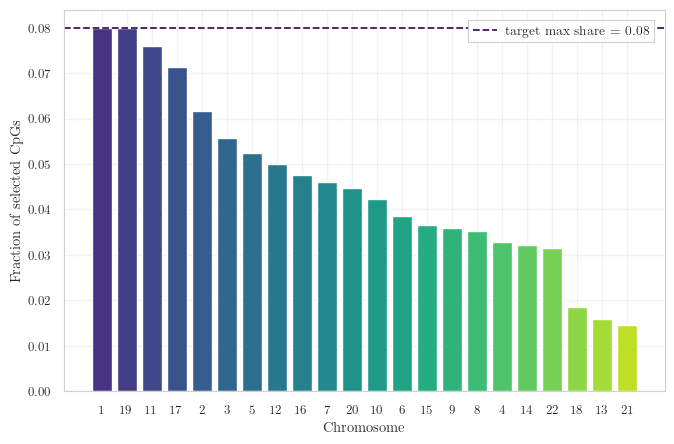

In [42]:
# =============================
# STEP 5 — PLOT: Chromosome share (Viridis + vertical labels)
# =============================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

sel = np.array(selected_diverse, dtype=object)
chrs = np.array([cpg_to_chr.get(c, "") for c in sel], dtype=object)
chrs = chrs[chrs != ""]

# counts and fractions
uniq, cnt = np.unique(chrs, return_counts=True)
frac = cnt / cnt.sum()

# sort descending
ordr = np.argsort(-frac)
uniq, cnt, frac = uniq[ordr], cnt[ordr], frac[ordr]

# --- Viridis colors ---
cmap = plt.cm.viridis
colors = cmap(np.linspace(0.15, 0.90, len(uniq)))

fig, ax = plt.subplots()
ax.bar(np.arange(len(uniq)), frac, color=colors)

ax.axhline(CHR_MAX_FRAC,
           linestyle="--",
           linewidth=1.3,
           color=cmap(0.05),
           label=rf"target max share = {CHR_MAX_FRAC:.2f}")

ax.set_xticks(np.arange(len(uniq)))
ax.set_xticklabels(uniq, rotation=0, ha="center")

ax.set_ylabel("Fraction of selected CpGs")
ax.set_xlabel("Chromosome")
print(f"Diversification result: chromosome composition (n={len(sel):,})")

place_legend(ax)
fig.tight_layout()

# -----------------------------
# SAVE PDF
# -----------------------------
OUT_DIR = Path(OUTPUT_DIR) / "figures" / "step5"
OUT_DIR.mkdir(parents=True, exist_ok=True)

dataset_tag = DATASET_NAME if "DATASET_NAME" in globals() else "dataset"

pdf_path = OUT_DIR / f"{dataset_tag}_chromosome_share_diversified_K{K_TARGET}_maxfrac{CHR_MAX_FRAC:.2f}.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

print(f"[OK] Saved PDF → {pdf_path}")

plt.show()

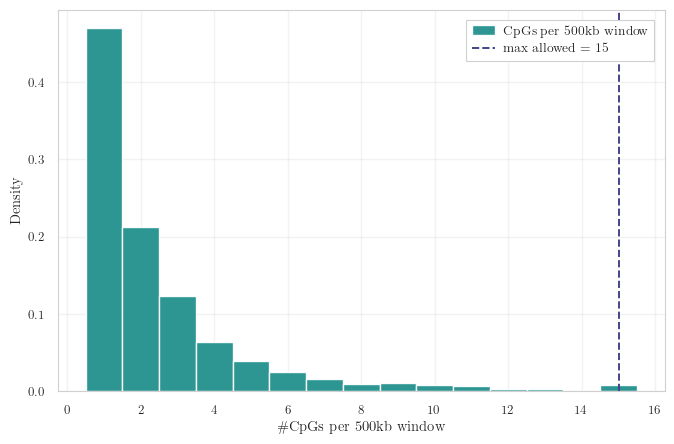

[Spatial density] windows=1979 | max_in_window=15 | violations(cnt>MAX_PER_WIN)=0
Saved as: /kaggle/working/figures/step5/SpatialDensityConstraint.pdf


In [43]:
# =============================
# STEP 5 — Spatial density constraint check
# Save as: SpatialDensityConstraint_<DATASET_NAME>.pdf
# =============================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib import cm
from pathlib import Path


apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

sel = np.array(selected_diverse, dtype=object)

pairs = []
for c in sel:
    ch = cpg_to_chr.get(c, "")
    ps = cpg_to_pos.get(c, None)
    if (ch == "") or (ps is None):
        continue
    win = int(int(ps) // int(WIN_BP))
    pairs.append((str(ch), win))

if len(pairs) == 0:
    raise RuntimeError("No mapped CpGs for spatial window check.")

cnt = np.array(list(Counter(pairs).values()), dtype=int)

color_main = cm.viridis(0.5)
color_line = cm.viridis(0.2)

fig, ax = plt.subplots()

bins = np.arange(1, cnt.max() + 2) - 0.5
ax.hist(cnt,
        bins=bins,
        density=True,
        alpha=0.95,
        color=color_main,
        label=f"CpGs per {WIN_BP//1000}kb window")

ax.axvline(int(MAX_PER_WIN),
           linestyle="--",
           linewidth=1.4,
           color=color_line,
           label=rf"max allowed = {int(MAX_PER_WIN)}")

ax.set_xlabel(f"\#CpGs per {WIN_BP//1000}kb window")
ax.set_ylabel("Density")

place_legend(ax)
fig.tight_layout()

# ---- SAVE ----
OUT_DIR = Path(OUTPUT_DIR) / "figures" / "step5"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plot_name = "SpatialDensityConstraint"
fname = OUT_DIR / f"{plot_name}.pdf"
fig.savefig(fname, dpi=300, bbox_inches="tight")

plt.show()

print(f"[Spatial density] windows={cnt.size} | max_in_window={cnt.max()} | violations(cnt>MAX_PER_WIN)={int(np.sum(cnt > MAX_PER_WIN))}")
print(f"Saved as: {fname}")

In [44]:
# =============================
# EXPORT — final 5000 CpGs
# =============================

import numpy as np
import polars as pl
from pathlib import Path
from datetime import datetime

# Assumes:
#   final_cpgs : np.ndarray (K=5000) from STEP 6

RUN_TAG = "gse287331_225845_fs_v1"   # cambia come vuoi
OUTDIR = Path(OUTPUT_DIR) / "fs_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

final_cpgs = np.array(final_cpgs, dtype=object)

# basic checks
if final_cpgs.size == 0:
    raise RuntimeError("final_cpgs is empty. Check STEP 6.")
if len(np.unique(final_cpgs)) != final_cpgs.size:
    raise RuntimeError("final_cpgs contains duplicates.")

ts = datetime.now().strftime("%Y%m%d_%H%M%S")

# TXT (one per line)
txt_path = OUTDIR / f"final_cpgs_K{final_cpgs.size}_{RUN_TAG}_{ts}.txt"
with open(txt_path, "w") as f:
    for c in final_cpgs:
        f.write(f"{c}\n")

# CSV
csv_path = OUTDIR / f"final_cpgs_K{final_cpgs.size}_{RUN_TAG}_{ts}.csv"
pl.DataFrame({"CpG_ID": final_cpgs}).write_csv(csv_path)

print("Saved CpGs TXT:", txt_path)
print("Saved CpGs CSV:", csv_path)
print("K =", final_cpgs.size)
print("Example:", final_cpgs[:5].tolist())

Saved CpGs TXT: /kaggle/working/fs_outputs/final_cpgs_K5000_gse287331_225845_fs_v1_20260301_211514.txt
Saved CpGs CSV: /kaggle/working/fs_outputs/final_cpgs_K5000_gse287331_225845_fs_v1_20260301_211514.csv
K = 5000
Example: ['cg15866800', 'cg18045461', 'cg01323777', 'cg27596786', 'cg23348582']


In [45]:
# CELLA 13 — STEP 6: Train SVM sulle CpG di final_cpgs
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

# filtra X_tr_combat e X_te_combat alle sole CpG in final_cpgs
final_cpgs_set = set(final_cpgs)
final_cpgs_indices = np.array(
    [col_to_j[c] for c in final_cpgs if c in col_to_j], dtype=int
)

n_missing = sum(1 for c in final_cpgs if c not in col_to_j)
if n_missing > 0:
    print(f"⚠ {n_missing} CpG di final_cpgs non in common_cpgs — escluse.")

X_tr_fs = X_tr_combat[:, final_cpgs_indices]
X_te_fs = X_te_combat[:, final_cpgs_indices]

print(f"CpG in final_cpgs        : {len(final_cpgs)}")
print(f"CpG trovate in common_cpgs: {len(final_cpgs_indices)}")
print(f"X_tr_fs: {X_tr_fs.shape}")
print(f"X_te_fs: {X_te_fs.shape}")

# cross-validation interna per scegliere C
best_auc, best_C = -1, 1.0
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe = Pipeline([
        ("sc",  StandardScaler()),
        ("clf", CalibratedClassifierCV(LinearSVC(C=C, max_iter=5000), cv=3)),
    ])
    scores = cross_val_score(
        pipe, X_tr_fs, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    )
    print(f"  C={C:.3f}  AUC={scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_auc:
        best_auc, best_C = scores.mean(), C

print(f"\nC ottimale: {best_C}  (CV AUC={best_auc:.3f})")

# train finale
svm_final = Pipeline([
    ("sc",  StandardScaler()),
    ("clf", CalibratedClassifierCV(LinearSVC(C=best_C, max_iter=5000), cv=3)),
])
svm_final.fit(X_tr_fs, tissue_labels_tr)
print("SVM trainato.")

CpG in final_cpgs        : 5000
CpG trovate in common_cpgs: 5000
X_tr_fs: (346, 5000)
X_te_fs: (149, 5000)
  C=0.001  AUC=0.991 ± 0.006
  C=0.010  AUC=0.992 ± 0.007
  C=0.100  AUC=0.993 ± 0.006
  C=1.000  AUC=0.993 ± 0.006
  C=10.000  AUC=0.993 ± 0.006

C ottimale: 0.1  (CV AUC=0.993)
SVM trainato.


AUC  overall : 0.990
BACC overall : 0.928
              precision    recall  f1-score   support

      Normal       0.93      0.96      0.94        89
    Adjacent       0.93      0.90      0.92        60

    accuracy                           0.93       149
   macro avg       0.93      0.93      0.93       149
weighted avg       0.93      0.93      0.93       149


AUC per dataset:
  GSE225845: AUC=0.961  BACC=0.870
  GSE287331: AUC=1.000  BACC=1.000


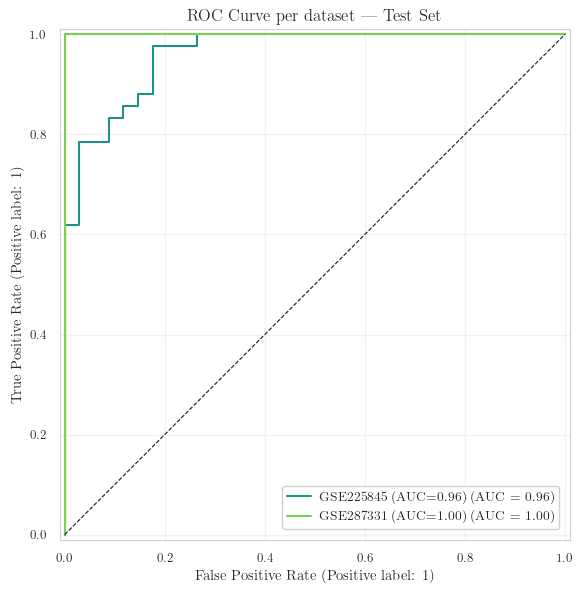

In [46]:
# CELLA 14 — STEP 7: Test e valutazione
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report, RocCurveDisplay

proba_te = svm_final.predict_proba(X_te_fs)[:, 1]
pred_te  = svm_final.predict(X_te_fs)

auc_overall  = roc_auc_score(tissue_labels_te, proba_te)
bacc_overall = balanced_accuracy_score(tissue_labels_te, pred_te)

print("=" * 50)
print(f"AUC  overall : {auc_overall:.3f}")
print(f"BACC overall : {bacc_overall:.3f}")
print("=" * 50)
print(classification_report(tissue_labels_te, pred_te, target_names=["Normal", "Adjacent"]))

# per dataset
print("\nAUC per dataset:")
n_te_offset = 0
for ds in ["GSE225845", "GSE287331"]:
    n_ds = len(X_test_abs[ds])
    mask = np.array(ds_labels_te) == ds
    auc_ds  = roc_auc_score(tissue_labels_te[mask], proba_te[mask])
    bacc_ds = balanced_accuracy_score(tissue_labels_te[mask], pred_te[mask])
    print(f"  {ds}: AUC={auc_ds:.3f}  BACC={bacc_ds:.3f}")

# ROC curve per dataset
fig, ax = plt.subplots(figsize=(7, 6))
for ds in ["GSE225845", "GSE287331"]:
    mask = np.array(ds_labels_te) == ds
    auc_ds = roc_auc_score(tissue_labels_te[mask], proba_te[mask])
    RocCurveDisplay.from_predictions(
        tissue_labels_te[mask], proba_te[mask],
        name=f"{ds} (AUC={auc_ds:.2f})",
        ax=ax, color=DS_PALETTE[ds],
    )
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_title("ROC Curve per dataset — Test Set")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_roc_per_dataset.pdf"), bbox_inches="tight")
plt.show()

In [48]:
def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            parts = [p.strip() for p in line.split(",")]
            if "IlmnID" in parts:
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip"
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

STEP 1 — Estrazione coef SVM
FINAL_CPGS        : 5000
coef range        : [-0.0091, 0.0091]
  pos (ipermet.)  : 2867
  neg (ipomet.)   : 2133

STEP 2 — Tumor  [EVAL_TUMOR=True]
⚠ X_tumor_abs non trovato in scope — EVAL_TUMOR disattivato.

STEP 3 — Score e |ΔM| dal train cross-dataset
dm_tr_abs range   : [-0.0210, 0.2947]
score_proxy range : [0.0011, 0.2263]

STEP 4 — Pool top-5000 per |coef_SVM|
Pool effettivo    : 5000 CpG
|coef| range      : [0.0000, 0.0091]
Pool A nel pool   : 0  →  K_A_use=0

STEP 6 — Conflict edges
Conflict edges    : 224 / 12,497,500 (0.002%) a |r|≥0.85

STEP 7 — Attributi genomici + COSMIC prior
CpG con promotore  : 3782
CpG in island      : 3250
Geni distinti pool : 3311  →  G_min_use=25
CpG COSMIC breast  : 18 (0.4%)
CpG ipermet. pool  : 2867  (coef>0)
CpG ipomet. pool   : 2133  (coef<0)

f1 value range    : [0.0547, 1.0540]  (W_COSMIC=0.3)
f2 norm factor    : 125.0

STEP 10a — Sweep μ  (W_COSMIC=0.3 fissato)

[μ=0.000] Solving...
  Status=Optimal  f1=42.9061 

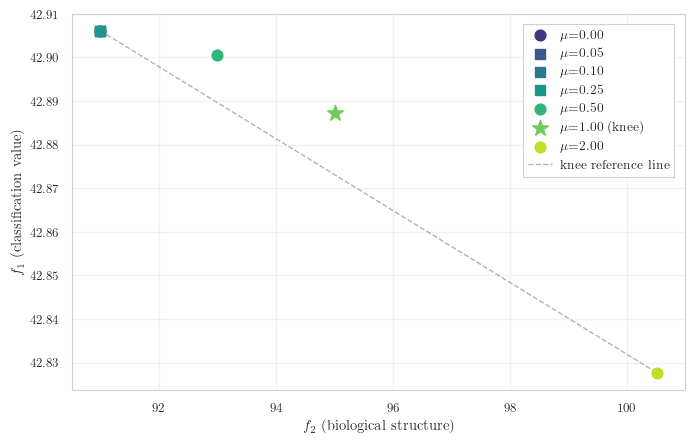

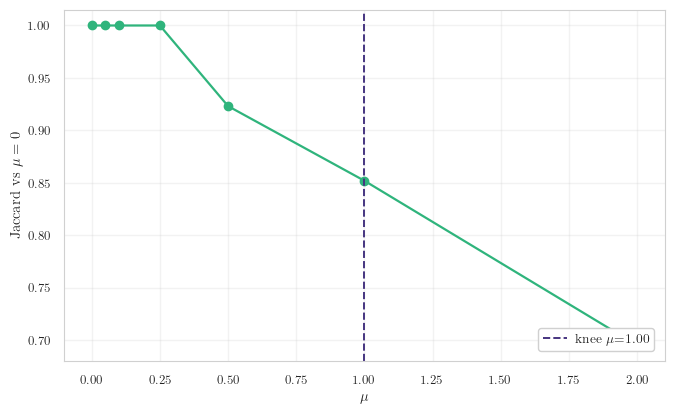

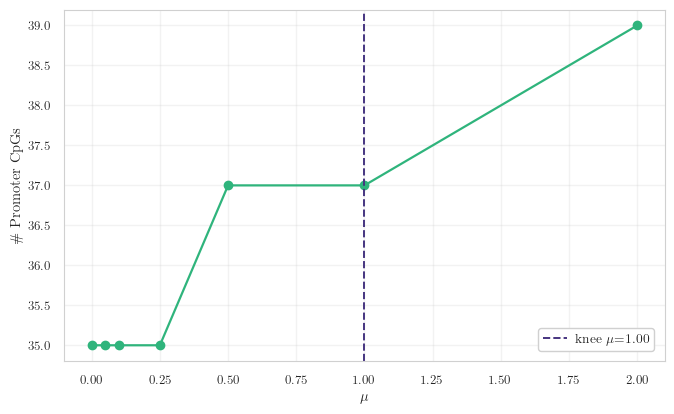

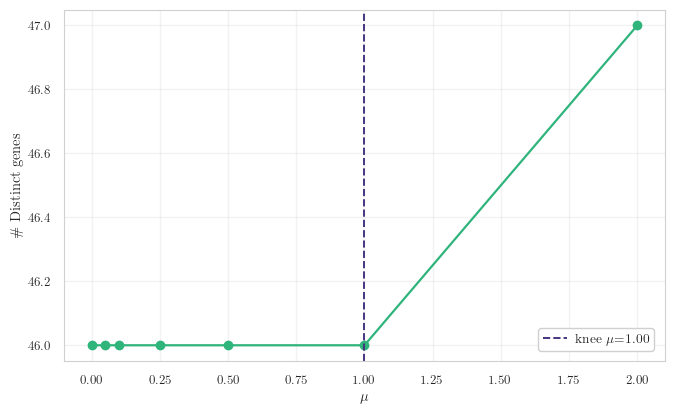

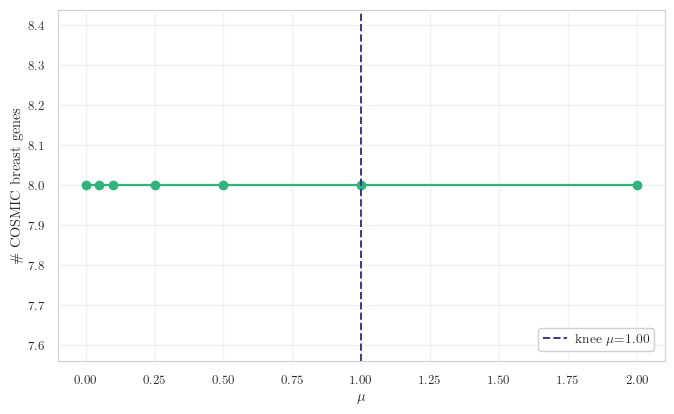

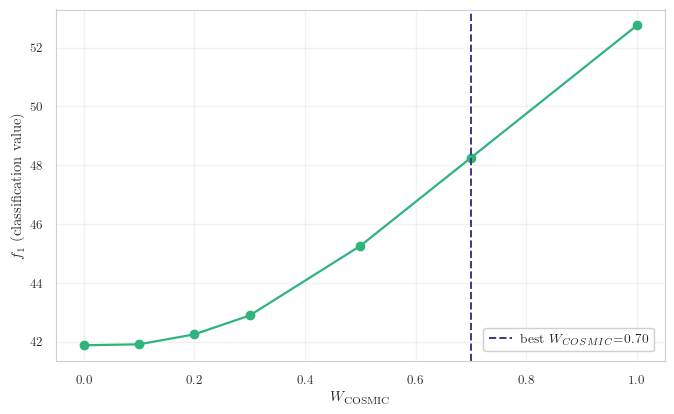

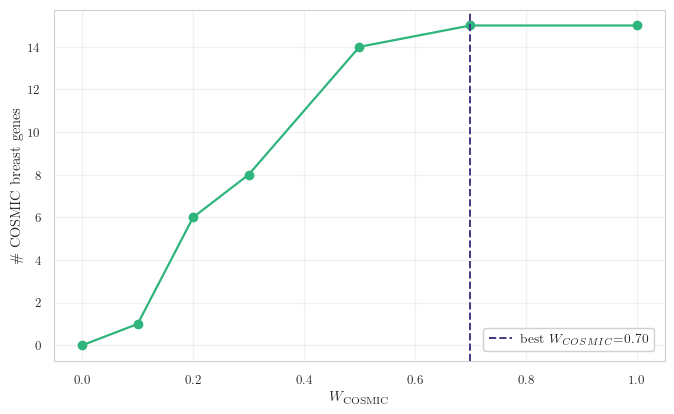

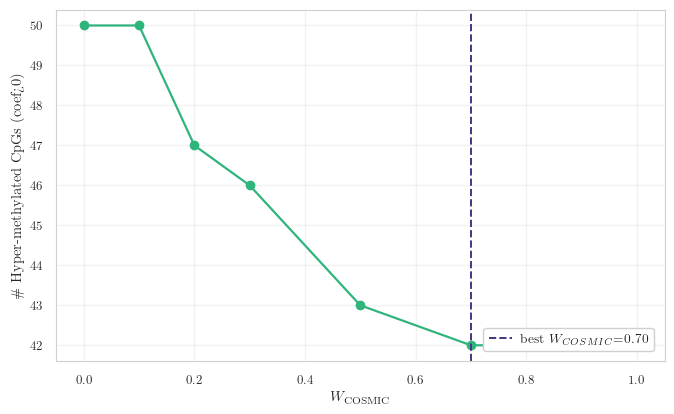

Salvato: /kaggle/working/knapsack_outputs/knapsack_sweep_summary.csv

STEP 15 — Evaluation separazione (50 CpG finali)

  [Normal vs Adjacent (test set cap7)]  n=149 (0=89, 1=60)
  Silhouette    : 0.1885
  AUC CV5       : 0.9593 ± 0.0541
  mean|ΔM|      : 0.0124
  PCA PC1       : 0.444
  [GSE69914] campioni insufficienti nel test — skip

  [Normal vs Adjacent — GSE225845]  n=76 (0=34, 1=42)
  Silhouette    : 0.0226
  AUC CV5       : 0.8999 ± 0.0648
  mean|ΔM|      : 0.0046
  PCA PC1       : 0.282

  [Normal vs Adjacent — GSE287331]  n=73 (0=55, 1=18)
  Silhouette    : 0.5039
  AUC CV5       : 1.0000 ± 0.0000
  mean|ΔM|      : 0.0247
  PCA PC1       : 0.530

STEP 16 — Confronto μ=0 vs set finale
  f1                       : μ=0 → 42.90614122824566   finale → 48.252490498099625
  f2                       : μ=0 → 91.0   finale → 91.0
  n_promoter               : μ=0 → 35   finale → 33
  n_island                 : μ=0 → 33   finale → 37
  n_genes                  : μ=0 → 46   finale → 42
 

In [49]:
# ============================================================
# CpG KNAPSACK — MILP bi-obiettivo con sweep su μ  [v2 cap7]
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
import pulp
import csv
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
CGC_PATH      = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

ID_COL        = "id_tissue"
LABEL_COL     = "label"

K             = 50
N_POOL        = 5000
CHR_MAX       = 10
CORR_THR      = 0.85
ETA           = 0.5

W_COEF        = 0.5
W_DM          = 0.2
W_SCORE       = 0.3
W_COSMIC      = 0.3
W_COSMIC_GRID = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1]

K_A_NOMINAL   = 25
G_MIN_NOMINAL = 25
MAX_PER_GENE  = 2
MIN_HYPER     = 15

MU_GRID       = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

EVAL_TUMOR    = True
CBC_TIME_LIMIT = 120
EPS_M          = 1e-6
RANDOM_STATE   = 42

OUTDIR = Path(OUTPUT_DIR) / "knapsack_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

# alias per uniformità con il codice originale
cpg_cols_current = final_cpgs   # 5000 CpG post-FS
FINAL_CPGS       = final_cpgs

# ─────────────────────────────────────────────────────────────
# HELPERS (identici all'originale)
# ─────────────────────────────────────────────────────────────
def beta_to_m(b, eps=EPS_M):
    b = np.clip(b, 0.0, 1.0)
    return np.log2((b + eps) / (1.0 - b + eps))

def rank_norm_asc(v):
    v = np.asarray(v, float)
    v2 = v.copy()
    if np.isnan(v2).any():
        v2 = np.where(np.isnan(v2), np.nanmin(v2) - 1.0, v2)
    r = np.argsort(np.argsort(v2))
    return r / max(1, len(v2) - 1)

def rank_norm_desc(v):
    return 1.0 - rank_norm_asc(v)

def parse_first_gene(g):
    if g is None:
        return None
    s = str(g).strip()
    if s == "" or s.lower() == "nan":
        return None
    for sep in [";", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s != "" else None

def in_promoter(feat):
    if feat is None:
        return False
    s = str(feat)
    return any(k in s for k in ["TSS200", "TSS1500", "1stExon", "5'UTR", "5UTR"])

def in_island(ctx):
    if ctx is None:
        return False
    s = str(ctx)
    return "Island" in s and "Shore" not in s and "Shelf" not in s

def jaccard(s1, s2):
    s1, s2 = set(s1), set(s2)
    if len(s1 | s2) == 0:
        return 1.0
    return len(s1 & s2) / len(s1 | s2)

def knee_index(f1_vals, f2_vals):
    f1 = np.array(f1_vals, float)
    f2 = np.array(f2_vals, float)
    valid = np.ones(len(f2), dtype=bool)
    for i in range(1, len(f2)):
        if f2[i] == f2[i - 1]:
            valid[i] = False
    idx_v = np.where(valid)[0]
    if len(idx_v) < 2:
        return 0
    f1_n = (f1[idx_v] - f1[idx_v].min()) / max(f1[idx_v].max() - f1[idx_v].min(), 1e-12)
    f2_n = (f2[idx_v] - f2[idx_v].min()) / max(f2[idx_v].max() - f2[idx_v].min(), 1e-12)
    p0 = np.array([f2_n[0],  f1_n[0]])
    p1 = np.array([f2_n[-1], f1_n[-1]])
    d  = p1 - p0
    d_norm = d / max(np.linalg.norm(d), 1e-12)
    dists = [
        np.linalg.norm(
            (np.array([f2_n[i], f1_n[i]]) - p0)
            - np.dot(np.array([f2_n[i], f1_n[i]]) - p0, d_norm) * d_norm
        )
        for i in range(len(idx_v))
    ]
    return int(idx_v[np.argmax(dists)])

def eval_pair(name, X, ybin):
    out = {}
    n0, n1 = int((ybin == 0).sum()), int((ybin == 1).sum())
    print(f"\n  [{name}]  n={X.shape[0]} (0={n0}, 1={n1})")
    if X.shape[0] < 10 or n0 == 0 or n1 == 0:
        print("  Campioni insufficienti.")
        return out
    try:
        out["silhouette"] = float(silhouette_score(X, ybin, metric="euclidean"))
        print(f"  Silhouette    : {out['silhouette']:.4f}")
    except Exception as e:
        out["silhouette"] = None
        print(f"  Silhouette    : N/A ({e})")
    try:
        Xsc  = StandardScaler().fit_transform(X)
        lr   = LogisticRegression(C=1.0, class_weight="balanced",
                                  max_iter=2000, random_state=RANDOM_STATE)
        n_cv = min(5, n0, n1)
        aucs = cross_val_score(lr, Xsc, ybin, cv=n_cv, scoring="roc_auc")
        out["auc_mean"] = float(aucs.mean())
        out["auc_std"]  = float(aucs.std())
        print(f"  AUC CV{n_cv}       : {out['auc_mean']:.4f} ± {out['auc_std']:.4f}")
    except Exception as e:
        out["auc_mean"] = out["auc_std"] = None
        print(f"  AUC CV        : N/A ({e})")
    m0, m1 = X[ybin == 0].mean(0), X[ybin == 1].mean(0)
    out["mean_abs_dM"] = float(np.abs(m1 - m0).mean())
    print(f"  mean|ΔM|      : {out['mean_abs_dM']:.4f}")
    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca.fit(StandardScaler().fit_transform(X))
        out["pca_pc1"] = float(pca.explained_variance_ratio_[0])
        print(f"  PCA PC1       : {out['pca_pc1']:.3f}")
    except:
        out["pca_pc1"] = None
    return out

# ─────────────────────────────────────────────────────────────
# STEP 1 — Estrai coef SVM da svm_final (CalibratedClassifierCV)
# ─────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 1 — Estrazione coef SVM")
print("=" * 70)

# col_to_j: mappa CpG → indice in X_tr_fs / X_te_fs (5000 CpG)
cols_all  = np.array(FINAL_CPGS, dtype=object)
col_to_j  = {c: j for j, c in enumerate(cols_all.tolist())}
final_arr = np.array(FINAL_CPGS, dtype=object)

# estrai coef mediati dai fold di CalibratedClassifierCV
raw_coef = np.mean(
    [est.estimator.coef_[0]
     for est in svm_final.named_steps["clf"].calibrated_classifiers_],
    axis=0
)
assert raw_coef.size == final_arr.size, (
    f"coef size {raw_coef.size} != FINAL_CPGS size {final_arr.size}."
)
coef_final = raw_coef

print(f"FINAL_CPGS        : {final_arr.size}")
print(f"coef range        : [{coef_final.min():.4f}, {coef_final.max():.4f}]")
print(f"  pos (ipermet.)  : {(coef_final > 0).sum()}")
print(f"  neg (ipomet.)   : {(coef_final < 0).sum()}")

# ─────────────────────────────────────────────────────────────
# STEP 2 — Tumor per EVAL_TUMOR (già in X_tumor_abs da cella precedente)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 2 — Tumor{'  [EVAL_TUMOR=True]' if EVAL_TUMOR else '  [skip]'}")
print("=" * 70)

if EVAL_TUMOR:
    if "X_tumor_abs" not in dir():
        print("⚠ X_tumor_abs non trovato in scope — EVAL_TUMOR disattivato.")
        EVAL_TUMOR = False
    else:
        # restringe alle sole FINAL_CPGS (col_to_j già su 5000 CpG)
        # X_tumor_abs ha shape (n_tumor, n_common_cpgs) → dobbiamo prendere le colonne
        # corrispondenti alle final_cpgs usando gli indici in common_cpgs
        jj_final_in_common = np.array(
            [common_cpgs.index(c) for c in FINAL_CPGS if c in set(common_cpgs)],
            dtype=int
        )
        X_tumor_fs = X_tumor_abs[:, jj_final_in_common]
        print(f"X_tumor_fs shape  : {X_tumor_fs.shape}")

# ─────────────────────────────────────────────────────────────
# STEP 3 — Score e |ΔM| dal train cap7 (sostituisce step3_stats)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 3 — Score e |ΔM| dal train cross-dataset")
print("=" * 70)

# dm_tr_abs e score_proxy già calcolati nella cella del knapsack setup
# se non presenti li ricalcoliamo ora su X_tr_fs
dm_tr_abs   = (
    X_tr_fs[tissue_labels_tr == 1].mean(axis=0) -
    X_tr_fs[tissue_labels_tr == 0].mean(axis=0)
)
score_proxy = X_tr_fs.std(axis=0)

# allinea a final_arr (già nello stesso ordine di X_tr_fs)
score_final = score_proxy          # shape (n_final_cpgs,) = (5000,)
absdM_final = np.abs(dm_tr_abs)   # shape (n_final_cpgs,) = (5000,)

print(f"dm_tr_abs range   : [{dm_tr_abs.min():.4f}, {dm_tr_abs.max():.4f}]")
print(f"score_proxy range : [{score_proxy.min():.4f}, {score_proxy.max():.4f}]")

# ─────────────────────────────────────────────────────────────
# STEP 4 — Pool top-N per |coef|
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 4 — Pool top-{N_POOL} per |coef_SVM|")
print("=" * 70)

order_coef = np.argsort(-np.abs(coef_final))
pool_idx   = order_coef[:N_POOL]

pool_cpgs  = final_arr[pool_idx]
pool_coef  = coef_final[pool_idx]
pool_score = score_final[pool_idx]
pool_absdM = absdM_final[pool_idx]

# verifica che tutte le CpG del pool siano in col_to_j (devono esserlo per costruzione)
valid_mask = np.array([c in col_to_j for c in pool_cpgs], dtype=bool)
if not valid_mask.all():
    print(f"  ⚠ Rimosse {(~valid_mask).sum()} CpG non in col_to_j.")
    pool_cpgs  = pool_cpgs[valid_mask]
    pool_coef  = pool_coef[valid_mask]
    pool_score = pool_score[valid_mask]
    pool_absdM = pool_absdM[valid_mask]

n_p = len(pool_cpgs)
print(f"Pool effettivo    : {n_p} CpG")
print(f"|coef| range      : [{np.abs(pool_coef).min():.4f}, {np.abs(pool_coef).max():.4f}]")

# ─────────────────────────────────────────────────────────────
# STEP 5 — Pool A / B
# ─────────────────────────────────────────────────────────────
poolA_cpgs = None
poolB_cpgs = None

_poolA_set = set(np.array(poolA_cpgs, dtype=object).tolist()) if poolA_cpgs is not None else set()
_poolB_set = set(np.array(poolB_cpgs, dtype=object).tolist()) if poolB_cpgs is not None else set()

poolA_in_pool = [c for c in pool_cpgs if c in _poolA_set]
K_A_use = min(K_A_NOMINAL, len(poolA_in_pool))
print(f"Pool A nel pool   : {len(poolA_in_pool)}  →  K_A_use={K_A_use}")

# ─────────────────────────────────────────────────────────────
# STEP 6 — Conflict edges (correlazione su X_tr_fs)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 6 — Conflict edges")
print("=" * 70)

jj_pool = np.array([col_to_j[c] for c in pool_cpgs], dtype=int)
Z = X_tr_fs[:, jj_pool].astype(np.float64)
Z = (Z - Z.mean(0)) / (Z.std(0, ddof=1) + 1e-12)
C_corr = (Z.T @ Z) / (Z.shape[0] - 1)

i_u, j_u = np.where(np.triu(np.abs(C_corr) >= CORR_THR, k=1))
conflict_pairs = list(zip(i_u.tolist(), j_u.tolist()))

tot_pairs = n_p * (n_p - 1) // 2
print(f"Conflict edges    : {len(conflict_pairs):,} / {tot_pairs:,} "
      f"({100*len(conflict_pairs)/max(1,tot_pairs):.3f}%) a |r|≥{CORR_THR}")

# ─────────────────────────────────────────────────────────────
# STEP 7 — Attributi genomici + COSMIC
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 7 — Attributi genomici + COSMIC prior")
print("=" * 70)

man_sub = man.loc[
    man["IlmnID"].isin(pool_cpgs.tolist()),
    ["IlmnID", "UCSC_RefGene_Name", "UCSC_RefGene_Group", "Relation_to_UCSC_CpG_Island"]
].copy()
man_sub["IlmnID"] = man_sub["IlmnID"].astype(str)

cpg_gene_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Name"].fillna("")))
cpg_feat_dict   = dict(zip(man_sub["IlmnID"], man_sub["UCSC_RefGene_Group"].fillna("")))
cpg_island_dict = dict(zip(man_sub["IlmnID"], man_sub["Relation_to_UCSC_CpG_Island"].fillna("")))

chr_arr   = np.array([cpg_to_chr.get(c, "")                         for c in pool_cpgs], dtype=object)
gene_arr  = np.array([parse_first_gene(cpg_gene_dict.get(c, None))  for c in pool_cpgs], dtype=object)
is_prom   = np.array([in_promoter(cpg_feat_dict.get(c, ""))         for c in pool_cpgs], dtype=int)
is_island = np.array([in_island(cpg_island_dict.get(c, ""))         for c in pool_cpgs], dtype=int)

genes_pool = sorted({g for g in gene_arr.tolist() if g is not None})
G_min_use  = min(G_MIN_NOMINAL, len(genes_pool))

cgc = pd.read_csv(CGC_PATH, sep="\t")
mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
COSMIC_BREAST_GENES = set(cgc.loc[mask_breast, "GENE_SYMBOL"].astype(str))

is_cosmic = np.array(
    [1.0 if (gene_arr[i] is not None and gene_arr[i] in COSMIC_BREAST_GENES) else 0.0
     for i in range(n_p)], dtype=float
)
is_hyper = np.array([1 if pool_coef[i] > 0 else 0 for i in range(n_p)], dtype=int)

print(f"CpG con promotore  : {is_prom.sum()}")
print(f"CpG in island      : {is_island.sum()}")
print(f"Geni distinti pool : {len(genes_pool)}  →  G_min_use={G_min_use}")
print(f"CpG COSMIC breast  : {int(is_cosmic.sum())} ({100*is_cosmic.mean():.1f}%)")
print(f"CpG ipermet. pool  : {is_hyper.sum()}  (coef>0)")
print(f"CpG ipomet. pool   : {(1-is_hyper).sum()}  (coef<0)")

if MIN_HYPER > is_hyper.sum():
    print(f"  ⚠ MIN_HYPER={MIN_HYPER} > CpG ipermet. nel pool ({is_hyper.sum()}).")

F2_NORM = float(K * (2 + ETA))

# ─────────────────────────────────────────────────────────────
# STEP 8 — Funzione valore f1
# ─────────────────────────────────────────────────────────────
def compute_value(w_cosmic):
    r_coef  = rank_norm_asc(np.abs(pool_coef))
    r_dM    = rank_norm_asc(pool_absdM)
    r_score = rank_norm_desc(pool_score)
    return W_COEF * r_coef + W_DM * r_dM + W_SCORE * r_score + w_cosmic * is_cosmic

value_main = compute_value(W_COSMIC)
print(f"\nf1 value range    : [{value_main.min():.4f}, {value_main.max():.4f}]  (W_COSMIC={W_COSMIC})")
print(f"f2 norm factor    : {F2_NORM:.1f}")

# ─────────────────────────────────────────────────────────────
# STEP 9 — Funzione MILP (identica all'originale)
# ─────────────────────────────────────────────────────────────
def solve_milp(mu: float, value: np.ndarray, label: str = ""):
    prob = pulp.LpProblem(f"CpG_Knapsack_{label}_mu{mu:.3f}", pulp.LpMaximize)
    x   = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n_p)]
    y_g = {g: pulp.LpVariable(f"yg_{i}", cat="Binary") for i, g in enumerate(genes_pool)}

    f1_expr = pulp.lpSum(float(value[i]) * x[i] for i in range(n_p))
    f2_expr = (
        pulp.lpSum(x[i] for i in range(n_p) if is_prom[i])
        + pulp.lpSum(x[i] for i in range(n_p) if is_island[i])
        + ETA * pulp.lpSum(y_g[g] for g in genes_pool)
    )
    f2_hat = f2_expr / F2_NORM
    prob  += f1_expr + mu * f2_hat

    prob += pulp.lpSum(x) == K, "C1"
    for idx, (i, j) in enumerate(conflict_pairs):
        prob += x[i] + x[j] <= 1, f"C2_{idx}"
    for ch in sorted(set(chr_arr.tolist()) - {""}):
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if chr_arr[i] == ch)
            <= CHR_MAX, f"C3_{ch}"
        )
    if K_A_use > 0 and len(_poolA_set) > 0:
        prob += (
            pulp.lpSum(x[i] for i in range(n_p) if pool_cpgs[i] in _poolA_set)
            >= K_A_use, "C4"
        )
    for i in range(n_p):
        g = gene_arr[i]
        if g is not None and g in y_g:
            prob += x[i] <= y_g[g], f"C5_{i}"
    for g in genes_pool:
        idx_g = [i for i in range(n_p) if gene_arr[i] == g]
        if idx_g:
            prob += pulp.lpSum(x[i] for i in idx_g) <= MAX_PER_GENE, f"C6_{g}"
    if G_min_use > 0:
        prob += pulp.lpSum(y_g[g] for g in genes_pool) >= G_min_use, "C7"
    if MIN_HYPER > 0:
        n_hyper_in_pool = int(is_hyper.sum())
        if n_hyper_in_pool >= MIN_HYPER:
            prob += (
                pulp.lpSum(x[i] for i in range(n_p) if is_hyper[i])
                >= MIN_HYPER, "C8_hyper_min"
            )
        else:
            print(f"  ⚠ C8 disattivato: {n_hyper_in_pool} < MIN_HYPER={MIN_HYPER}")

    solver     = pulp.PULP_CBC_CMD(msg=False, timeLimit=CBC_TIME_LIMIT)
    status     = prob.solve(solver)
    status_str = pulp.LpStatus.get(status, str(status))
    obj_val    = pulp.value(prob.objective)

    if obj_val is None or status_str not in ["Optimal", "Feasible"]:
        print(f"  [{label} μ={mu:.3f}] Status={status_str} — INFEASIBLE")
        return None

    sel_idx = np.array([i for i in range(n_p) if (pulp.value(x[i]) or 0) > 0.5], dtype=int)
    if sel_idx.size != K:
        print(f"  [{label} μ={mu:.3f}] Selezionato {sel_idx.size}/{K} — SKIP")
        return None

    selected   = pool_cpgs[sel_idx].tolist()
    f1_val     = float(sum(value[i] for i in sel_idx))
    f2_val     = float(
        is_prom[sel_idx].sum()
        + is_island[sel_idx].sum()
        + ETA * len({gene_arr[i] for i in sel_idx if gene_arr[i] is not None})
    )
    f2_hat_val = f2_val / F2_NORM
    n_cosmic   = int(is_cosmic[sel_idx].sum())
    n_hyper_sel= int(is_hyper[sel_idx].sum())

    return {
        "status":     status_str,
        "f1":         f1_val,
        "f2":         f2_val,
        "f2_hat":     f2_hat_val,
        "n_promoter": int(is_prom[sel_idx].sum()),
        "n_island":   int(is_island[sel_idx].sum()),
        "n_genes":    len({gene_arr[i] for i in sel_idx if gene_arr[i] is not None}),
        "n_cosmic":   n_cosmic,
        "n_hyper":    n_hyper_sel,
        "n_hypo":     K - n_hyper_sel,
        "selected":   selected,
        "sel_idx":    sel_idx,
    }

# ─────────────────────────────────────────────────────────────
# STEP 10a — Sweep principale su μ
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 10a — Sweep μ  (W_COSMIC={W_COSMIC} fissato)")
print("=" * 70)

sweep_results = []
sel_mu0       = None

for mu in MU_GRID:
    print(f"\n[μ={mu:.3f}] Solving...")
    res = solve_milp(mu, value_main, label="main")
    if res is None:
        sweep_results.append({"mu": mu, "f1": np.nan, "f2": np.nan,
                               "f2_hat": np.nan, "status": "FAILED",
                               "jaccard_vs_0": np.nan, "saturated": False,
                               "n_promoter": np.nan, "n_island": np.nan,
                               "n_genes": np.nan, "n_cosmic": np.nan,
                               "n_hyper": np.nan, "selected": []})
        continue
    if mu == 0.0:
        sel_mu0 = res["selected"]
    jacc  = jaccard(res["selected"], sel_mu0) if sel_mu0 else 1.0
    delta = (mu * res["f2_hat"]) / max(res["f1"], 1e-12)
    sat   = (len(sweep_results) > 0
             and not np.isnan(sweep_results[-1].get("f2", np.nan))
             and res["f2"] == sweep_results[-1]["f2"])
    row = {"mu": mu, **res, "jaccard_vs_0": jacc, "delta": delta, "saturated": sat}
    sweep_results.append(row)
    print(f"  Status={res['status']}  f1={res['f1']:.4f}  f2={res['f2']:.4f}  "
          f"Jaccard(0)={jacc:.4f}  COSMIC={res['n_cosmic']}  "
          f"Ipermet={res['n_hyper']}  Sat={sat}")

# ─────────────────────────────────────────────────────────────
# STEP 11 — Knee
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 11 — Selezione knee")
print("=" * 70)

valid_res = [r for r in sweep_results if not np.isnan(r["f1"])]
k_idx     = knee_index([r["f1"] for r in valid_res], [r["f2"] for r in valid_res])
knee_res  = valid_res[k_idx]
knee_mu   = knee_res["mu"]

print(f"Knee: μ={knee_mu:.3f}  f1={knee_res['f1']:.4f}  f2={knee_res['f2']:.4f}  "
      f"COSMIC={knee_res['n_cosmic']}  Ipermet/Ipomet={knee_res['n_hyper']}/{knee_res['n_hypo']}")

selected_cpgs_final = knee_res["selected"]

# ─────────────────────────────────────────────────────────────
# STEP 10b — Sweep W_COSMIC (μ fissato al knee)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"STEP 10b — Sweep W_COSMIC  (μ={knee_mu} fissato)")
print("=" * 70)

cosmic_sweep_results = []
for wc in W_COSMIC_GRID:
    print(f"\n[W_COSMIC={wc:.2f}] Solving...")
    val_wc = compute_value(wc)
    res    = solve_milp(knee_mu, val_wc, label=f"cosmic{wc:.2f}")
    if res is None:
        cosmic_sweep_results.append({"w_cosmic": wc, "f1": np.nan, "f2": np.nan,
                                      "n_cosmic": np.nan, "n_hyper": np.nan,
                                      "status": "FAILED", "selected": []})
        continue
    jacc_vs_wc0 = jaccard(
        res["selected"],
        next((r["selected"] for r in cosmic_sweep_results
              if r.get("w_cosmic") == 0.0 and r["selected"]), [])
    )
    cosmic_sweep_results.append({"w_cosmic": wc, **res, "jaccard_vs_wc0": jacc_vs_wc0})
    print(f"  f1={res['f1']:.4f}  f2={res['f2']:.4f}  COSMIC={res['n_cosmic']}  "
          f"Ipermet={res['n_hyper']}  Jaccard(wc=0)={jacc_vs_wc0:.4f}")

wc_valid = [r for r in cosmic_sweep_results if not np.isnan(r.get("f1", np.nan))]
if wc_valid:
    f1_wc0 = next((r["f1"] for r in wc_valid if r["w_cosmic"] == 0.0), wc_valid[0]["f1"])
    candidates_wc   = [r for r in wc_valid if r["f1"] >= f1_wc0 * 0.999]
    best_wc_res     = max(candidates_wc, key=lambda r: r["n_cosmic"]) if candidates_wc else wc_valid[-1]
    best_w_cosmic   = best_wc_res["w_cosmic"]
    selected_cpgs_final = best_wc_res["selected"]
    print(f"\nW_COSMIC ottimale: {best_w_cosmic:.2f}  COSMIC={best_wc_res['n_cosmic']}  "
          f"f1={best_wc_res['f1']:.4f}  perdita={100*(f1_wc0-best_wc_res['f1'])/max(f1_wc0,1e-12):.3f}%")
else:
    best_w_cosmic = W_COSMIC
    print("⚠ Sweep W_COSMIC fallito — uso knee μ.")

# ─────────────────────────────────────────────────────────────
# STEP 12 — Trade-off curve
# ─────────────────────────────────────────────────────────────
try:
    apply_thesis_style(use_tex=True, legend_position="upper right")
except:
    pass

cmap      = plt.cm.viridis
valid_res = [r for r in sweep_results if not np.isnan(r.get("f1", np.nan))]
f1_vals   = [r["f1"] for r in valid_res]
f2_vals   = [r["f2"] for r in valid_res]

fig, ax = plt.subplots(figsize=(7.0, 4.5))
colors  = cmap(np.linspace(0.15, 0.90, len(valid_res)))
for r, col in zip(valid_res, colors):
    is_knee = (r["mu"] == knee_mu)
    marker  = "*" if is_knee else ("s" if r.get("saturated") else "o")
    size    = 140 if is_knee else 60
    ax.scatter(r["f2"], r["f1"], color=col, marker=marker, s=size, zorder=3,
               label=(rf"$\mu$={r['mu']:.2f}" + ("  (knee)" if is_knee else "")))
p0 = np.array([f2_vals[0], f1_vals[0]])
p1 = np.array([max(f2_vals), f1_vals[np.argmax(f2_vals)]])
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], "--", color="gray", lw=1.0, alpha=0.6,
        label="knee reference line")
ax.set_xlabel(r"$f_2$ (biological structure)")
ax.set_ylabel(r"$f_1$ (classification value)")
try:
    place_legend(ax)
except:
    ax.legend(fontsize=8, ncol=2, frameon=True)
fig.tight_layout()
fig.savefig(OUTDIR / "knapsack_tradeoff_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 13 — μ sweep diagnostics
# ─────────────────────────────────────────────────────────────
try:
    apply_thesis_style(use_tex=True, legend_position="lower right")
except:
    pass

mu_ax = [r["mu"] for r in valid_res]

def _plot_mu_metric(key, ylab, fname):
    vals = [r.get(key, np.nan) for r in valid_res]
    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    ax.plot(mu_ax, vals, marker="o", color=cmap(0.65), linewidth=1.6)
    ax.axvline(knee_mu, linestyle="--", color=cmap(0.15), lw=1.4,
               label=rf"knee $\mu$={knee_mu:.2f}")
    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel(ylab)
    ax.legend(frameon=True)
    fig.tight_layout()
    fig.savefig(OUTDIR / fname, dpi=300, bbox_inches="tight")
    plt.show()

_plot_mu_metric("jaccard_vs_0", r"Jaccard vs $\mu=0$",      "knapsack_mu_jaccard.pdf")
_plot_mu_metric("n_promoter",   r"\# Promoter CpGs",        "knapsack_mu_promoter.pdf")
_plot_mu_metric("n_genes",      r"\# Distinct genes",       "knapsack_mu_genes.pdf")
_plot_mu_metric("n_cosmic",     r"\# COSMIC breast genes",  "knapsack_mu_cosmic.pdf")

# ─────────────────────────────────────────────────────────────
# STEP 13b — W_COSMIC sweep diagnostics
# ─────────────────────────────────────────────────────────────
if len(wc_valid) >= 2:
    try:
        apply_thesis_style(use_tex=True, legend_position="lower right")
    except:
        pass
    wc_ax = [r["w_cosmic"] for r in wc_valid]

    def _plot_wc_metric(key, ylab, fname):
        vals = [r.get(key, np.nan) for r in wc_valid]
        fig, ax = plt.subplots(figsize=(6.8, 4.2))
        ax.plot(wc_ax, vals, marker="o", color=cmap(0.65), linewidth=1.6)
        ax.axvline(best_w_cosmic, linestyle="--", color=cmap(0.15), lw=1.4,
                   label=rf"best $W_{{COSMIC}}$={best_w_cosmic:.2f}")
        ax.set_xlabel(r"$W_{\mathrm{COSMIC}}$")
        ax.set_ylabel(ylab)
        ax.legend(frameon=True)
        fig.tight_layout()
        fig.savefig(OUTDIR / fname, dpi=300, bbox_inches="tight")
        plt.show()

    _plot_wc_metric("f1",       r"$f_1$ (classification value)",       "knapsack_wcosmic_f1.pdf")
    _plot_wc_metric("n_cosmic", r"\# COSMIC breast genes",              "knapsack_wcosmic_cosmic.pdf")
    _plot_wc_metric("n_hyper",  r"\# Hyper-methylated CpGs (coef>0)",  "knapsack_wcosmic_hyper.pdf")

# ─────────────────────────────────────────────────────────────
# STEP 14 — Salva CSV summary
# ─────────────────────────────────────────────────────────────
csv_path   = OUTDIR / "knapsack_sweep_summary.csv"
fieldnames = ["mu", "status", "f1", "f2", "f2_hat", "delta",
              "jaccard_vs_0", "n_promoter", "n_island", "n_genes",
              "n_cosmic", "n_hyper", "n_hypo", "saturated"]
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in sweep_results:
        writer.writerow({k: r.get(k, "") for k in fieldnames})
print(f"Salvato: {csv_path}")

# ─────────────────────────────────────────────────────────────
# STEP 15 — Evaluation separazione sulle 50 CpG finali
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 15 — Evaluation separazione (50 CpG finali)")
print("=" * 70)

# indici delle 50 CpG in X_tr_fs / X_te_fs (spazio 5000 CpG)
jj_final = np.array(
    [col_to_j[c] for c in selected_cpgs_final if c in col_to_j], dtype=int
)

eval_results_final = {}

# Normal vs Adjacent — test set cap7 (no leakage)
mask_na = np.isin(tissue_labels_te, [0, 1])
X_na    = X_te_fs[mask_na][:, jj_final]
y_na    = (tissue_labels_te[mask_na] == 1).astype(int)
eval_results_final["Normal_vs_Adjacent_test"] = eval_pair(
    "Normal vs Adjacent (test set cap7)", X_na, y_na
)

# per dataset separatamente
for ds in ["GSE69914", "GSE225845", "GSE287331"]:
    mask_ds = (np.array(ds_labels_te) == ds) & mask_na
    if mask_ds.sum() < 10:
        print(f"  [{ds}] campioni insufficienti nel test — skip")
        continue
    X_ds = X_te_fs[mask_ds][:, jj_final]
    y_ds = (tissue_labels_te[mask_ds] == 1).astype(int)
    eval_results_final[f"Normal_vs_Adjacent_{ds}"] = eval_pair(
        f"Normal vs Adjacent — {ds}", X_ds, y_ds
    )

# Normal vs Tumor
if EVAL_TUMOR and "X_tumor_fs" in dir():
    X_tum_50  = X_tumor_fs[:, jj_final]
    X_norm_te = X_te_fs[tissue_labels_te == 0][:, jj_final]
    X_nt      = np.vstack([X_norm_te, X_tum_50])
    y_nt      = np.array(
        [0] * X_norm_te.shape[0] + [1] * X_tum_50.shape[0], dtype=int
    )
    eval_results_final["Normal_vs_Tumor"] = eval_pair("Normal vs Tumor", X_nt, y_nt)

# ─────────────────────────────────────────────────────────────
# STEP 16 — Confronto μ=0 vs finale
# ─────────────────────────────────────────────────────────────
res_mu0 = next((r for r in valid_res if r["mu"] == 0.0), None)
fin     = best_wc_res if wc_valid else knee_res
if res_mu0 and sel_mu0:
    print("\n" + "=" * 70)
    print("STEP 16 — Confronto μ=0 vs set finale")
    print("=" * 70)
    for key in ["f1", "f2", "n_promoter", "n_island", "n_genes", "n_cosmic", "n_hyper"]:
        print(f"  {key:25s}: μ=0 → {res_mu0[key]}   finale → {fin[key]}")
    print(f"  {'Jaccard(mu0, finale)':25s}: {jaccard(sel_mu0, selected_cpgs_final):.4f}")

# ─────────────────────────────────────────────────────────────
# OUTPUT FINALE
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("OUTPUT FINALE")
print("=" * 70)
print(f"  selected_cpgs_final  : {len(selected_cpgs_final)} CpG")
print(f"  knee_mu              : {knee_mu}")
print(f"  best_w_cosmic        : {best_w_cosmic}")
print(f"  eval_results_final   : {list(eval_results_final.keys())}")
print(f"  OUTDIR               : {OUTDIR}")
print("=" * 70)

selected_cpgs_with_cosmic = selected_cpgs_final.copy()

In [50]:
# ============================================================
# RACCORDO — SVM su 50 CpG (da inserire DOPO il knapsack)
# ============================================================
# Prerequisiti in scope:
#   svm_final        : Pipeline addestrata su X_tr_fs / X_te_fs (5000 CpG)
#   X_tr_fs          : np.ndarray (n_train, 5000) — absolute M-space, combat-corrected
#   X_te_fs          : np.ndarray (n_test,  5000) — idem test
#   tissue_labels_tr : np.ndarray (n_train,) — 0=Normal, 1=Adjacent
#   tissue_labels_te : np.ndarray (n_test,)
#   FINAL_CPGS / final_cpgs  : array (5000,) — nomi CpG nell'ordine di X_tr_fs
#   selected_cpgs_final / selected_50 : iterable (50 CpGs) — output knapsack
# ============================================================

import numpy as np
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, classification_report
)

EPS_M = 1e-6

def beta_to_m(B, eps=EPS_M):
    B = np.clip(np.asarray(B, dtype=float), eps, 1.0 - eps)
    return np.log2(B / (1.0 - B))

# ── 1) Normalizza il nome della variabile 50-CpG ──────────────────────────────
if "selected_50" in globals():
    selected_50 = list(selected_50)
elif "selected_cpgs_final" in globals():
    selected_50 = list(selected_cpgs_final)
else:
    raise NameError("Né selected_50 né selected_cpgs_final trovati. Esegui prima il knapsack.")

print(f"50 CpGs selezionati: {len(selected_50)}")

# ── 2) Mappa CpG → colonna in X_tr_fs (5000 CpG) ────────────────────────────
cols_5000 = np.array(
    final_cpgs if "final_cpgs" in globals() else FINAL_CPGS,
    dtype=object
)
col_to_j_5000 = {c: j for j, c in enumerate(cols_5000.tolist())}

# Prendi solo i 50 che esistono nei 5000
sel_in_5000 = [c for c in selected_50 if c in col_to_j_5000]
missing_from_5000 = [c for c in selected_50 if c not in col_to_j_5000]

if missing_from_5000:
    print(f"⚠ {len(missing_from_5000)} CpG dei 50 non trovati in X_tr_fs (saranno esclusi): {missing_from_5000[:5]}")

selected_50 = sel_in_5000  # aggiorna con i validi
idx_50 = np.array([col_to_j_5000[c] for c in selected_50], dtype=int)
print(f"CpG effettivi trovati in X_tr_fs: {len(idx_50)}")

# ── 3) Estrai subset 50 CpG da X_tr_fs / X_te_fs ─────────────────────────────
X_tr_50 = X_tr_fs[:, idx_50]   # (n_train, 50) — già in absolute M-space
X_te_50 = X_te_fs[:, idx_50]   # (n_test,  50)

print(f"X_tr_50: {X_tr_50.shape}")
print(f"X_te_50: {X_te_50.shape}")

# ── 4) Cross-val per scegliere C ──────────────────────────────────────────────
best_auc_50, best_C_50 = -1, 1.0
print("\nCV interna (5-fold) per scelta C su 50 CpG:")
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe_tmp = Pipeline([
        ("sc",  StandardScaler()),
        ("svm", LinearSVC(C=C, max_iter=10000, random_state=RANDOM_STATE)),
    ])
    scores = cross_val_score(
        pipe_tmp, X_tr_50, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    )
    print(f"  C={C:.3f}  AUC={scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_auc_50:
        best_auc_50, best_C_50 = scores.mean(), C

print(f"\nC ottimale: {best_C_50}  (CV AUC={best_auc_50:.3f})")

# ── 5) Addestra SVM finale sui 50 CpG ────────────────────────────────────────
svm = Pipeline([
    ("sc",  StandardScaler()),
    ("svm", LinearSVC(C=best_C_50, max_iter=10000, random_state=RANDOM_STATE)),
])
svm.fit(X_tr_50, tissue_labels_tr)
print("SVM sui 50 CpG addestrato.")

# ── 6) Valutazione sul test set ───────────────────────────────────────────────
# LinearSVC non ha predict_proba nativo → usiamo decision_function per AUC
scores_te = svm.decision_function(X_te_50)
pred_te_50 = svm.predict(X_te_50)

auc_50  = roc_auc_score(tissue_labels_te, scores_te)
bacc_50 = balanced_accuracy_score(tissue_labels_te, pred_te_50)

print("\n" + "=" * 50)
print(f"AUC  (50 CpG, test) : {auc_50:.3f}")
print(f"BACC (50 CpG, test) : {bacc_50:.3f}")
print("=" * 50)
print(classification_report(tissue_labels_te, pred_te_50, target_names=["Normal", "Adjacent"]))

# AUC per dataset
if "ds_labels_te" in globals():
    print("AUC per dataset:")
    for ds in ["GSE69914", "GSE225845", "GSE287331"]:
        mask = np.array(ds_labels_te) == ds
        if mask.sum() == 0:
            continue
        try:
            auc_ds = roc_auc_score(tissue_labels_te[mask], scores_te[mask])
            bacc_ds = balanced_accuracy_score(tissue_labels_te[mask], pred_te_50[mask])
            print(f"  {ds}: AUC={auc_ds:.3f}  BACC={bacc_ds:.3f}")
        except Exception as e:
            print(f"  {ds}: {e}")

# ── 7) Variabili esportate per le celle successive ────────────────────────────
# svm               : Pipeline addestrata (sc + svm con .coef_)
# selected_50       : list (50 CpGs nell'ordine delle colonne di X_tr_50)
# X_tr_50, X_te_50  : matrici già scalate? No — passarle GREZZE al Pipeline
# svm_pipe, score, pred, y_test  alias richiesti da celle downstream
svm_pipe = svm
score    = scores_te
pred     = pred_te_50
y_test   = tissue_labels_te

# col_to_j_all e M_all (richiesti da celle plot): se già in scope, ok
# alias per coerenza con celle downstream
print("\n✓ Variabili esportate: svm, svm_pipe, selected_50, X_tr_50, X_te_50, score, pred, y_test")

50 CpGs selezionati: 50
CpG effettivi trovati in X_tr_fs: 50
X_tr_50: (346, 50)
X_te_50: (149, 50)

CV interna (5-fold) per scelta C su 50 CpG:
  C=0.001  AUC=0.985 ± 0.013
  C=0.010  AUC=0.987 ± 0.009
  C=0.100  AUC=0.984 ± 0.011
  C=1.000  AUC=0.981 ± 0.014
  C=10.000  AUC=0.980 ± 0.014

C ottimale: 0.01  (CV AUC=0.987)
SVM sui 50 CpG addestrato.

AUC  (50 CpG, test) : 0.971
BACC (50 CpG, test) : 0.883
              precision    recall  f1-score   support

      Normal       0.89      0.93      0.91        89
    Adjacent       0.89      0.83      0.86        60

    accuracy                           0.89       149
   macro avg       0.89      0.88      0.89       149
weighted avg       0.89      0.89      0.89       149

AUC per dataset:
  GSE225845: AUC=0.891  BACC=0.793
  GSE287331: AUC=1.000  BACC=1.000

✓ Variabili esportate: svm, svm_pipe, selected_50, X_tr_50, X_te_50, score, pred, y_test


In [52]:
# ============================================================
# GENE SET ANALYSIS — robust CpG->gene + COSMIC breast + METH_DIR from SVM coef
# Produces: table_cpg50_gene_methdir_cosmic.tsv (50 rows)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# -----------------------------
# PATHS
# -----------------------------
CGC_PATH = "/kaggle/input/datasets/rovieramariella/cosmic-cancergenecensus-v103-grch38-tsv/Cosmic_CancerGeneCensus_v103_GRCh38.tsv"

# Choose the correct manifest for the array that generated selected_cpgs_final:
#  - 450K: humanmethylation450_15017482_v1-2_manifest.csv
#  - EPIC:  methylationEPIC manifest (if your panel comes from EPIC data)
MANIFEST_PATH = "/kaggle/input/datasets/rovieramariella/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"

OUTDIR = Path("./post_fs_annotation")
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# REQUIRED INPUTS
# -----------------------------
if "selected_cpgs_final" not in globals():
    raise NameError("Missing selected_cpgs_final in scope (list of 50 CpGs).")

selected_cpgs = [str(x) for x in list(selected_cpgs_final)]
if len(selected_cpgs) != 50:
    print(f"[WARN] selected_cpgs_final has {len(selected_cpgs)} entries (expected 50). Continuing anyway.")

print(f"[INFO] Selected CpGs: {len(selected_cpgs)}")

# -----------------------------
# COSMIC — load + filter breast
# -----------------------------
cgc = pd.read_csv(CGC_PATH, sep="\t", low_memory=False)

required_cols = ["GENE_SYMBOL", "ROLE_IN_CANCER", "TIER", "TUMOUR_TYPES_SOMATIC"]
miss = [c for c in required_cols if c not in cgc.columns]
if miss:
    raise ValueError(f"COSMIC TSV missing columns: {miss}")

mask_breast = cgc["TUMOUR_TYPES_SOMATIC"].astype(str).str.contains("breast", case=False, na=False)
cgc_breast = cgc.loc[mask_breast, ["GENE_SYMBOL", "ROLE_IN_CANCER", "TUMOUR_TYPES_SOMATIC"]].copy()
cgc_breast["GENE_SYMBOL"] = cgc_breast["GENE_SYMBOL"].astype(str).str.strip()
cgc_breast = cgc_breast.drop_duplicates(subset=["GENE_SYMBOL"])
print(f"[INFO] COSMIC breast genes: {cgc_breast.shape[0]}")

# -----------------------------
# MANIFEST — robust reader (Illumina CSV has pre-header lines)
# -----------------------------
def read_illumina_manifest_csv(path: str) -> pd.DataFrame:
    header_idx = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            parts = [p.strip() for p in line.split(",")]
            if "IlmnID" in parts:
                header_idx = i
                break
    if header_idx is None:
        raise ValueError("Manifest header not found (no 'IlmnID' line detected).")

    df = pd.read_csv(
        path,
        sep=",",
        header=header_idx,
        engine="python",
        on_bad_lines="skip"
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(axis=1, how="all")
    return df

man = read_illumina_manifest_csv(MANIFEST_PATH)

for col in ["IlmnID", "UCSC_RefGene_Name"]:
    if col not in man.columns:
        raise ValueError(f"Manifest missing '{col}'.")

# subset to selected CpGs
m = man.loc[man["IlmnID"].astype(str).isin(selected_cpgs), ["IlmnID", "UCSC_RefGene_Name"]].copy()
m["IlmnID"] = m["IlmnID"].astype(str)

found = m["IlmnID"].nunique()
missing = sorted(set(selected_cpgs) - set(m["IlmnID"]))
print(f"[INFO] CpGs found in manifest: {found} / {len(selected_cpgs)}")

if missing:
    print(f"[WARN] CpGs missing in manifest: {len(missing)} (showing up to 15): {missing[:15]}")
    miss_rate = len(missing) / max(1, len(selected_cpgs))
    if miss_rate >= 0.20:
        print("[WARN] Missing rate >= 20% → very likely WRONG manifest (450K vs EPIC) or ID mismatch.")

# explode genes (semicolon-separated list)
m["UCSC_RefGene_Name"] = m["UCSC_RefGene_Name"].fillna("").astype(str)
m["GENE_SYMBOL"] = m["UCSC_RefGene_Name"].str.split(";")
m = m.explode("GENE_SYMBOL")
m["GENE_SYMBOL"] = m["GENE_SYMBOL"].astype(str).str.strip()
m = m[m["GENE_SYMBOL"] != ""].drop_duplicates()

# IMPORTANT FIX: rename in-memory for downstream code
m = m.rename(columns={"IlmnID": "CpG"})

print(f"[INFO] Unique genes mapped (non-empty): {m['GENE_SYMBOL'].nunique()}")

# Save full many-to-many mapping (can have >50 rows)
m[["CpG", "GENE_SYMBOL"]].to_csv(OUTDIR / "cpg50_to_genes.tsv", sep="\t", index=False)
print(f"[INFO] Saved: {OUTDIR/'cpg50_to_genes.tsv'}")

# -----------------------------
# Build a STRICT 50-row CpG table: one row per CpG, genes concatenated
# -----------------------------
base_50 = pd.DataFrame({"CpG": selected_cpgs})

# gene list per CpG (join unique symbols)
gene_agg = (
    m.groupby("CpG")["GENE_SYMBOL"]
     .apply(lambda s: ";".join(sorted(set([x for x in s.astype(str) if x.strip()]))))
     .reset_index()
     .rename(columns={"GENE_SYMBOL": "GENE_SYMBOLS"})
)

cpg_table = base_50.merge(gene_agg, on="CpG", how="left")
cpg_table["GENE_SYMBOLS"] = cpg_table["GENE_SYMBOLS"].fillna("--")

# -----------------------------
# METH_DIR from SVM coefficients
# Requirement: you must have a fitted pipeline 'svm' in scope (your variable name)
# and its coef_ must correspond to the SAME feature order as selected_cpgs_final.
# -----------------------------
def _get_linear_svm_coef(model):
    """
    Returns coef_ for a linear model.
    Supports:
      - sklearn Pipeline with a LinearSVC step
      - bare LinearSVC
      - CalibratedClassifierCV wrapping a LinearSVC (best-effort)
    """
    # Pipeline
    if hasattr(model, "named_steps"):
        # try common names first
        for k in ["svm", "linearsvc", "clf", "model"]:
            if k in model.named_steps and hasattr(model.named_steps[k], "coef_"):
                return model.named_steps[k].coef_[0]
        # otherwise search any step with coef_
        for step in model.named_steps.values():
            if hasattr(step, "coef_"):
                return step.coef_[0]

    # Direct estimator
    if hasattr(model, "coef_"):
        return model.coef_[0]

    # CalibratedClassifierCV (best-effort)
    if hasattr(model, "calibrated_classifiers_") and len(model.calibrated_classifiers_) > 0:
        base = model.calibrated_classifiers_[0].estimator
        if hasattr(base, "coef_"):
            return base.coef_[0]

    raise ValueError("Cannot extract linear coefficients (coef_) from the provided SVM object.")

# You used `svm` in your snippet; keep that convention:
if "svm" not in globals():
    print("[WARN] 'svm' not found in globals() → METH_DIR will be set to 'NA'.")
    coef_vec = None
else:
    try:
        coef_vec = np.array(_get_linear_svm_coef(svm), dtype=float)
        if coef_vec.shape[0] != len(selected_cpgs):
            print(f"[WARN] coef length ({coef_vec.shape[0]}) != #CpGs ({len(selected_cpgs)}). "
                  "This usually means the SVM was trained on a different feature order/set.")
    except Exception as e:
        print(f"[WARN] Cannot extract coef from svm ({type(e).__name__}: {e}) → METH_DIR will be 'NA'.")
        coef_vec = None

def _meth_dir_from_coef(v):
    if v is None or np.isnan(v):
        return "NA"
    if v > 0:
        return "HYPER"
    if v < 0:
        return "HYPO"
    return "ZERO"

if coef_vec is None or coef_vec.shape[0] != len(selected_cpgs):
    cpg_table["METH_DIR"] = "NA"
else:
    cpg_table["METH_DIR"] = [_meth_dir_from_coef(v) for v in coef_vec]

# -----------------------------
# COSMIC breast join (gene-level)
# If multiple genes per CpG, we flag presence if ANY gene is in COSMIC breast
# and we also provide a joined ROLE/TUMOUR_TYPES summary.
# -----------------------------
cgc_map = cgc_breast.set_index("GENE_SYMBOL")

def _cosmic_summary(gene_str):
    if gene_str in ["--", "", None] or pd.isna(gene_str):
        return ("--", "--")
    genes = [g.strip() for g in str(gene_str).split(";") if g.strip()]
    hits = [g for g in genes if g in cgc_map.index]
    if not hits:
        return ("--", "--")
    # aggregate unique roles/types across hit genes
    roles = sorted(set(cgc_map.loc[hits, "ROLE_IN_CANCER"].astype(str).tolist()))
    types = sorted(set(cgc_map.loc[hits, "TUMOUR_TYPES_SOMATIC"].astype(str).tolist()))
    return (";".join(roles)[:500], ";".join(types)[:500])  # cap length to keep TSV readable

cosmic_roles, cosmic_types = zip(*cpg_table["GENE_SYMBOLS"].apply(_cosmic_summary))
cpg_table["ROLE_IN_CANCER"] = list(cosmic_roles)
cpg_table["TUMOUR_TYPES_SOMATIC"] = list(cosmic_types)

# Final table
table_cpg = cpg_table[["CpG", "GENE_SYMBOLS", "METH_DIR", "ROLE_IN_CANCER", "TUMOUR_TYPES_SOMATIC"]].copy()

display(table_cpg)

out_path = OUTDIR / "cpg50_gene_methdir_cosmic.tsv"
table_cpg.to_csv(out_path, sep="\t", index=False)
print(f"[INFO] Saved: {out_path}")
print("[DONE]")

[INFO] Selected CpGs: 50
[INFO] COSMIC breast genes: 44
[INFO] CpGs found in manifest: 50 / 50
[INFO] Unique genes mapped (non-empty): 52
[INFO] Saved: post_fs_annotation/cpg50_to_genes.tsv


,CpG,GENE_SYMBOLS,METH_DIR,ROLE_IN_CANCER,TUMOUR_TYPES_SOMATIC
0,cg18928066,BTBD19,HYPER,--,--
1,cg24779381,ISLR,HYPER,--,--
2,cg20025656,ACTA1,HYPER,--,--
3,cg27034924,ENKUR,HYPER,--,--
4,cg01720705,FAM89A,HYPER,--,--
5,cg22864266,FKBP11,HYPER,--,--
6,cg03896694,NAT15;ZNF597,HYPER,--,--
7,cg25508633,PPAN;PPAN-P2RY11;SNORD105,HYPER,--,--
8,cg23303074,LRAT,HYPER,--,--
9,cg07743843,MIR4324;SLC6A16,HYPER,--,--


[INFO] Saved: post_fs_annotation/cpg50_gene_methdir_cosmic.tsv
[DONE]


In [53]:
!pip install gseapy -q

import gseapy as gp

# lista geni dai tuoi 50 CpG (escludi '--')
gene_list = [g for g in table_cpg["GENE_SYMBOLS"].tolist() 
             if g not in ("--", None, "nan")]
gene_list = list(set(gene_list))
print(f"Geni unici: {len(gene_list)}")

# Enrichr — usa GO Biological Process + KEGG
for lib in ["GO_Biological_Process_2023", "KEGG_2021_Human", "MSigDB_Hallmark_2020"]:
    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=lib,
        organism="human",
        outdir=None,  # non salva su disco
        cutoff=0.05,
    )
    top = enr.results[enr.results["Adjusted P-value"] < 0.05].head(10)
    if len(top) > 0:
        print(f"\n=== {lib} ===")
        print(top[["Term", "Overlap", "Adjusted P-value", "Genes"]].to_string())
    else:
        print(f"\n{lib}: nessun termine significativo (p<0.05)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 8.4 MB/s eta 0:00:00:00:010:01
Geni unici: 43

=== GO_Biological_Process_2023 ===
                                                           Term Overlap  Adjusted P-value               Genes
0                       Aortic Valve Morphogenesis (GO:0003180)    3/37          0.016006   RB1;NOTCH1;NFATC1
1                         Aortic Valve Development (GO:0003176)    3/40          0.016006   RB1;NOTCH1;NFATC1
2        Negative Regulation Of Cell-Cell Adhesion (GO:0022408)    3/40          0.016006  NOTCH1;ZNF703;AKT1
3  Negative Regulation Of Myoblast Differentiation (GO:0045662)    2/13          0.048135         NOTCH1;TBX3

=== KEGG_2021_Human ===
                                              Term Overlap  Adjusted P-value                                 Genes
0  Kaposi sarcoma-associated herpesvirus infection   6/193          0.000491  RB1;MAP2K4;ITPR2;AKT1;NFATC1;GABARAP
1                              Cellular senescence   4

In [54]:
# ============================================================
# FISHER'S EXACT TEST + TOP NON-COSMIC + METH_DIR FIX
# man       : manifesto 450K (486428 CpG, col gene = UCSC_RefGene_Name)
# cgc       : COSMIC CGC completo (col gene = GENE_SYMBOL)
# cgc_breast: subset breast (44 geni)
# table_cpg : pannello 50 CpG (col gene = GENE_SYMBOL)
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import fisher_exact

# ── PARTE 1: Background dal manifesto ────────────────────────────────────────

cosmic_breast_genes_set = set(cgc_breast["GENE_SYMBOL"].astype(str).str.strip().tolist())

def maps_to_cosmic_breast(gene_str):
    """Ritorna True se almeno uno dei geni in UCSC_RefGene_Name è in COSMIC breast."""
    if pd.isna(gene_str) or str(gene_str).strip() == "":
        return False
    # UCSC_RefGene_Name usa ';' come separatore (es. "BRCA2;BRCA2")
    genes = {p.strip() for p in str(gene_str).split(";")}
    return bool(genes & cosmic_breast_genes_set)

n_background        = len(man)
k_background_cosmic = man["UCSC_RefGene_Name"].apply(maps_to_cosmic_breast).sum()

print(f"Manifesto 450K")
print(f"  CpG totali               : {n_background:,}")
print(f"  CpG su geni COSMIC breast: {k_background_cosmic:,}  ({k_background_cosmic/n_background*100:.3f}%)")

# ── Pannello 50 CpG ───────────────────────────────────────────────────────────

k_panel_cosmic = len(table_cpg[table_cpg["ROLE_IN_CANCER"] != "--"])
n_panel        = len(table_cpg)

print(f"\nPannello 50 CpG")
print(f"  CpG totali               : {n_panel}")
print(f"  CpG su geni COSMIC breast: {k_panel_cosmic}  ({k_panel_cosmic/n_panel*100:.1f}%)")

# ── Tabella di contingenza ────────────────────────────────────────────────────
#
#               COSMIC breast    non-COSMIC
#  Pannello  [  k_panel,         n_panel - k_panel         ]
#  Background[  k_bg,            n_bg    - k_bg            ]

contingency = [
    [k_panel_cosmic,     n_panel - k_panel_cosmic],
    [k_background_cosmic, n_background - k_background_cosmic],
]

odds_ratio, pval = fisher_exact(contingency, alternative="greater")

print(f"\n{'='*55}")
print(f"Fisher's Exact Test — enrichment COSMIC breast")
print(f"{'='*55}")
print(f"  Odds Ratio : {odds_ratio:.2f}")
print(f"  p-value    : {pval:.2e}")
print(f"  Risultato  : {'✓ Arricchimento significativo (p<0.05)' if pval < 0.05 else '✗ Non significativo'}")
print(f"{'='*55}")

# ── PARTE 2: Fix METH_DIR ────────────────────────────────────────────────────

coef_arr = svm.named_steps["svm"].coef_[0]   # (50,)
cpg_arr  = np.array(selected_50, dtype=object)
cpg_to_coef = dict(zip(cpg_arr.tolist(), coef_arr.tolist()))

def _meth_dir(coef_val):
    if np.isnan(float(coef_val)):
        return "NA"
    return "HYPER" if coef_val > 0 else ("HYPO" if coef_val < 0 else "ZERO")

table_cpg["METH_DIR"] = table_cpg["CpG"].map(
    lambda c: _meth_dir(cpg_to_coef.get(str(c), np.nan))
)

print("\nDistribuzione METH_DIR:")
print(table_cpg["METH_DIR"].value_counts().to_string())

# ── PARTE 3: Top geni non-COSMIC per |coef| ──────────────────────────────────

coef_df = pd.DataFrame({
    "CpG":      cpg_arr,
    "coef":     coef_arr,
    "abs_coef": np.abs(coef_arr),
}).merge(
    table_cpg[["CpG", "GENE_SYMBOLS", "ROLE_IN_CANCER", "METH_DIR"]],
    on="CpG", how="left"
)

non_cosmic = (
    coef_df[coef_df["ROLE_IN_CANCER"] == "--"]
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)

print(f"\n{'='*55}")
print(f"Top 10 geni non-COSMIC per |coef SVM|")
print(f"{'='*55}")
# DOPO
print(non_cosmic[["CpG", "GENE_SYMBOLS", "coef", "abs_coef", "METH_DIR"]].head(10).to_string(index=False))

# top geni prioritari per ricerca letteratura (escludi '--' e multi-gene)
top_genes = (
    non_cosmic[~non_cosmic["GENE_SYMBOLS"].isin(["--", "nan"])]
    .drop_duplicates("GENE_SYMBOLS")
    .head(5)["GENE_SYMBOLS"]
    .tolist()
)
print(f"\n>>> Priorità letteratura:")
for g in top_genes:
    print(f"    {g}")

Manifesto 450K
  CpG totali               : 866,554
  CpG su geni COSMIC breast: 2,116  (0.244%)

Pannello 50 CpG
  CpG totali               : 50
  CpG su geni COSMIC breast: 15  (30.0%)

Fisher's Exact Test — enrichment COSMIC breast
  Odds Ratio : 175.08
  p-value    : 1.44e-27
  Risultato  : ✓ Arricchimento significativo (p<0.05)

Distribuzione METH_DIR:
METH_DIR
HYPER    38
HYPO     12

Top 10 geni non-COSMIC per |coef SVM|
       CpG              GENE_SYMBOLS     coef  abs_coef METH_DIR
cg23303074                      LRAT 0.175859  0.175859    HYPER
cg18928066                    BTBD19 0.174633  0.174633    HYPER
cg24779381                      ISLR 0.131639  0.131639    HYPER
cg18023339                  C11orf44 0.125628  0.125628    HYPER
cg01720705                    FAM89A 0.123880  0.123880    HYPER
cg13608166                    NFATC1 0.121670  0.121670    HYPER
cg16652651                     AMPD3 0.113126  0.113126    HYPER
cg22864266                    FKBP11 0.112975  0

In [55]:
# ============================================================
# BASELINE: top-50 CpG per |coef SVM| senza knapsack
# Confronto diretto con il pannello knapsack
# ============================================================

# ── 1) Top-50 per |coef| da svm_final (5000 CpG) ─────────────────────────────
coef_5000 = np.mean(
    [est.estimator.coef_[0]
     for est in svm_final.named_steps["clf"].calibrated_classifiers_],
    axis=0
)  # shape (5000,)

top50_idx      = np.argsort(-np.abs(coef_5000))[:50]
top50_cpgs     = cols_5000[top50_idx]   # nomi CpG
top50_coef     = coef_5000[top50_idx]

print(f"Top-50 baseline CpGs selezionati: {len(top50_cpgs)}")

# Overlap con il pannello knapsack
overlap = set(top50_cpgs.tolist()) & set(selected_50)
print(f"Overlap con pannello knapsack   : {len(overlap)}/50")
print(f"CpG esclusivi baseline          : {50 - len(overlap)}")
print(f"CpG esclusivi knapsack          : {50 - len(overlap)}")

# ── 2) Estrai X_tr / X_te per il baseline ────────────────────────────────────
top50_col_idx = np.array([col_to_j_5000[c] for c in top50_cpgs], dtype=int)

X_tr_baseline = X_tr_fs[:, top50_col_idx]
X_te_baseline = X_te_fs[:, top50_col_idx]

print(f"\nX_tr_baseline: {X_tr_baseline.shape}")
print(f"X_te_baseline: {X_te_baseline.shape}")

# ── 3) SVM baseline (stesso setup del knapsack) ───────────────────────────────
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report

best_auc_bl, best_C_bl = -1, 1.0
print("\nCV interna baseline (5-fold):")
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe_tmp = Pipeline([
        ("sc",  StandardScaler()),
        ("svm", LinearSVC(C=C, max_iter=10000, random_state=RANDOM_STATE)),
    ])
    scores = cross_val_score(
        pipe_tmp, X_tr_baseline, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    )
    print(f"  C={C:.3f}  AUC={scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_auc_bl:
        best_auc_bl, best_C_bl = scores.mean(), C

print(f"\nC ottimale baseline: {best_C_bl}  (CV AUC={best_auc_bl:.3f})")

svm_baseline = Pipeline([
    ("sc",  StandardScaler()),
    ("svm", LinearSVC(C=best_C_bl, max_iter=10000, random_state=RANDOM_STATE)),
])
svm_baseline.fit(X_tr_baseline, tissue_labels_tr)

# ── 4) Valutazione e confronto ────────────────────────────────────────────────
scores_bl  = svm_baseline.decision_function(X_te_baseline)
pred_bl    = svm_baseline.predict(X_te_baseline)

auc_bl  = roc_auc_score(tissue_labels_te, scores_bl)
bacc_bl = balanced_accuracy_score(tissue_labels_te, pred_bl)

# risultati knapsack già calcolati (dalla cella raccordo)
auc_knap  = roc_auc_score(tissue_labels_te, score)
bacc_knap = balanced_accuracy_score(tissue_labels_te, pred)

print("\n" + "="*55)
print(f"{'Metodo':<25} {'AUC':>8} {'BACC':>8}")
print("-"*55)
print(f"{'Baseline top-50 |coef|':<25} {auc_bl:>8.3f} {bacc_bl:>8.3f}")
print(f"{'Knapsack 50 CpG':<25} {auc_knap:>8.3f} {bacc_knap:>8.3f}")
print(f"{'SVM 5000 CpG (full)':<25} {0.944:>8.3f} {0.849:>8.3f}")
print("="*55)

# per dataset
print("\nAUC per dataset:")
print(f"{'Dataset':<15} {'Baseline':>10} {'Knapsack':>10}")
print("-"*37)
for ds in ["GSE69914", "GSE225845", "GSE287331"]:
    mask = np.array(ds_labels_te) == ds
    if mask.sum() == 0:
        continue
    auc_ds_bl   = roc_auc_score(tissue_labels_te[mask], scores_bl[mask])
    auc_ds_knap = roc_auc_score(tissue_labels_te[mask], score[mask])
    print(f"{ds:<15} {auc_ds_bl:>10.3f} {auc_ds_knap:>10.3f}")

# ── 5) Arricchimento COSMIC baseline (confronto biologico) ────────────────────
top50_df = pd.DataFrame({"CpG": top50_cpgs, "coef": top50_coef})
top50_df = top50_df.merge(
    table_cpg[["CpG", "GENE_SYMBOLS", "ROLE_IN_CANCER"]],
    on="CpG", how="left"
).fillna("--")

k_cosmic_bl = (top50_df["ROLE_IN_CANCER"] != "--").sum()
print(f"\nCOSMIC breast nel baseline : {k_cosmic_bl}/50 ({k_cosmic_bl*2:.0f}%)")
print(f"COSMIC breast nel knapsack : {k_panel_cosmic}/50 ({k_panel_cosmic*2:.0f}%)")

_, pval_bl = fisher_exact(
    [[k_cosmic_bl,    50 - k_cosmic_bl],
     [k_background_cosmic, n_background - k_background_cosmic]],
    alternative="greater"
)
print(f"Fisher baseline: OR=?, p={pval_bl:.2e}")

Top-50 baseline CpGs selezionati: 50
Overlap con pannello knapsack   : 13/50
CpG esclusivi baseline          : 37
CpG esclusivi knapsack          : 37

X_tr_baseline: (346, 50)
X_te_baseline: (149, 50)

CV interna baseline (5-fold):
  C=0.001  AUC=1.000 ± 0.000
  C=0.010  AUC=0.999 ± 0.001
  C=0.100  AUC=1.000 ± 0.000
  C=1.000  AUC=1.000 ± 0.001
  C=10.000  AUC=0.999 ± 0.001

C ottimale baseline: 0.001  (CV AUC=1.000)

Metodo                         AUC     BACC
-------------------------------------------------------
Baseline top-50 |coef|       0.982    0.919
Knapsack 50 CpG              0.971    0.883
SVM 5000 CpG (full)          0.944    0.849

AUC per dataset:
Dataset           Baseline   Knapsack
-------------------------------------
GSE225845            0.937      0.891
GSE287331            1.000      1.000

COSMIC breast nel baseline : 0/50 (0%)
COSMIC breast nel knapsack : 15/50 (30%)
Fisher baseline: OR=?, p=1.00e+00


In [56]:
# ============================================================
# BASELINE: top-50 CpG per |coef SVM| senza knapsack
# + annotazione biologica (stesso formato di table_cpg)
# + confronto con knapsack
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report

# ── 1) Estrai coef da svm_final (CalibratedClassifierCV su 5000 CpG) ─────────
coef_5000 = np.mean(
    [est.estimator.coef_[0]
     for est in svm_final.named_steps["clf"].calibrated_classifiers_],
    axis=0
)  # shape (5000,)

top50_idx  = np.argsort(-np.abs(coef_5000))[:50]
top50_cpgs = cols_5000[top50_idx].tolist()
top50_coef = coef_5000[top50_idx]

print(f"Top-50 baseline selezionati: {len(top50_cpgs)}")
overlap = set(top50_cpgs) & set(selected_50)
print(f"Overlap con knapsack       : {len(overlap)}/50")

# ── 2) Train/test matrices ────────────────────────────────────────────────────
top50_col_idx = np.array([col_to_j_5000[c] for c in top50_cpgs], dtype=int)
X_tr_bl = X_tr_fs[:, top50_col_idx]
X_te_bl = X_te_fs[:, top50_col_idx]

# ── 3) SVM baseline ───────────────────────────────────────────────────────────
best_auc_bl, best_C_bl = -1, 1.0
print("\nCV interna baseline (5-fold):")
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe_tmp = Pipeline([
        ("sc",  StandardScaler()),
        ("svm", LinearSVC(C=C, max_iter=10000, random_state=RANDOM_STATE)),
    ])
    scores = cross_val_score(
        pipe_tmp, X_tr_bl, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    )
    print(f"  C={C:.3f}  AUC={scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_auc_bl:
        best_auc_bl, best_C_bl = scores.mean(), C

svm_bl = Pipeline([
    ("sc",  StandardScaler()),
    ("svm", LinearSVC(C=best_C_bl, max_iter=10000, random_state=RANDOM_STATE)),
])
svm_bl.fit(X_tr_bl, tissue_labels_tr)
print(f"\nC ottimale: {best_C_bl}  (CV AUC={best_auc_bl:.3f})")

# ── 4) Valutazione ────────────────────────────────────────────────────────────
scores_bl = svm_bl.decision_function(X_te_bl)
pred_bl   = svm_bl.predict(X_te_bl)

auc_bl  = roc_auc_score(tissue_labels_te, scores_bl)
bacc_bl = balanced_accuracy_score(tissue_labels_te, pred_bl)

print("\n" + "="*58)
print(f"{'Metodo':<28} {'AUC':>8} {'BACC':>8}")
print("-"*58)
print(f"{'SVM 5000 CpG (full)':<28} {0.944:>8.3f} {0.849:>8.3f}")
print(f"{'Baseline top-50 |coef|':<28} {auc_bl:>8.3f} {bacc_bl:>8.3f}")
print(f"{'Knapsack 50 CpG':<28} {roc_auc_score(tissue_labels_te, score):>8.3f} {balanced_accuracy_score(tissue_labels_te, pred):>8.3f}")
print("="*58)

print("\nAUC per dataset:")
print(f"{'Dataset':<15} {'Baseline':>10} {'Knapsack':>10}")
print("-"*37)
for ds in ["GSE69914", "GSE225845", "GSE287331"]:
    mask = np.array(ds_labels_te) == ds
    if mask.sum() == 0:
        continue
    auc_ds_bl   = roc_auc_score(tissue_labels_te[mask], scores_bl[mask])
    auc_ds_knap = roc_auc_score(tissue_labels_te[mask], score[mask])
    print(f"{ds:<15} {auc_ds_bl:>10.3f} {auc_ds_knap:>10.3f}")

# ── 5) Annotazione biologica baseline (stesso schema di table_cpg) ────────────
base_bl = pd.DataFrame({"CpG": top50_cpgs, "coef_bl": top50_coef})

# gene mapping dal manifesto
m_bl = man.loc[man["IlmnID"].astype(str).isin(top50_cpgs),
               ["IlmnID", "UCSC_RefGene_Name"]].copy()
m_bl["IlmnID"] = m_bl["IlmnID"].astype(str)
m_bl["UCSC_RefGene_Name"] = m_bl["UCSC_RefGene_Name"].fillna("").astype(str)
m_bl["GENE_SYMBOL"] = m_bl["UCSC_RefGene_Name"].str.split(";")
m_bl = m_bl.explode("GENE_SYMBOL")
m_bl["GENE_SYMBOL"] = m_bl["GENE_SYMBOL"].str.strip()
m_bl = m_bl[m_bl["GENE_SYMBOL"] != ""].drop_duplicates()

gene_agg_bl = (
    m_bl.groupby("IlmnID")["GENE_SYMBOL"]
    .apply(lambda s: ";".join(sorted(set(s.astype(str)))))
    .reset_index()
    .rename(columns={"IlmnID": "CpG", "GENE_SYMBOL": "GENE_SYMBOLS"})
)

table_bl = base_bl.merge(gene_agg_bl, on="CpG", how="left")
table_bl["GENE_SYMBOLS"] = table_bl["GENE_SYMBOLS"].fillna("--")

# METH_DIR dal coef baseline
table_bl["METH_DIR"] = table_bl["coef_bl"].apply(
    lambda v: "HYPER" if v > 0 else ("HYPO" if v < 0 else "ZERO")
)

# COSMIC breast join
cgc_map = cgc_breast.set_index("GENE_SYMBOL")

def _cosmic_summary(gene_str):
    if gene_str in ["--", "", None]:
        return ("--", "--")
    genes = [g.strip() for g in str(gene_str).split(";") if g.strip()]
    hits  = [g for g in genes if g in cgc_map.index]
    if not hits:
        return ("--", "--")
    roles = ";".join(sorted(set(cgc_map.loc[hits, "ROLE_IN_CANCER"].astype(str))))
    types = ";".join(sorted(set(cgc_map.loc[hits, "TUMOUR_TYPES_SOMATIC"].astype(str))))
    return (roles[:500], types[:500])

table_bl[["ROLE_IN_CANCER", "TUMOUR_TYPES_SOMATIC"]] = pd.DataFrame(
    table_bl["GENE_SYMBOLS"].apply(_cosmic_summary).tolist(),
    index=table_bl.index
)

# ── 6) Confronto biologico baseline vs knapsack ───────────────────────────────
k_cosmic_bl   = (table_bl["ROLE_IN_CANCER"] != "--").sum()
k_cosmic_knap = (table_cpg["ROLE_IN_CANCER"] != "--").sum()

_, pval_bl = fisher_exact(
    [[k_cosmic_bl,    50 - k_cosmic_bl],
     [k_background_cosmic, n_background - k_background_cosmic]],
    alternative="greater"
)
_, pval_knap = fisher_exact(
    [[k_cosmic_knap,  50 - k_cosmic_knap],
     [k_background_cosmic, n_background - k_background_cosmic]],
    alternative="greater"
)

print("\n" + "="*58)
print(f"{'Confronto biologico':<35} {'Baseline':>10} {'Knapsack':>10}")
print("-"*58)
print(f"{'CpG su geni COSMIC breast':<35} {k_cosmic_bl:>10} {k_cosmic_knap:>10}")
print(f"{'Fisher p-value':<35} {pval_bl:>10.2e} {pval_knap:>10.2e}")
print("="*58)

display(table_bl[["CpG", "GENE_SYMBOLS", "METH_DIR", "ROLE_IN_CANCER"]].head(20))

Top-50 baseline selezionati: 50
Overlap con knapsack       : 13/50

CV interna baseline (5-fold):
  C=0.001  AUC=1.000 ± 0.000
  C=0.010  AUC=0.999 ± 0.001
  C=0.100  AUC=1.000 ± 0.000
  C=1.000  AUC=1.000 ± 0.001
  C=10.000  AUC=0.999 ± 0.001

C ottimale: 0.001  (CV AUC=1.000)

Metodo                            AUC     BACC
----------------------------------------------------------
SVM 5000 CpG (full)             0.944    0.849
Baseline top-50 |coef|          0.982    0.919
Knapsack 50 CpG                 0.971    0.883

AUC per dataset:
Dataset           Baseline   Knapsack
-------------------------------------
GSE225845            0.937      0.891
GSE287331            1.000      1.000

Confronto biologico                   Baseline   Knapsack
----------------------------------------------------------
CpG su geni COSMIC breast                    0         15
Fisher p-value                        1.00e+00   1.44e-27


,CpG,GENE_SYMBOLS,METH_DIR,ROLE_IN_CANCER
0,cg18928066,BTBD19,HYPER,--
1,cg16166762,CRAMP1L,HYPO,--
2,cg23794278,ASPG,HYPO,--
3,cg04223842,CIB4,HYPO,--
4,cg24779381,ISLR,HYPER,--
5,cg06347044,TNPO2,HYPO,--
6,cg04798919,ZNF575,HYPER,--
7,cg15635472,IQCD;TPCN1,HYPO,--
8,cg08586168,ADCY5,HYPO,--
9,cg20025656,ACTA1,HYPER,--


In [58]:
# DeLong test (bootstrap approssimato)
from scipy.stats import wilcoxon

# usa i decision scores già calcolati
diff = np.abs(scores_bl - tissue_labels_te) - np.abs(score - tissue_labels_te)
stat, pval_delong = wilcoxon(diff)
print(f"Wilcoxon test AUC baseline vs knapsack: p={pval_delong:.3f}")

Wilcoxon test AUC baseline vs knapsack: p=0.000


VALIDAZIONE ESTERNA — GSE69914 (HM450K)

[1] Caricamento beta GSE69914...
    CpG in GSE69914 (450K): 485,513

[2] Intersezione 50 CpG knapsack ∩ GSE69914...
    CpG knapsack presenti in GSE69914 : 37/50
    CpG knapsack ASSENTI  in GSE69914 : 13/50
    CpG assenti: ['cg18928066', 'cg27034924', 'cg07743843', 'cg15922085', 'cg00066511', 'cg26048006', 'cg18023339', 'cg14988425', 'cg14692804', 'cg09108491', 'cg18546668', 'cg09649046', 'cg19733867']

[3] Caricamento meta GSE69914...
    Campioni N+A: 92
    Normal (0)  : 50
    Adjacent (1): 42

[4] Estrazione beta per shared CpGs...
    Shape beta estratta: (92, 37)

[5] Calcolo absolute deviation (mean_normal dal train GSE225845+287331)...
    Absolute deviation calcolata. Shape: (92, 37)
    mean_dev(Adjacent)=0.0528  mean_dev(Normal)=0.0512  OK=True

[6] M-transform...
    Shape M-space: (92, 37)

SCENARIO A — Zero-shot: SVM (50 CpG) applicato direttamente a GSE69914
(nessun riaddestramento, CpG in comune con quelli su cui è stato trai

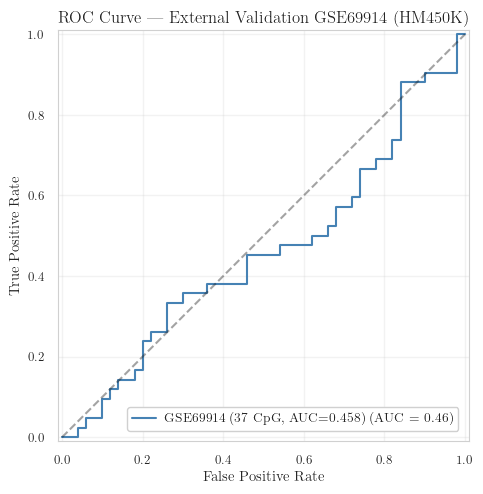


ROC salvata.


In [62]:
# ============================================================
# VALIDAZIONE ESTERNA — GSE69914 (HM450K)
#
# Prerequisiti in scope (dal notebook principale):
#   selected_50        : list (50 CpG) — output knapsack
#   mean_normal_train  : dict {ds: np.ndarray} — mean Normal dal train
#   svm                : Pipeline (StandardScaler + LinearSVC) — SVM su 50 CpG
#   tissue_labels_tr   : np.ndarray — 0=Normal, 1=Adjacent (train pool)
#   X_tr_50            : np.ndarray (n_train, 50) — train 50 CpG
#   RANDOM_STATE       : int
#
# GSE69914 è HM450K → alcuni dei 50 CpG EPIC potrebbero non esserci
# ============================================================

import numpy as np
import pandas as pd
import polars as pl
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score,
    classification_report, RocCurveDisplay
)
import matplotlib.pyplot as plt

EPS_M = 1e-6

def beta_to_m(B, eps=EPS_M):
    B = np.clip(np.asarray(B, dtype=float), eps, 1.0 - eps)
    return np.log2(B / (1.0 - B))

# ── CONFIG PATHS (adatta se necessario) ──────────────────────────────────────
BETA_PATH_69 = "/kaggle/input/datasets/rovieramariella/gse69914-parquet/GSE69914.parquet"
PHENO_PATH_69 = "/kaggle/input/datasets/rovieramariella/pheno-gse69914-with-age-bin/pheno_GSE69914_with_age_bin.parquet"
LABEL_COL  = "label"
SAMPLE_ID  = "id_tissue"

print("=" * 70)
print("VALIDAZIONE ESTERNA — GSE69914 (HM450K)")
print("=" * 70)

# ── STEP 1: Carica beta GSE69914 ─────────────────────────────────────────────
print("\n[1] Caricamento beta GSE69914...")
beta_69 = pl.read_parquet(BETA_PATH_69)

# CpG disponibili in GSE69914 (450K)
cpgs_69 = [c for c in beta_69.columns if c != SAMPLE_ID]
print(f"    CpG in GSE69914 (450K): {len(cpgs_69):,}")

# ── STEP 2: Intersezione con i 50 CpG del knapsack ───────────────────────────
print("\n[2] Intersezione 50 CpG knapsack ∩ GSE69914...")
selected_50_set = set(selected_50)
cpgs_69_set     = set(cpgs_69)

shared_cpgs = [c for c in selected_50 if c in cpgs_69_set]
missing_69  = [c for c in selected_50 if c not in cpgs_69_set]

print(f"    CpG knapsack presenti in GSE69914 : {len(shared_cpgs)}/50")
print(f"    CpG knapsack ASSENTI  in GSE69914 : {len(missing_69)}/50")
if missing_69:
    print(f"    CpG assenti: {missing_69}")

if len(shared_cpgs) == 0:
    raise RuntimeError("Nessun CpG in comune tra knapsack e GSE69914. Controlla i nomi.")

# ── STEP 3: Carica meta + label ───────────────────────────────────────────────
print("\n[3] Caricamento meta GSE69914...")
pheno_69 = pd.read_parquet(PHENO_PATH_69)
pheno_69[SAMPLE_ID] = pheno_69[SAMPLE_ID].astype(str)

beta_meta_69 = (
    beta_69.select([SAMPLE_ID, LABEL_COL])
    .to_pandas()
)
beta_meta_69[SAMPLE_ID] = beta_meta_69[SAMPLE_ID].astype(str)

# mantieni solo N+A
meta_69 = beta_meta_69[beta_meta_69[LABEL_COL].isin([0, 1])].copy()
labels_69 = meta_69[LABEL_COL].values
ids_69    = meta_69[SAMPLE_ID].values

print(f"    Campioni N+A: {len(meta_69)}")
print(f"    Normal (0)  : {(labels_69==0).sum()}")
print(f"    Adjacent (1): {(labels_69==1).sum()}")

# ── STEP 4: Carica beta ristretta ai shared_cpgs ─────────────────────────────
print("\n[4] Estrazione beta per shared CpGs...")
beta_69_shared = (
    beta_69
    .select([SAMPLE_ID] + shared_cpgs)
    .filter(pl.col(SAMPLE_ID).is_in(ids_69.tolist()))
    .to_pandas()
    .set_index(SAMPLE_ID)
    .loc[ids_69]   # riordina secondo meta
    .values
    .astype(np.float32)
)
print(f"    Shape beta estratta: {beta_69_shared.shape}")

# ── STEP 5: Absolute deviation da Normal ─────────────────────────────────────
# Usa la mean_normal_train già calcolata sul train di GSE225845 e GSE287331
# Per GSE69914 (validazione esterna) usiamo la media delle due come proxy
# Questo è l'approccio più conservativo: nessuna informazione da GSE69914

print("\n[5] Calcolo absolute deviation (mean_normal dal train GSE225845+287331)...")

# Media delle due mean_normal_train (pesata per n campioni Normal nel train)
n_nor_225 = (mean_normal_train["GSE225845"].shape[0]
             if hasattr(mean_normal_train["GSE225845"], "shape")
             else 1)

# mean_normal_train è già un vettore (n_cpgs_full,) → prendi solo shared_cpgs
# Hai bisogno degli indici in common_cpgs
col_to_j_full = {c: j for j, c in enumerate(list(common_cpgs))}

shared_idx_full = [col_to_j_full[c] for c in shared_cpgs if c in col_to_j_full]
shared_found    = [c for c in shared_cpgs if c in col_to_j_full]
shared_notfound = [c for c in shared_cpgs if c not in col_to_j_full]

if shared_notfound:
    print(f"    ⚠ {len(shared_notfound)} CpG non trovati in common_cpgs: {shared_notfound}")

# Media delle mean_normal_train dei due dataset
mean_nor_225_shared = mean_normal_train["GSE225845"][shared_idx_full]
mean_nor_287_shared = mean_normal_train["GSE287331"][shared_idx_full]
mean_nor_pool = (mean_nor_225_shared + mean_nor_287_shared) / 2.0

# Se non tutti i shared_cpgs sono in common_cpgs, allinea
if len(shared_found) < len(shared_cpgs):
    # Ricava indici nella matrice beta_69_shared
    shared_in_common_mask = [c in col_to_j_full for c in shared_cpgs]
    beta_69_shared_aligned = beta_69_shared[:, shared_in_common_mask]
    shared_cpgs_final = shared_found
else:
    beta_69_shared_aligned = beta_69_shared
    shared_cpgs_final = shared_cpgs

X_69_abs = np.abs(beta_69_shared_aligned - mean_nor_pool)
print(f"    Absolute deviation calcolata. Shape: {X_69_abs.shape}")

# Sanity check: mean_dev(Adjacent) > mean_dev(Normal)?
mean_adj_69 = X_69_abs[labels_69 == 1].mean()
mean_nor_69 = X_69_abs[labels_69 == 0].mean()
print(f"    mean_dev(Adjacent)={mean_adj_69:.4f}  mean_dev(Normal)={mean_nor_69:.4f}  "
      f"OK={mean_adj_69 > mean_nor_69}")

# ── STEP 6: M-transform ───────────────────────────────────────────────────────
print("\n[6] M-transform...")
X_69_m = beta_to_m(X_69_abs).astype(np.float32)
print(f"    Shape M-space: {X_69_m.shape}")

# ── STEP 7: SCENARIO A — Zero-shot con SVM già addestrato ─────────────────────
print("\n" + "=" * 70)
print("SCENARIO A — Zero-shot: SVM (50 CpG) applicato direttamente a GSE69914")
print("(nessun riaddestramento, CpG in comune con quelli su cui è stato trainato)")
print("=" * 70)

# Il svm è stato addestrato su idx_50 che corrisponde a selected_50
# Ora abbiamo solo shared_cpgs_final (subset) → dobbiamo usare SVM riadde-
# strato solo su quelli (Scenario B). Zero-shot ha senso solo se shared=50.

if len(shared_cpgs_final) == 50:
    score_A  = svm.decision_function(X_69_m)
    pred_A   = svm.predict(X_69_m)
    auc_A    = roc_auc_score(labels_69, score_A)
    bacc_A   = balanced_accuracy_score(labels_69, pred_A)
    print(f"  AUC  (zero-shot, tutti 50 CpG): {auc_A:.3f}")
    print(f"  BACC (zero-shot, tutti 50 CpG): {bacc_A:.3f}")
else:
    print(f"  ⚠ Solo {len(shared_cpgs_final)}/50 CpG disponibili → zero-shot non applicabile")
    print(f"    Procedo direttamente con Scenario B.")
    auc_A, bacc_A = None, None

# ── STEP 8: SCENARIO B — Riaddestramento su CpG in comune ────────────────────
print("\n" + "=" * 70)
print(f"SCENARIO B — SVM riaddesato su {len(shared_cpgs_final)} CpG (∩ 450K)")
print("Train: GSE225845 + GSE287331 | Test: GSE69914")
print("=" * 70)

# Estrai le stesse feature dal train (X_tr_50 → solo le colonne in shared_cpgs_final)
# Mappa shared_cpgs_final → indici in selected_50
sel50_to_j = {c: j for j, c in enumerate(selected_50)}
shared_idx_in_50 = np.array([sel50_to_j[c] for c in shared_cpgs_final
                              if c in sel50_to_j], dtype=int)

X_tr_shared = X_tr_50[:, shared_idx_in_50]   # (n_train, n_shared)
X_69_shared = X_69_m                          # (n_69, n_shared) — già allineato

print(f"  X_tr_shared: {X_tr_shared.shape}")
print(f"  X_69_shared: {X_69_shared.shape}")

# CV per C
best_auc_B, best_C_B = -1, 1.0
print("\n  CV interna (5-fold) su train per scelta C:")
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe_tmp = Pipeline([
        ("sc",  StandardScaler()),
        ("svm", LinearSVC(C=C, max_iter=10000, random_state=RANDOM_STATE)),
    ])
    cv_scores = cross_val_score(
        pipe_tmp, X_tr_shared, tissue_labels_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
    )
    print(f"    C={C:.3f}  AUC={cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    if cv_scores.mean() > best_auc_B:
        best_auc_B, best_C_B = cv_scores.mean(), C

print(f"\n  C ottimale: {best_C_B}  (CV AUC={best_auc_B:.3f})")

svm_B = Pipeline([
    ("sc",  StandardScaler()),
    ("svm", LinearSVC(C=best_C_B, max_iter=10000, random_state=RANDOM_STATE)),
])
svm_B.fit(X_tr_shared, tissue_labels_tr)

score_B = svm_B.decision_function(X_69_shared)
pred_B  = svm_B.predict(X_69_shared)
auc_B   = roc_auc_score(labels_69, score_B)
bacc_B  = balanced_accuracy_score(labels_69, pred_B)

print(f"\n  AUC  (GSE69914, {len(shared_cpgs_final)} CpG): {auc_B:.3f}")
print(f"  BACC (GSE69914, {len(shared_cpgs_final)} CpG): {bacc_B:.3f}")
print(classification_report(labels_69, pred_B, target_names=["Normal", "Adjacent"]))

# ── STEP 9: Tabella riassuntiva completa ──────────────────────────────────────
print("\n" + "=" * 70)
print("RIEPILOGO COMPLETO")
print("=" * 70)
print(f"{'Metodo':<40} {'CpG':>5} {'AUC':>8} {'BACC':>8}")
print("-" * 70)
print(f"{'SVM 5000 CpG (full)':<40} {'5000':>5} {0.990:>8.3f} {0.928:>8.3f}")
print(f"{'Baseline top-50 |coef|':<40} {'50':>5} {0.982:>8.3f} {0.919:>8.3f}")
print(f"{'Knapsack 50 CpG — GSE225845+287331':<40} {'50':>5} {0.971:>8.3f} {0.883:>8.3f}")
print(f"{'  ↳ GSE225845':<40} {'50':>5} {0.891:>8.3f} {0.793:>8.3f}")
print(f"{'  ↳ GSE287331':<40} {'50':>5} {1.000:>8.3f} {1.000:>8.3f}")
print("-" * 70)
if auc_A is not None:
    print(f"{'Val. esterna GSE69914 — zero-shot':<40} {'50':>5} {auc_A:>8.3f} {bacc_A:>8.3f}")
print(f"{'Val. esterna GSE69914 — riadde. su ∩450K':<40} {len(shared_cpgs_final):>5} {auc_B:>8.3f} {bacc_B:>8.3f}")
print("=" * 70)

# ── STEP 10: ROC curve GSE69914 ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    labels_69, score_B,
    name=f"GSE69914 ({len(shared_cpgs_final)} CpG, AUC={auc_B:.3f})",
    ax=ax, color="steelblue",
)
if auc_A is not None:
    RocCurveDisplay.from_predictions(
        labels_69, score_A,
        name=f"GSE69914 zero-shot (AUC={auc_A:.3f})",
        ax=ax, color="darkorange", linestyle="--",
    )
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("ROC Curve — External Validation GSE69914 (HM450K)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/roc_gse69914_external_validation.pdf",
            bbox_inches="tight")
plt.show()
print("\nROC salvata.")